In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import re
import scipy as sp
import seaborn as sns

import sys
sys.path.append('..')
import lang_complexity.data.util as du
import lang_complexity.text.tokenizer as tk

In [2]:
d90_file = 'complexity_utf-16_2025_10_bibles_90_lcm.csv'
dall_file = 'complexity_utf-16_2025_10_bibles_lcm.csv'
family_file = '../dataset/family.csv'

bible_file_d90 = '../dataset/' + re.match('.*(bibles_.*)', d90_file).group(1)
bibles_d90 = pd.read_csv(bible_file_d90, index_col=False)
bibles_d90 = bibles_d90[bibles_d90.language != 'NAMBIKUÁRA']
    
df90 = pd.read_csv(d90_file, index_col=False)
df90 = df90[df90.language != 'NAMBIKUÁRA'] # We removed Nambikuára because it has tone annotation
df90['algorithm'] = df90['experiment'].str.split('_').str[-1]
df90['metric'] = df90['experiment'].str.split('_').str[0:2].str.join('_')
df90['metric'] = df90['metric'].str.replace('_', ' ')
df90 = df90.drop(columns=['experiment'])
df90.loc[df90.metric == 'morphological deletion', 'value'] = - df90.loc[df90.metric == 'morphological deletion', 'value']
df90.loc[df90.metric == 'morphological substitution', 'value'] = 1/df90.loc[df90.metric == 'morphological substituion', 'value']
df90.loc[df90['metric'].str.startswith('size'), 'metric'] = 'size'
df90['metric'] = df90['metric'].str.replace('"', '').str.replace("'", "").str.strip()


bible_file_dall = '../dataset/' + re.match('.*(bibles_.*)', dall_file).group(1)
bibles_dall = pd.read_csv(bible_file_dall, index_col=False)
bibles_dall = bibles_dall[bibles_dall.language != 'NAMBIKUÁRA']

dfall = pd.read_csv(dall_file, index_col=False)
dfall = dfall[dfall.language != 'NAMBIKUÁRA'] # We removed Nambikuára because it has tone annotation
dfall['algorithm'] = dfall['experiment'].str.split('_').str[-1]
dfall['metric'] = dfall['experiment'].str.split('_').str[0:2].str.join('_')
dfall['metric'] = dfall['metric'].str.replace('_', ' ')
dfall = dfall.drop(columns=['experiment'])
dfall.loc[dfall.metric == 'morphological deletion', 'value'] = - dfall.loc[dfall.metric == 'morphological deletion', 'value']
dfall.loc[dfall.metric == 'morphological substitution', 'value'] = 1/dfall.loc[dfall.metric == 'morphological substituion', 'value']
dfall.loc[dfall['metric'].str.startswith('size'), 'metric'] = 'size'
dfall['metric'] = dfall['metric'].str.replace('"', '').str.replace("'", "").str.strip()
family = pd.read_csv(family_file, index_col=None)

dfall = dfall.drop(columns=['language']).merge(
    family.drop(
        columns=['countries', 'branch']
    ), on='wals', how='inner').rename(columns={ 'wals' : 'code'})
df90 = df90.drop(columns=['language']).merge(
    family.drop(
        columns=['countries', 'branch'])
    , on='wals', how='inner').rename(columns={ 'wals' : 'code'})

rall = dfall.groupby(
    by=['language', 'family', 'code', 'metric', 'algorithm'],
    as_index=False).agg({'value' : ['mean', 'var']})
r90 = df90.groupby(
    by=['language', 'family', 'code', 'metric', 'algorithm'],
    as_index=False).agg({'value' : ['mean', 'var']})

rall.columns = ['_'.join(col).rstrip('_') for col in rall.columns]
r90.columns = ['_'.join(col).rstrip('_') for col in r90.columns]


In [3]:
algorithms =  [alg for alg in dfall['algorithm'].unique() if alg != 'none']
metrics = [met for met in dfall['metric'].unique() if met != 'size']

In [5]:
r90

,language,family,code,metric,algorithm,value_mean,value_var
0,Ancient Greek,Indo-European,[grc],morphology deletion,bsc,-1.258891,4.256322e-07
1,Ancient Greek,Indo-European,[grc],morphology deletion,bzip2,-1.256017,7.998017e-07
2,Ancient Greek,Indo-European,[grc],morphology deletion,gzip,-1.092514,3.079595e-07
3,Ancient Greek,Indo-European,[grc],morphology deletion,none,-0.907850,3.243192e-09
4,Ancient Greek,Indo-European,[grc],morphology deletion,zpaq,-1.244732,3.396910e-07
...,...,...,...,...,...,...,...
670,Yanomami,Yanomami,[guu],syntactic deletion,bsc,1.053541,5.664870e-07
671,Yanomami,Yanomami,[guu],syntactic deletion,bzip2,1.043566,2.537832e-07
672,Yanomami,Yanomami,[guu],syntactic deletion,gzip,0.982103,5.447552e-07
673,Yanomami,Yanomami,[guu],syntactic deletion,none,0.916306,3.079452e-08


In [6]:
rall

,language,family,code,metric,algorithm,value_mean,value_var
0,Ancient Greek,Indo-European,[grc],morphology deletion,bsc,-1.199493,4.677727e-07
1,Ancient Greek,Indo-European,[grc],morphology deletion,bzip2,-1.207244,1.548845e-06
2,Ancient Greek,Indo-European,[grc],morphology deletion,gzip,-1.082325,1.350932e-06
3,Ancient Greek,Indo-European,[grc],morphology deletion,none,-0.907856,1.840458e-08
4,Ancient Greek,Indo-European,[grc],morphology deletion,zpaq,-1.192438,8.583789e-07
...,...,...,...,...,...,...,...
1395,Yanomami,Yanomami,[guu],syntactic deletion,bsc,1.025635,6.043858e-07
1396,Yanomami,Yanomami,[guu],syntactic deletion,bzip2,1.026492,3.034119e-06
1397,Yanomami,Yanomami,[guu],syntactic deletion,gzip,0.981199,7.811935e-07
1398,Yanomami,Yanomami,[guu],syntactic deletion,none,0.916424,1.243076e-07


# Helper functions

In [15]:
def compute_numtypes_numtokens(df):
    langs = du.by_field(df, 'language')
    united = {
        lang : du.df_to_str(val)
        for lang, val in langs.items()
    }

    d = dict(language=[], tokens=[], types=[])
    for lang, text in united.items():
        d['language'].append(lang)
        tokens = tk.tokens(text)
        d['tokens'].append(len(tokens))
        d['types'].append(len(tk.types(tokens)))
    return d


def compute_num_chars(df):
    from collections import Counter
    d = dict(language=[], chars=[])
    for lang in set(df.language):
        c = Counter('\n'.join(df[df.language == lang].text))
        d['language'].append(lang)
        d['chars'].append(len(c))
    dd = pd.DataFrame(d)
    return dd


def num_chars_across_bible(df, bibles):
    nc = compute_num_chars(bibles).sort_values('language').reset_index().drop(columns='index').chars.to_numpy()
    out = h1(df)
    for algo, (dfs, _, __) in out.items():
        if algo == 'none': continue
        y = dfs.drop_duplicates('language').sort_values('language').reset_index().drop(columns='index').oc.to_numpy()
        r = sp.stats.pearsonr(nc, y)
        print("%6s statistic: %.5f pvalue: %.5f" % (algo, r.statistic, r.pvalue))

# H1

In [8]:
def h1(df):
    out = {}
    for algorithm in algorithms:
        ag = df.algorithm == algorithm
        nn = df.algorithm == 'none'
        sz = df.metric == 'size'
        rw = df[sz & nn]
        co = df[sz & ag]

        x = rw.sort_values('language').value.to_numpy()
        y = co.sort_values('language').value.to_numpy()
        lr = sp.stats.linregress(x, y)
        ỹ = lr.slope*x + lr.intercept
        oc = y - ỹ
        out[algorithm] = (
            pd.DataFrame(dict(language=list(rw.sort_values('language').language),
                              oc=oc, rw=x, co=y)),
            x,
            ỹ                 
        )
    return out

def plth1(df, title=None):
    out = h1(df)
    fig, ax = plt.subplots(1, len(out), figsize=(5*len(out), 5))

    for i, (algo, (dfr, x, ỹ)) in enumerate(out.items()):
        ax[i].plot(x, ỹ)
        ax[i].scatter(x='rw', y='co', data=dfr)
        ax[i].set_title(fr'$\it{{{algo}}}$')
        ax[i].set_xlabel('size in bytes')
        ax[i].set_ylabel('size in bytes compressed')

    if title:
        fig.suptitle(title)
    fig.tight_layout()

## D90 Subset

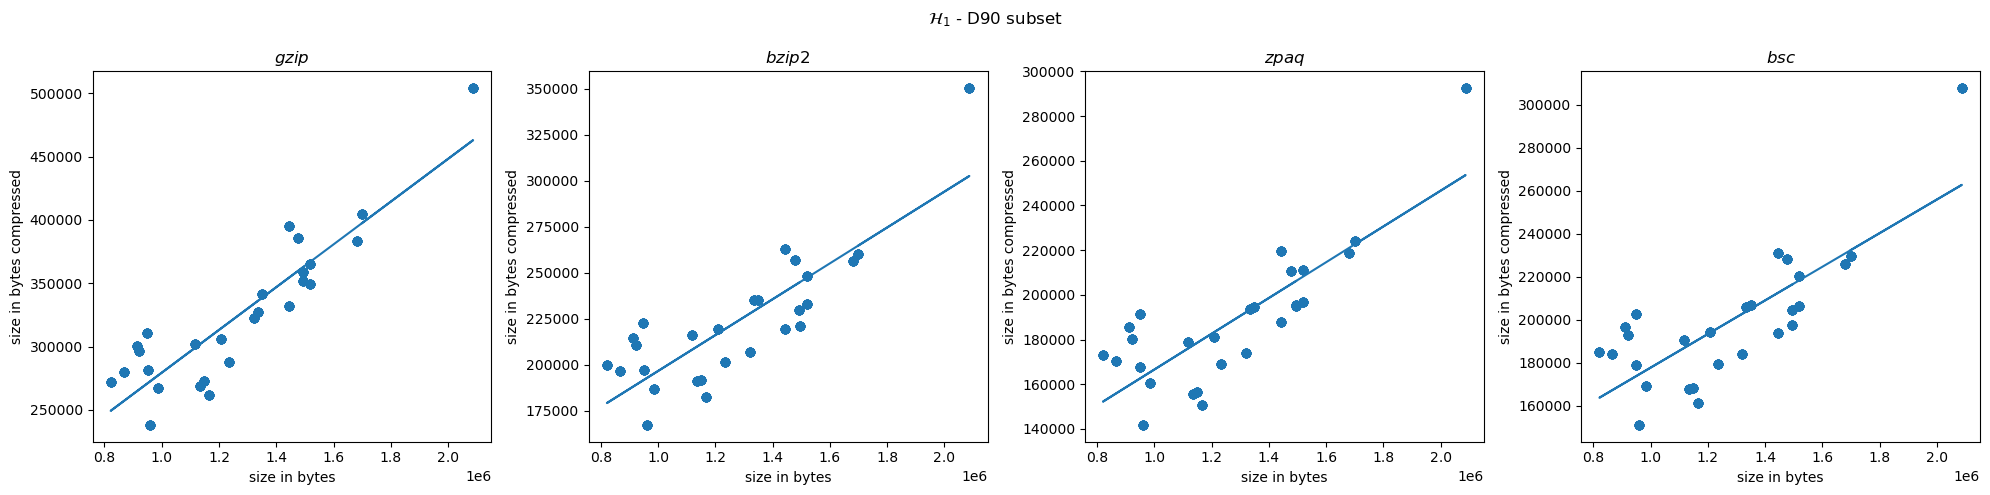

In [9]:
out90 = h1(df90)
plth1(df90, title=r"$\mathcal{H}_1$ - D90 subset")

In [10]:
num_chars_across_bible(df90, bibles_d90)

  gzip statistic: 0.05200 pvalue: 0.79674
 bzip2 statistic: -0.20677 pvalue: 0.30077
  zpaq statistic: -0.09138 pvalue: 0.65032
   bsc statistic: -0.17706 pvalue: 0.37696


## DALL Subset

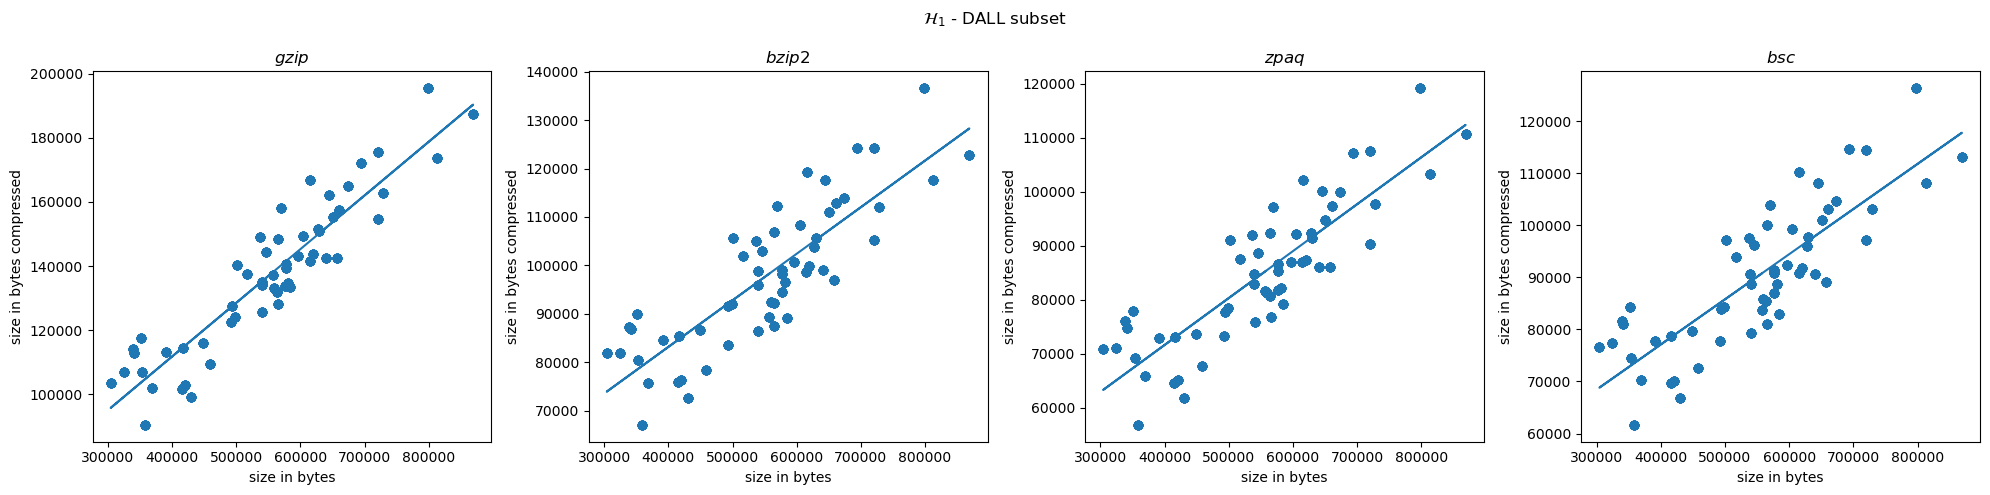

In [11]:
outall = h1(dfall)
plth1(dfall, title=r"$\mathcal{H}_1$ - DALL subset")

In [12]:
num_chars_across_bible(dfall, bibles_dall)

  gzip statistic: 0.05820 pvalue: 0.67008
 bzip2 statistic: -0.07886 pvalue: 0.56344
  zpaq statistic: 0.00050 pvalue: 0.99706
   bsc statistic: -0.05424 pvalue: 0.69133


In [13]:
l = 'Sateré-Mawé'
num_chars_across_bible(dfall[dfall.language != l], bibles_dall[bibles_dall.language != l.upper()])

  gzip statistic: 0.11851 pvalue: 0.38883
 bzip2 statistic: -0.02659 pvalue: 0.84717
  zpaq statistic: 0.05939 pvalue: 0.66665
   bsc statistic: 0.00145 pvalue: 0.99160


# H2 - Content Invariance

In [14]:
def h2(rdf):
    H2 = rdf.groupby(by=['metric', 'algorithm'],
                     as_index=False).agg({'value_mean' : ['mean', 'value_var']})

    for algorithm in ['gzip', 'bz2']:
        x = np.log10(
            H2[(H2.metric == 'size') \
            & (H2.algorithm == algorithm)][('value_mean', 'value_var')].item()
        )
        y = np.log10(
            H2[(H2.metric == 'size') \
            & (H2.algorithm == 'none')][('value_mean', 'value_var')].item()
        )
        print('%-4s variance has %d decimal places\n\tOriginal size variance has %d decimal places' \
              % (algorithm, int(np.ceil(x)), int(np.ceil(y))))



In [15]:
def ploth2(df, dataset, algo, save=False):
    data = df[algo][0]
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.set_title(r"Equi-complexity hypothesis ($\mathcal{H}_2$) with $\it{%s}$ in $\it{%s}$" % (algo.lower(), dataset), fontsize=24)

    #ax.hist(x='oc', bins=6, data=data, label="Overall Complexity", edgecolor="#FF00BF", color="#FFD6E0")
    ax.hist(x='oc', bins=6, data=data, label=r"Overall Complexity $(\mu^{\mathbb{A}})$", edgecolor="white", color="#FF00BF")
    #ax.hist(x='co', bins=10, data=data, label="Size of the compressed text (bytes)", edgecolor="#008FFF", color="#90F1EF")
    ax.hist(x='co', bins=10, data=data, label=r"Size of the compressed text $(|C(\mathscr{T})|)$ ", edgecolor="white", color="#008FFF")
    #ax.hist(x='rw', bins=13, data=data, label="Document size (bytes)", edgecolor="#009B8C", color="#C1FBA4")
    ax.hist(x='rw', bins=13, data=data, label=r"Document size (bytes) $(|\mathscr{T}|)$", edgecolor="white", color="#FFBA00")

    #ax.set_title(, fontsize=24, pad=30)
    ax.set_xlabel("Million of Bytes", fontsize=20, weight="bold", labelpad=-1)
    ax.set_ylabel("Count", fontsize=20, weight="bold")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)

    legend = fig.legend(loc='upper right', bbox_to_anchor=(.91, .91), prop={'weight' : 'bold', 'size' : '24'})
    legend.get_title().set_fontsize('x-large')
    if save:
        fig.savefig(f'./images/h2_{dataset}_{algo}.png')

## D90 Subset

/tmp/ipykernel_13149/1633702659.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/tmp/ipykernel_13149/1633702659.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
/tmp/ipykernel_13149/1633702659.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/tmp/ipykernel_13149/1633702659.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
/tmp/ipykernel_13149/1633702659.py:16: UserWarning: set_ticklabels() should only be used with a fixed number

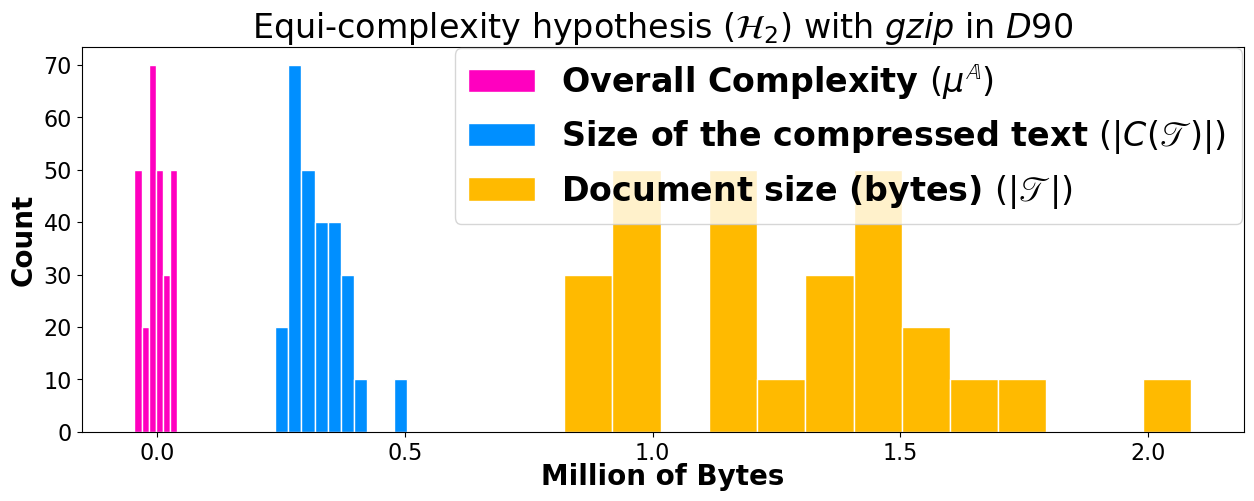

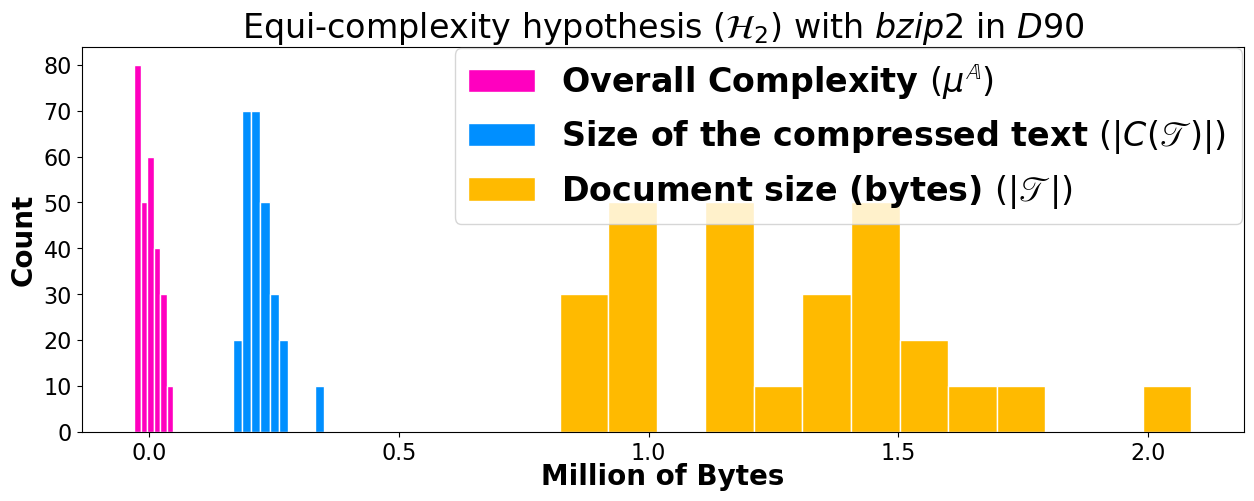

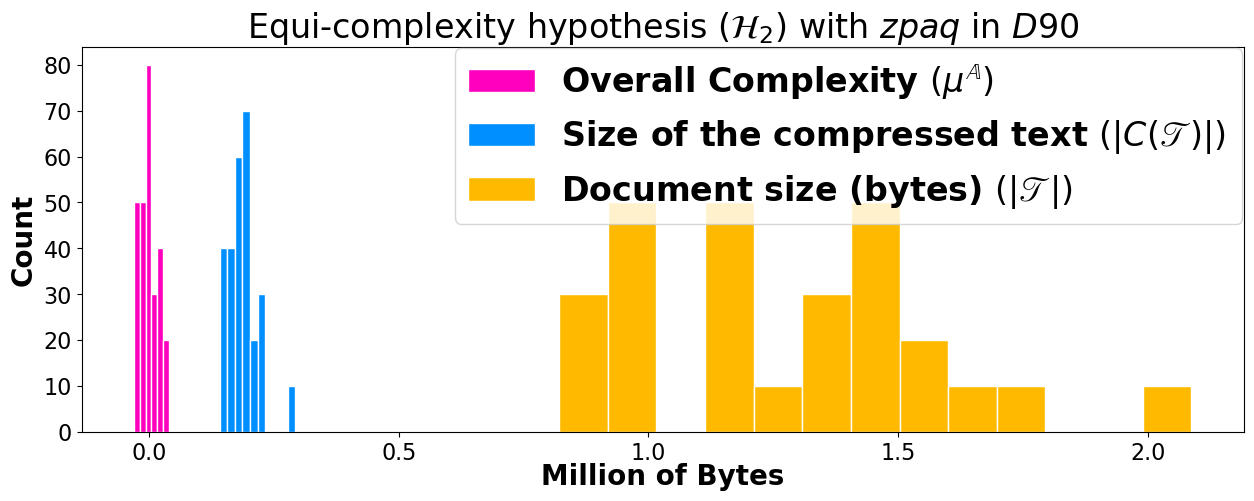

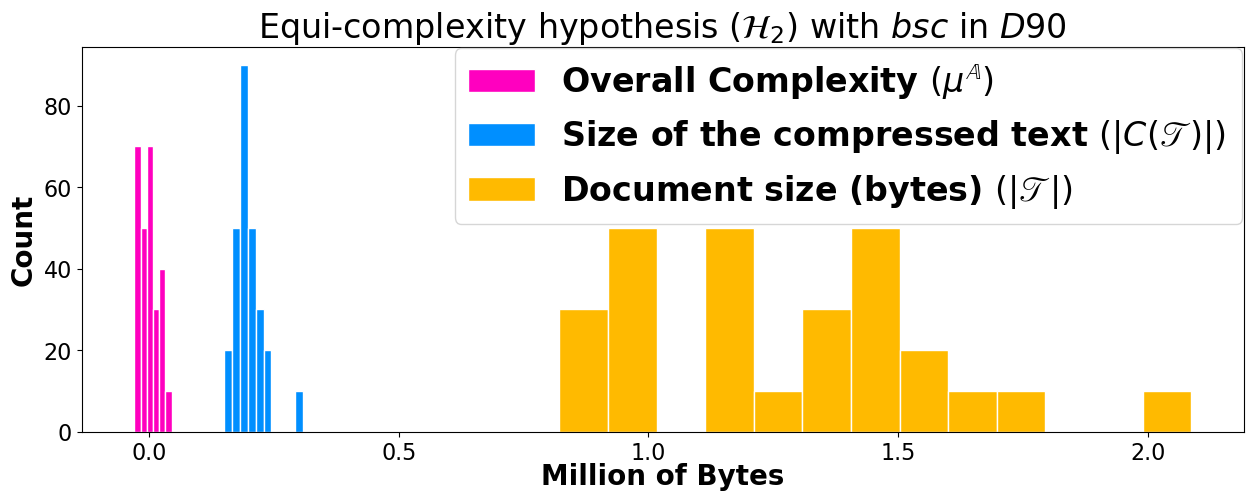

In [16]:
for alg in algorithms:
    ploth2(out90, 'D90', alg, True)

## DALL Subset

/tmp/ipykernel_13149/1633702659.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/tmp/ipykernel_13149/1633702659.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
/tmp/ipykernel_13149/1633702659.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
/tmp/ipykernel_13149/1633702659.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
/tmp/ipykernel_13149/1633702659.py:16: UserWarning: set_ticklabels() should only be used with a fixed number

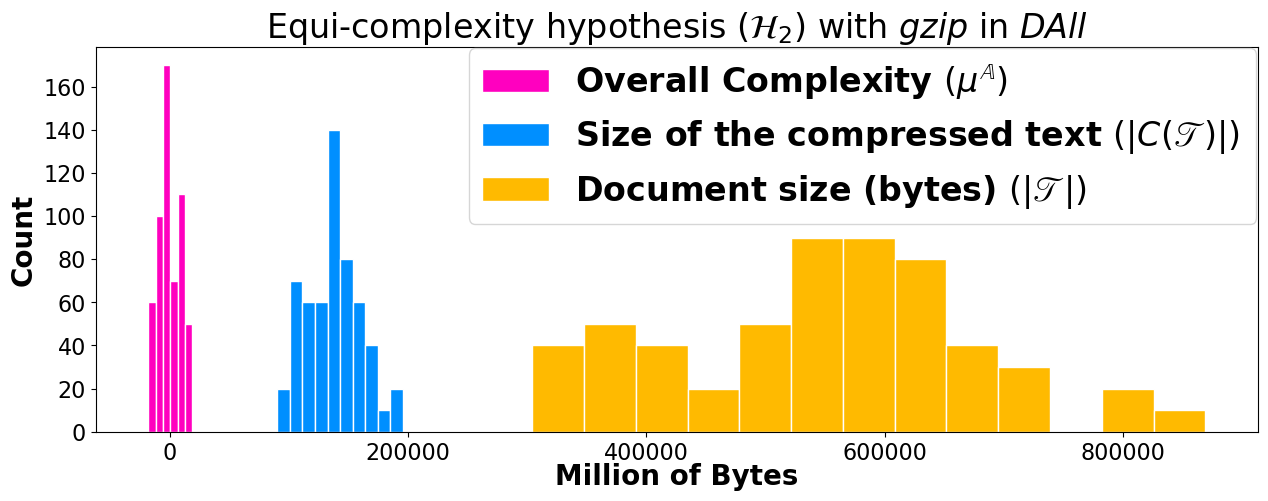

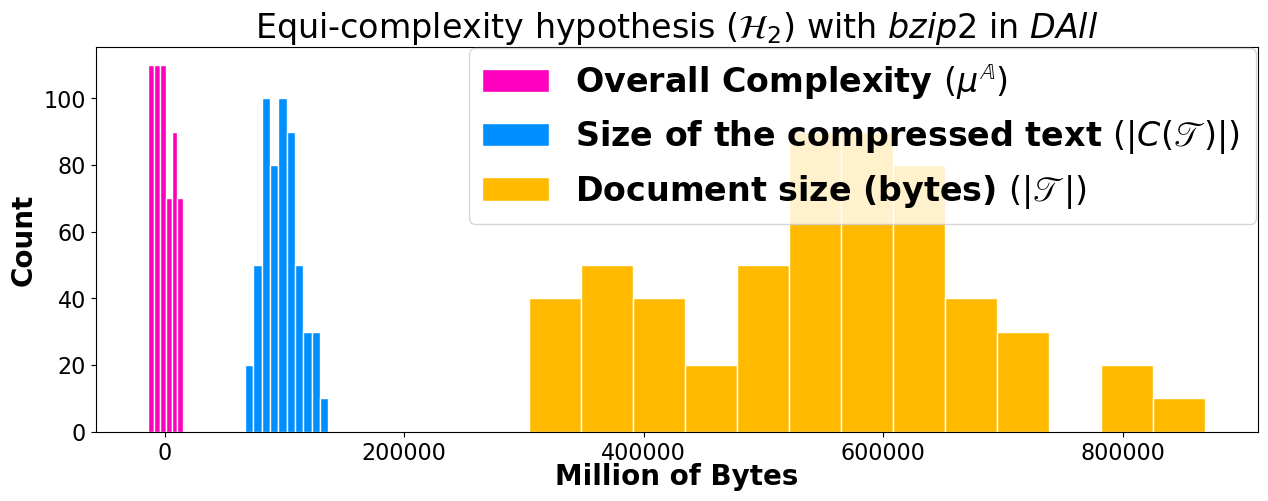

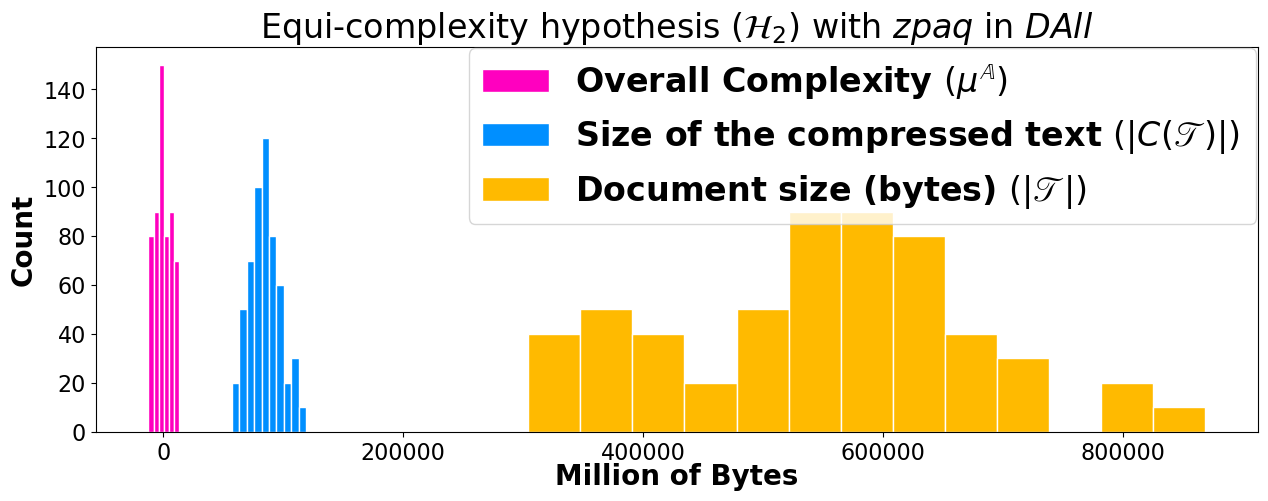

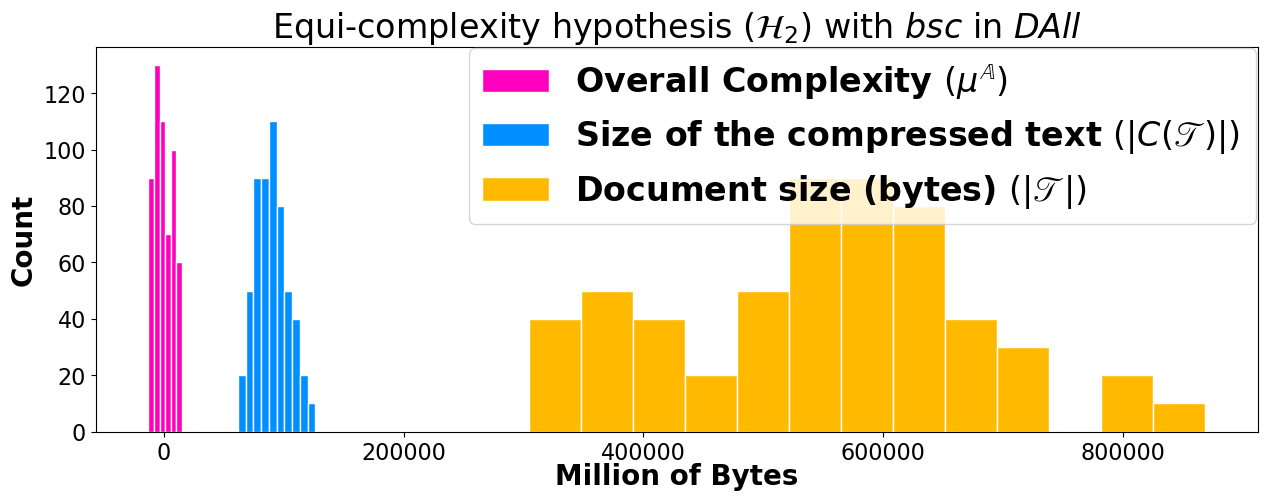

In [17]:
for alg in algorithms:
    ploth2(outall, 'DAll', alg, True)

# H3 - Morphology and Syntatic Trade-off

compare com os diferentes compressores, como foi feito na H1.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


def h3_overall(df, metric='deletion'):
    results = []

    y_metric = f"morphology {metric}"

    for algorithm in algorithms:
        a = df['algorithm'] == algorithm

        x = df[(df['metric'] == 'syntactic deletion') & a]['value_mean'].values.reshape(-1, 1)
        y = df[(df['metric'] == y_metric) & a]['value_mean'].values

        if len(x) < 2 or len(y) < 2:
            continue

        cr = sp.stats.pearsonr(x.flatten(), y)
        model = LinearRegression().fit(x, y)
        r2 = r2_score(y, model.predict(x))
        coef = model.coef_[0]
        intercept = model.intercept_

        results.append({
            'algorithm': algorithm,
            'pearson_r': cr.statistic,
            'pearson_p': cr.pvalue,
            'r2': r2,
            'coef': coef,
            'intercept': intercept,
        })

    df_result = pd.DataFrame(results)
    if not df_result.empty:
        df_result.set_index('algorithm', inplace=True)
    return df_result

In [6]:
def h3_family(df, metric='deletion'):
    results = []

    y_metric = f"morphology {metric}"

    for algorithm in algorithms:
        a = df['algorithm'] == algorithm
        df_algo = df[a]

        for family in df_algo['family'].unique():
            f = df_algo['family'] == family

            x = df_algo[(df_algo['metric'] == 'syntactic deletion') & f]['value_mean'].values.reshape(-1, 1)
            y = df_algo[(df_algo['metric'] == y_metric) & f]['value_mean'].values

            if len(x) < 3 or len(y) < 3:
                continue

            cr = sp.stats.pearsonr(x.flatten(), y)
            model = LinearRegression().fit(x, y)
            r2 = r2_score(y, model.predict(x))
            coef = model.coef_[0]
            intercept = model.intercept_

            results.append({
                'algorithm': algorithm,
                'family': family,
                'pearson_r': cr.statistic,
                'pearson_p': cr.pvalue,
                'r2': r2,
                'coef': coef,
                'intercept': intercept,
                'n_samples': len(x)
            })

    df_result = pd.DataFrame(results)
    if not df_result.empty:
        df_result.set_index(['algorithm', 'family'], inplace=True)
    return df_result


In [7]:
def compute(df_aggregated, alg):
    df_algo = df_aggregated[df_aggregated['algorithm'] == alg].copy()

    df_pivoted = df_algo.pivot_table(
        index=['language', 'family', 'code', 'algorithm'],
        columns='metric',
        values='value_mean'
    ).reset_index()

    df_pivoted.columns.name = None

    return df_pivoted

In [8]:
def h3_graph(df, save=False, name=None, metric='deletion', language_name=False, equal_axis=False, margin=0.02):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Syntactic Deletion vs Morphological {metric.capitalize()}: {name}', fontsize=24, weight='bold')

    if equal_axis:
        x_global = df[df['metric'] == 'syntactic deletion']['value_mean']
        y_global = df[df['metric'] == f'morphology {metric}']['value_mean']
        x_min, x_max = x_global.min(), x_global.max()
        y_min, y_max = y_global.min(), y_global.max()
        x_range = x_max - x_min
        y_range = y_max - y_min
        x_min -= x_range * margin
        x_max += x_range * margin
        y_min -= y_range * margin
        y_max += y_range * margin

    for i, (ax, algorithm) in enumerate(zip(axes.flatten(), algorithms)):
        df_pivoted = compute(df, algorithm)
        if df_pivoted.empty:
            continue

        show_legend = (i == 0)

        sns.scatterplot(
            data=df_pivoted, x='syntactic deletion', y=f'morphology {metric}',
            hue='family', ax=ax, s=70, edgecolor='black', alpha=0.8,
            legend=show_legend
        )

        sns.regplot(
            data=df_pivoted, x='syntactic deletion', y=f'morphology {metric}',
            ax=ax, scatter=False, color='red'
        )

        if language_name:
            for _, row in df_pivoted.iterrows():
                ax.text(row['syntactic deletion'] + 0.001, row[f'morphology {metric}'] + 0.001,
                        row['language'], fontsize=9, alpha=0.8)

        # R²
        X = df_pivoted[['syntactic deletion']]
        y = df_pivoted[f'morphology {metric}']
        if len(X) >= 2:
            model = LinearRegression().fit(X, y)
            r2 = r2_score(y, model.predict(X))
            ax.text(0.95, 0.95, f'$R^2 = {r2:.3f}$', transform=ax.transAxes,
                    fontsize=15, color='blue', ha='right', va='top', weight='bold')

        ax.set_title(r'Compressor: $\it{%s}$' % algorithm.lower(), fontsize=16)
        ax.set_xlabel('Syntactic Deletion', fontsize=12)
        ax.set_ylabel(f'Morphological {metric.capitalize()}', fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.grid(True)

        if equal_axis:
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels, title="Family",
        loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=10
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    if save:
        suffix = "_morph" if equal_axis else ""
        plt.savefig(f'h3_graph_{name}{suffix}.png', dpi=150, bbox_inches='tight')
    
    plt.show()


In [9]:
from scipy.stats import pearsonr
from matplotlib.lines import Line2D


def h3_graph_family(df, save=False, name=None, metric='deletion',
                    language_name=False, equal_axis=False, margin=0.02):

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Syntactic Deletion vs Morphological {metric.capitalize()}: {name}',
                 fontsize=24, weight='bold')

    families = sorted(df['family'].unique())
    palette = sns.color_palette('tab10', len(families))
    color_map = dict(zip(families, palette))

    if equal_axis:
        x_global = df[df['metric'] == 'syntactic deletion']['value_mean']
        y_global = df[df['metric'] == f'morphology {metric}']['value_mean']
        x_min, x_max = x_global.min(), x_global.max()
        y_min, y_max = y_global.min(), y_global.max()
        x_range, y_range = x_max - x_min, y_max - y_min
        x_min -= x_range * margin
        x_max += x_range * margin
        y_min -= y_range * margin
        y_max += y_range * margin

    for i, (ax, algorithm) in enumerate(zip(axes.flatten(), algorithms)):
        df_pivoted = compute(df, algorithm)
        if df_pivoted.empty:
            continue

        X_all = df_pivoted[['syntactic deletion']]
        y_all = df_pivoted[f'morphology {metric}']
        global_model = LinearRegression().fit(X_all, y_all)
        x_line = np.linspace(X_all.min().values[0], X_all.max().values[0], 100)
        y_pred = global_model.predict(x_line.reshape(-1, 1))
        ax.plot(x_line, y_pred, linestyle='--', linewidth=2.5, color='black', alpha=0.7)

        # Dispersão por família
        show_legend = (i == 0)
        sns.scatterplot(
            data=df_pivoted, x='syntactic deletion', y=f'morphology {metric}',
            hue='family', ax=ax, s=70, edgecolor='black', alpha=0.8,
            palette=color_map, legend=show_legend
        )

        # Correlação média por família
        pearson_values = []
        for fam, subset in df_pivoted.groupby('family'):
            if len(subset) > 1:
                r, _ = pearsonr(subset['syntactic deletion'], subset[f'morphology {metric}'])
                pearson_values.append(r)

                sns.regplot(
                    data=subset, x='syntactic deletion', y=f'morphology {metric}',
                    ax=ax, scatter=False, color=color_map[fam], ci=None, line_kws={'linewidth': 1.5}
                )

                if language_name:
                    for _, row in subset.iterrows():
                        ax.text(row['syntactic deletion'] + 0.001, row[f'morphology {metric}'] + 0.001,
                                row['language'], fontsize=9, alpha=0.8)

        # Correlação média dentro do gráfico
        mean_corr = np.nanmean(pearson_values) if pearson_values else np.nan
        ax.text(0.95, 0.95, f'Mean Corr. = {mean_corr:.3f}',
                transform=ax.transAxes, fontsize=14, color='blue',
                ha='right', va='top', weight='bold')

        ax.set_title(r'Compressor: $\it{%s}$' % algorithm.lower(), fontsize=16)
        ax.set_xlabel('Syntactic Deletion', fontsize=12)
        ax.set_ylabel(f'Morphological {metric.capitalize()}', fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.grid(True)

        if equal_axis:
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    handles, labels = axes[0, 0].get_legend_handles_labels()

    handles.append(Line2D([0], [0], color='black', linestyle='--', linewidth=2.5))
    labels.append("Global Regression")

    fig.legend(
        handles, labels, title="Family",
        loc='lower center', bbox_to_anchor=(0.5, -0.12),
        ncol=4, fontsize=10
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])


    if save:
        suffix = "_morph" if equal_axis else ""
        plt.savefig(f'images/h3_graph_family_{name}{suffix}.png', dpi=300, bbox_inches='tight')

    plt.show()


In [10]:
def h3_graph_by_family(df, family_name, save=False, name=None, metric='deletion', equal_axis=False, margin=0.02):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Syntactic Deletion vs Morphological {metric.capitalize()}: Family {family_name}', fontsize=24, weight='bold')

    df_family = df[df['family'] == family_name]
    languages = sorted(df_family['language'].unique())
    palette = sns.color_palette('tab10', len(languages))
    color_map = dict(zip(languages, palette))

    if equal_axis:
        x_global = df_family[df_family['metric'] == 'syntactic deletion']['value_mean']
        y_global = df_family[df_family['metric'] == f'morphology {metric}']['value_mean']
        x_min, x_max = x_global.min(), x_global.max()
        y_min, y_max = y_global.min(), y_global.max()
        x_range = x_max - x_min
        y_range = y_max - y_min
        x_min -= x_range * margin
        x_max += x_range * margin
        y_min -= y_range * margin
        y_max += y_range * margin

    all_handles, all_labels = [], []

    for ax, algorithm in zip(axes.flatten(), algorithms):
        df_pivoted = compute(df_family, algorithm)
        if df_pivoted.empty:
            continue

        scatter = sns.scatterplot(
            data=df_pivoted,
            x='syntactic deletion',
            y=f'morphology {metric}',
            hue='language',
            ax=ax,
            s=70,
            edgecolor='black',
            alpha=0.8,
            palette=color_map,
            legend=False
        )

        # Armazena handles/labels do scatter
        handles, labels = scatter.get_legend_handles_labels()
        all_handles += handles
        all_labels += labels

        X = df_pivoted[['syntactic deletion']]
        y = df_pivoted[f'morphology {metric}']
        if len(X) >= 2:
            model = LinearRegression().fit(X, y)
            r2 = r2_score(y, model.predict(X))
            ax.text(0.95, 0.95, f'R² = {r2:.3f}', transform=ax.transAxes,
                    fontsize=12, color='blue', ha='right', va='top', weight='bold')
            # Linha de regressão
            sns.regplot(
                data=df_pivoted,
                x='syntactic deletion',
                y=f'morphology {metric}',
                ax=ax,
                scatter=False,
                color='red'
            )

        ax.set_title(r'$\it{%s}$' % algorithm.lower(), fontsize=16)
        ax.set_xlabel('Syntactic Deletion', fontsize=12)
        ax.set_ylabel(f'Morphological {metric.capitalize()}', fontsize=12)
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.grid(True)

        if equal_axis:
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

    if all_handles:
        # Remove duplicatas
        unique = dict(zip(all_labels, all_handles))
        fig.legend(
            unique.values(), unique.keys(), title="Language",
            loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=10
        )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save:
        suffix = "_morph" if equal_axis else ""
        plt.savefig(f'h3_graph_by_family_{family_name}{suffix}.png', dpi=150, bbox_inches='tight')

    plt.show()


## D90 

### Todas as línguas

In [96]:
h3_overall(r90)

,pearson_r,pearson_p,r2,coef,intercept
algorithm,,,,,
gzip,-0.324463,0.098697,0.105276,-1.046946,-0.201142
bzip2,-0.278448,0.159608,0.077533,-0.808301,-0.617759
zpaq,-0.281126,0.155466,0.079032,-0.846110,-0.582787
bsc,-0.289907,0.142421,0.084046,-0.821108,-0.587677


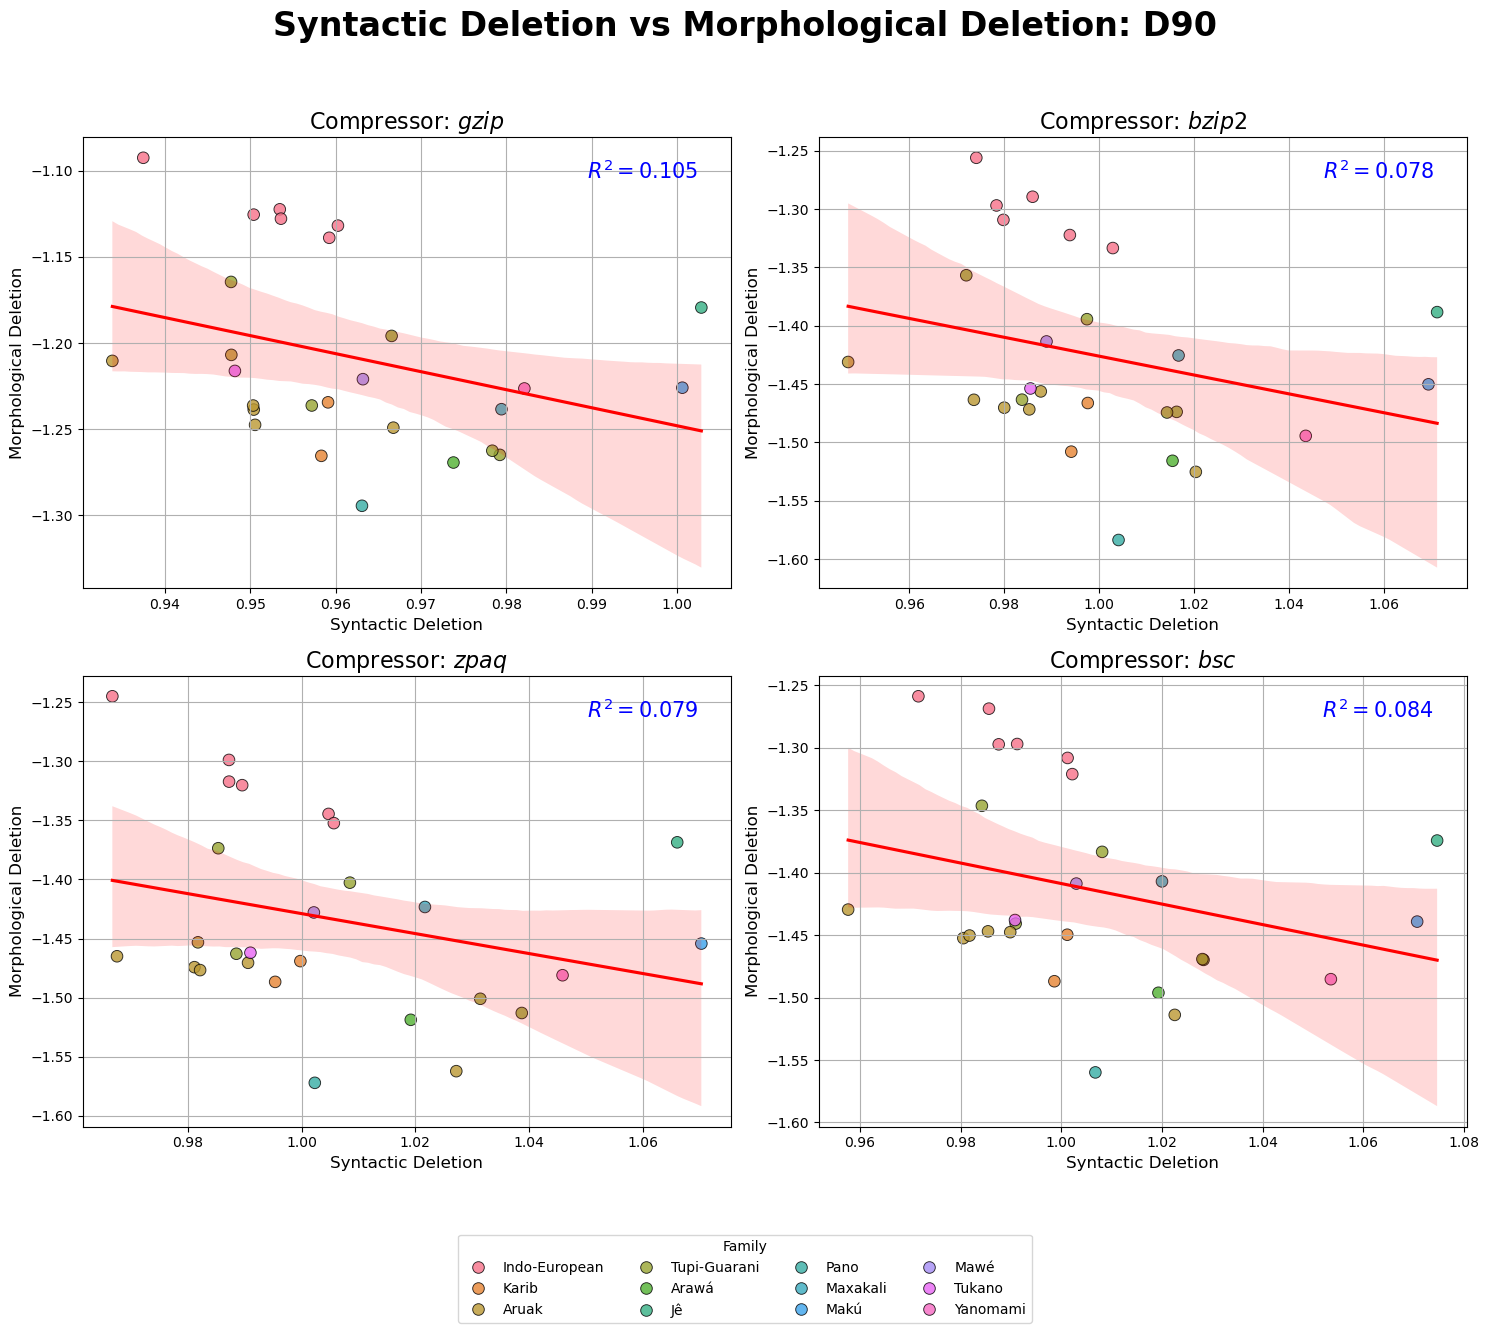

In [10]:
h3_graph(r90, name = "D90", save=True)

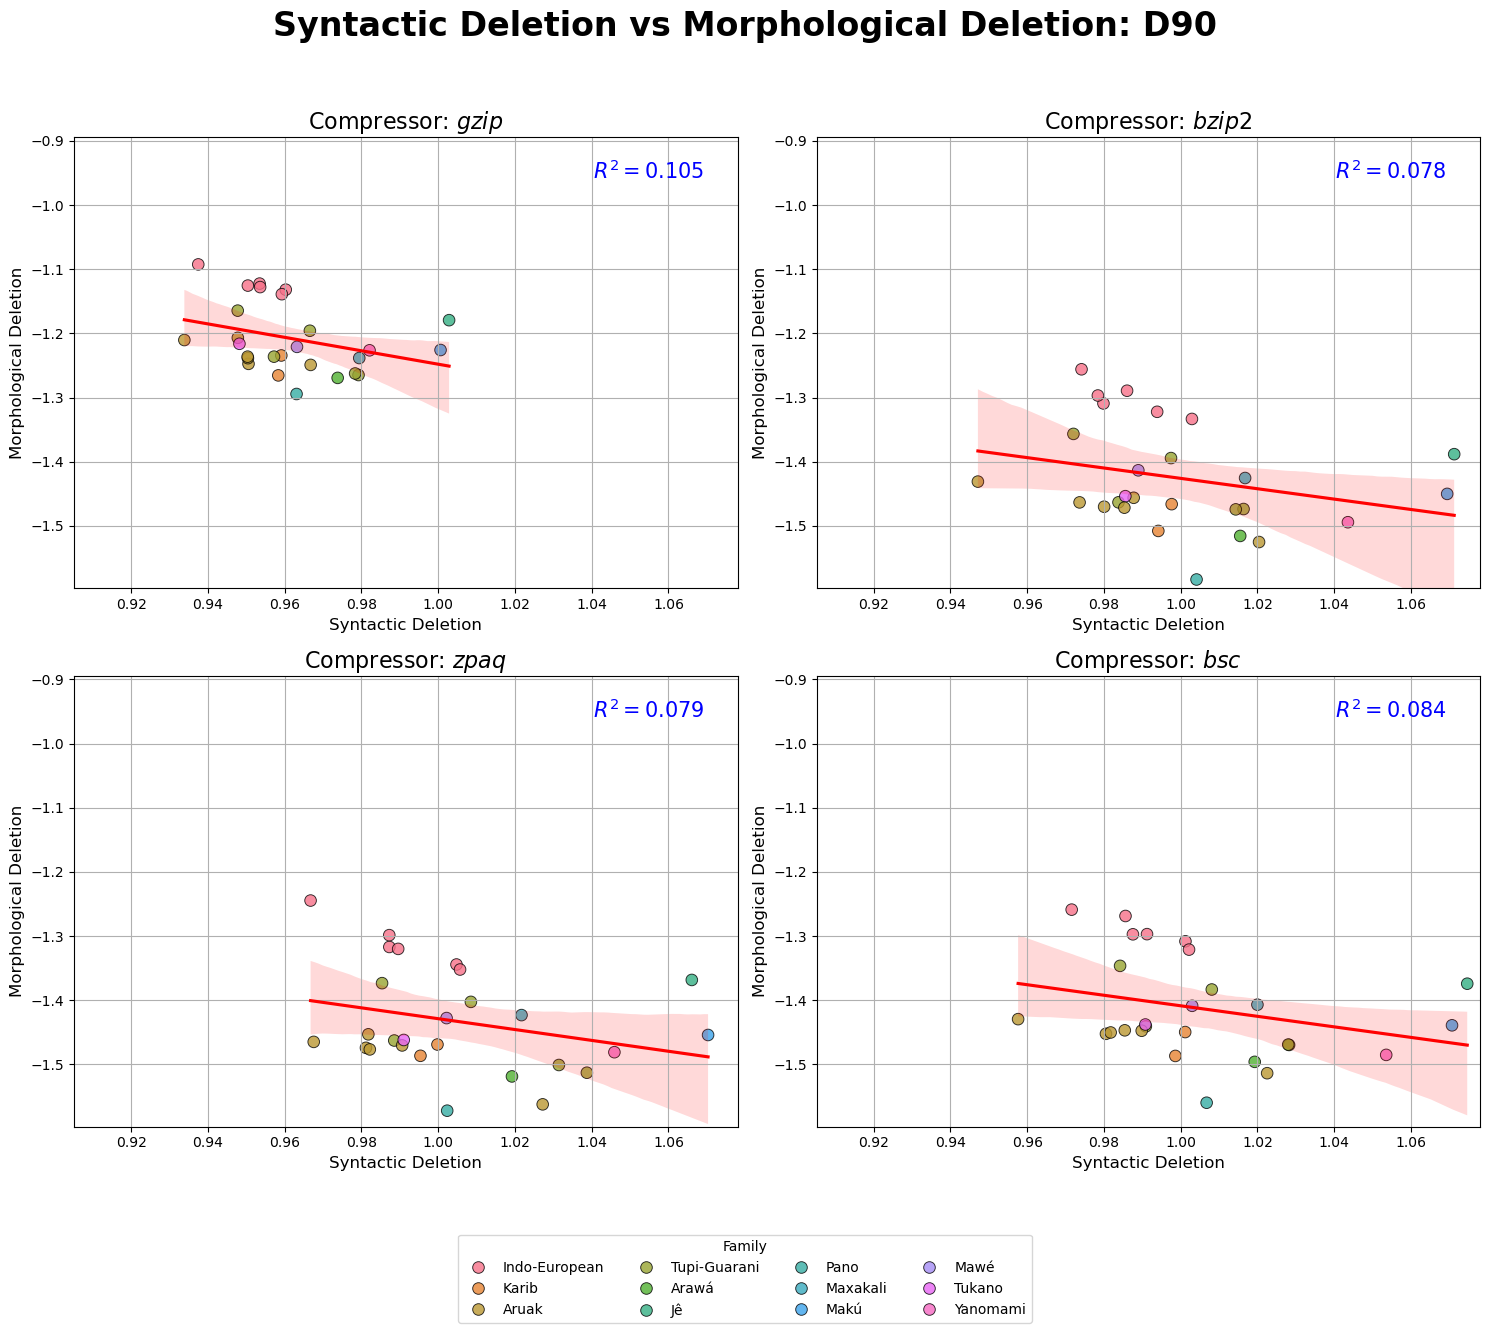

In [119]:
h3_graph(r90, name = "D90", equal_axis= True, save=True)

In [98]:
h3_overall(r90, metric='replacement')

,pearson_r,pearson_p,r2,coef,intercept
algorithm,,,,,
gzip,-0.788571,1.031208e-06,0.621845,-5.251683,6.046569
bzip2,-0.775495,2.021818e-06,0.601393,-1.804548,2.800248
zpaq,-0.883010,1.085793e-09,0.779706,-3.220215,4.102981
bsc,-0.700759,4.687702e-05,0.491063,-1.334811,2.312541


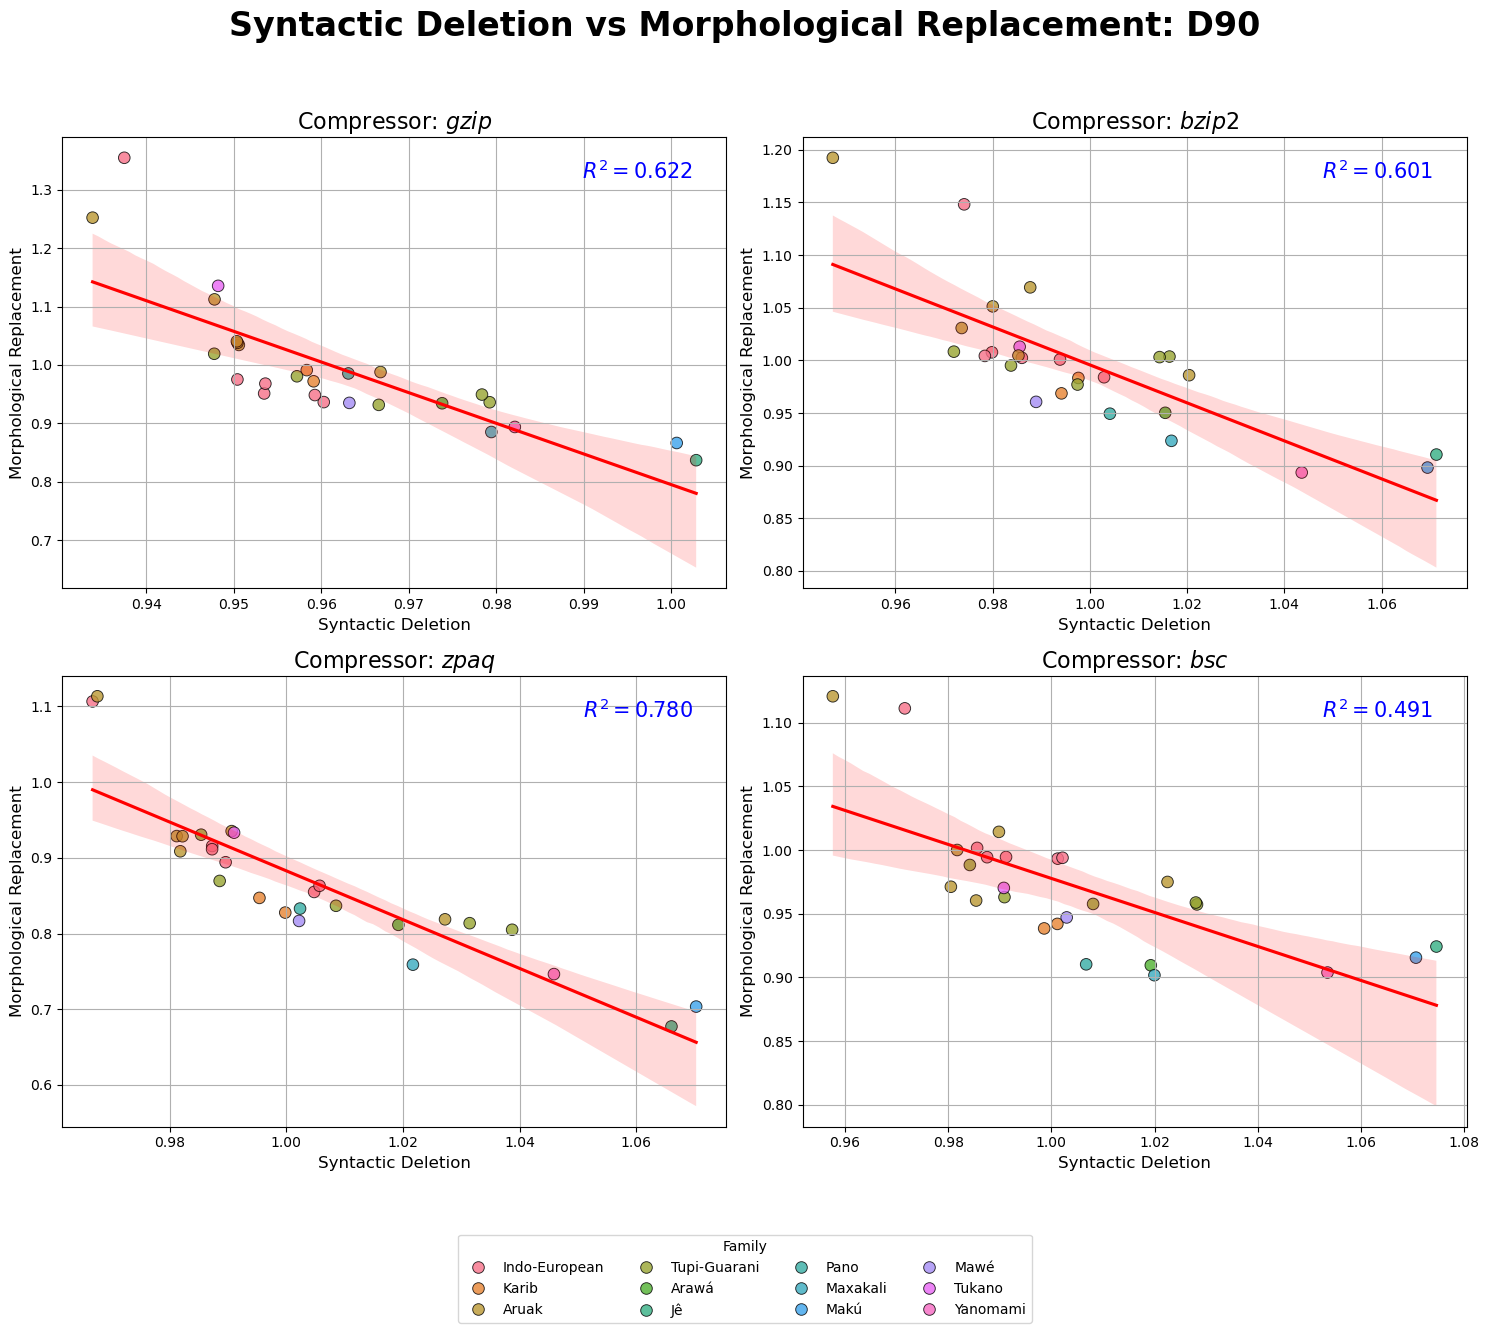

In [122]:
h3_graph(r90, name = "D90", save=True, metric='replacement')

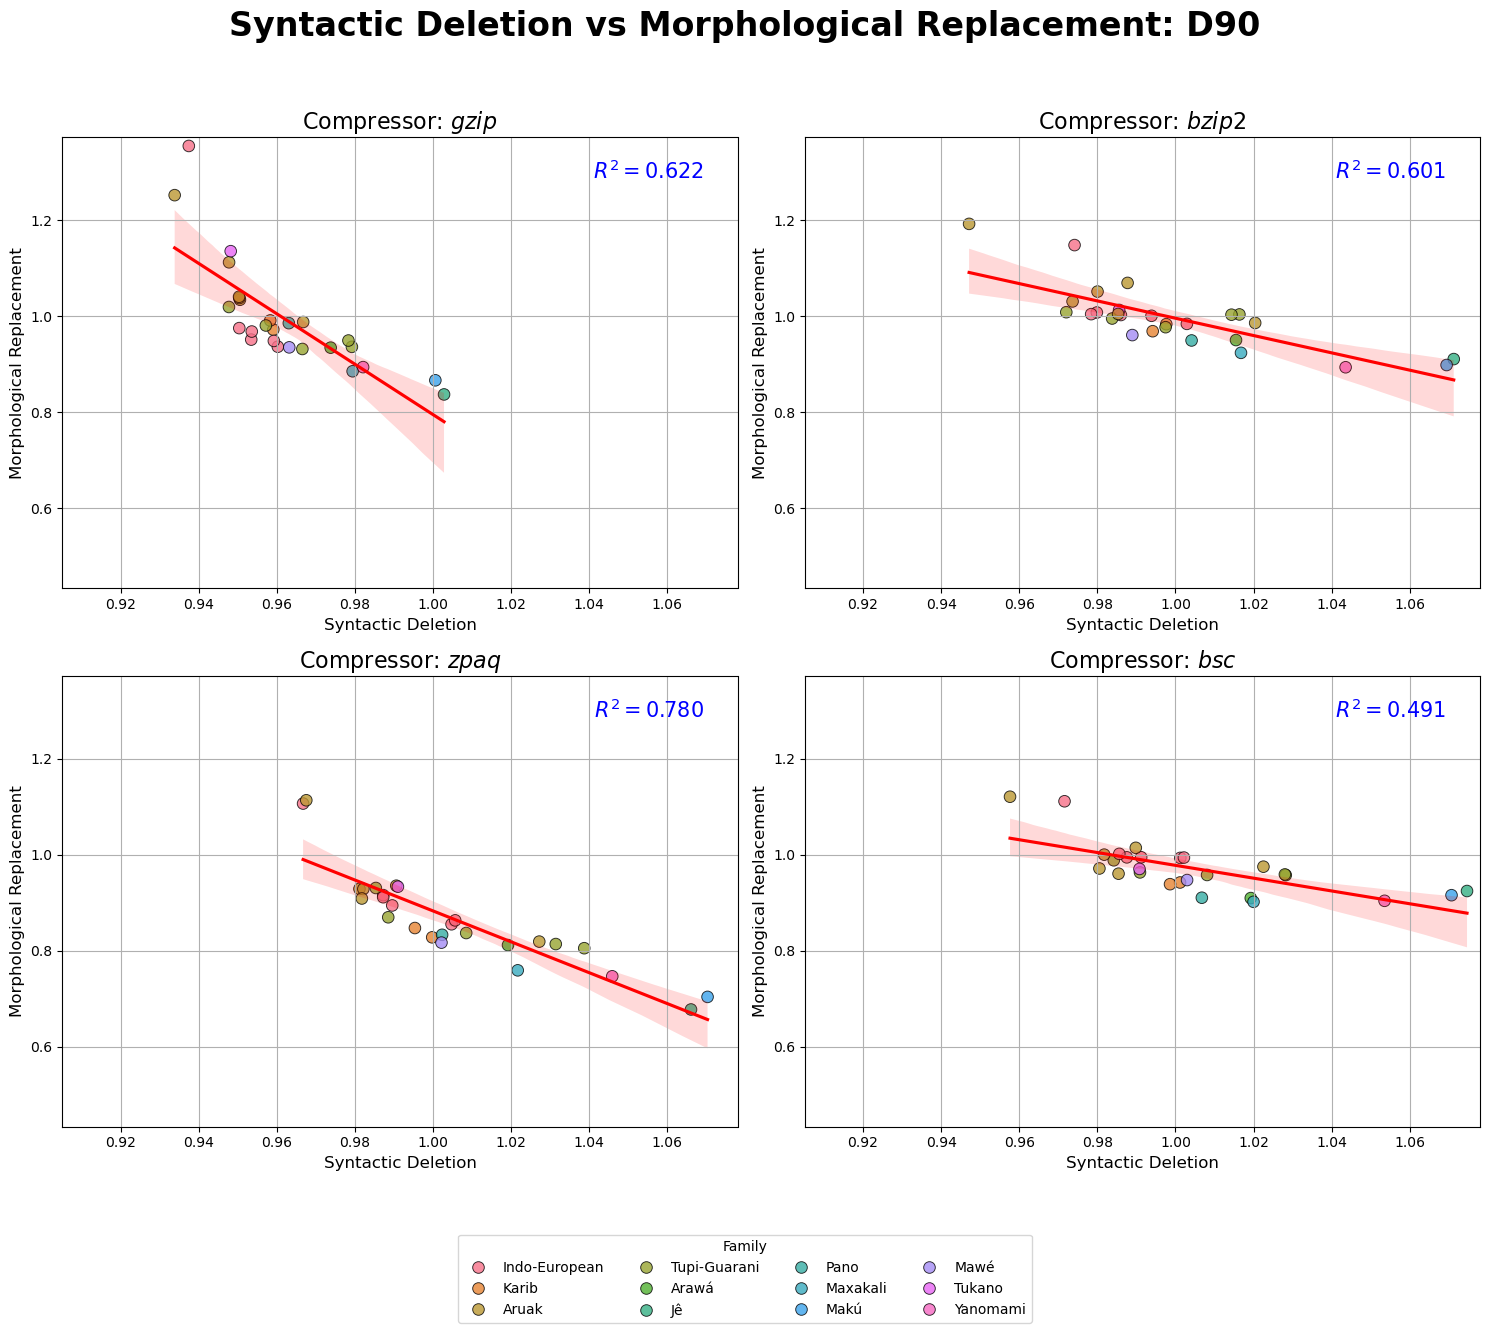

In [120]:
h3_graph(r90, name = "D90", save=True, metric='replacement', equal_axis=True)

### Por família

In [100]:
h3_family(r90)

pearson_r  pearson_p        r2      coef  intercept  \
algorithm family                                                               
gzip      Indo-European  -0.959511   0.002426  0.920661 -1.876054   0.663568   
          Aruak          -0.732428   0.097814  0.536451 -1.288268  -0.007720   
          Tupi-Guarani   -0.834064   0.079092  0.695662 -2.681923   1.365383   
bzip2     Indo-European  -0.831336   0.040272  0.691119 -2.105944   0.774974   
          Aruak          -0.942735   0.004825  0.888750 -1.233154  -0.258274   
          Tupi-Guarani   -0.723388   0.167204  0.523290 -2.030423   0.591367   
zpaq      Indo-European  -0.976217   0.000842  0.952999 -2.639937   1.301221   
          Aruak          -0.926515   0.007902  0.858429 -1.791789   0.287305   
          Tupi-Guarani   -0.775630   0.123196  0.601601 -1.948308   0.518141   
bsc       Indo-European  -0.927013   0.007796  0.859354 -1.941140   0.629582   
          Aruak          -0.942340   0.004891  0.888005 -1.307098  -0.167680   
          Tupi-Guarani   -0.754495   0.140523  0.569262 -2.028151   0.622185   

                         n_samples  
algorithm family                    
gzip      Indo-European          6  
          Aruak                  6  
          Tupi-Guarani           5  
bzip2     Indo-European          6  
          Aruak                  6  
          Tupi-Guarani           5  
zpaq      Indo-European          6  
          Aruak                  6  
          Tupi-Guarani           5  
bsc       Indo-European          6  
          Aruak                  6  
          Tupi-Guarani           5

/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


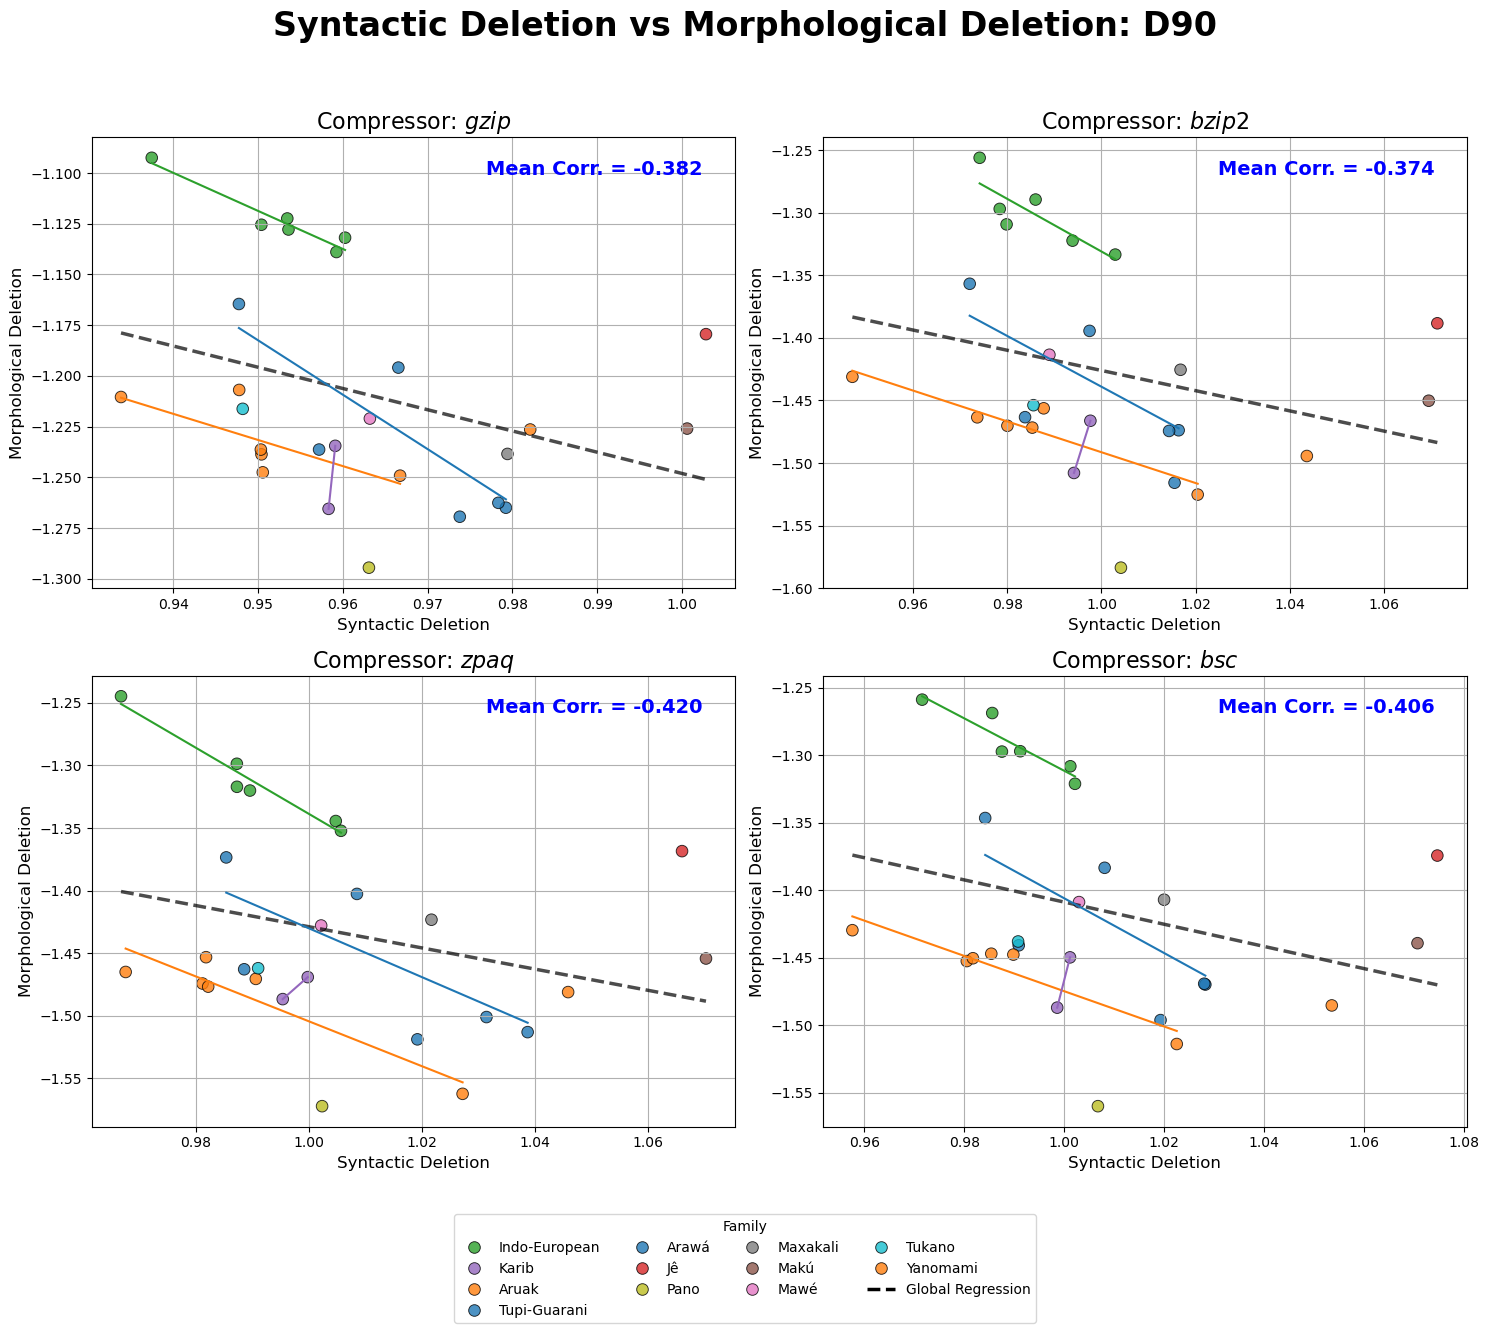

In [35]:
h3_graph_family(r90, name = "D90")

/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


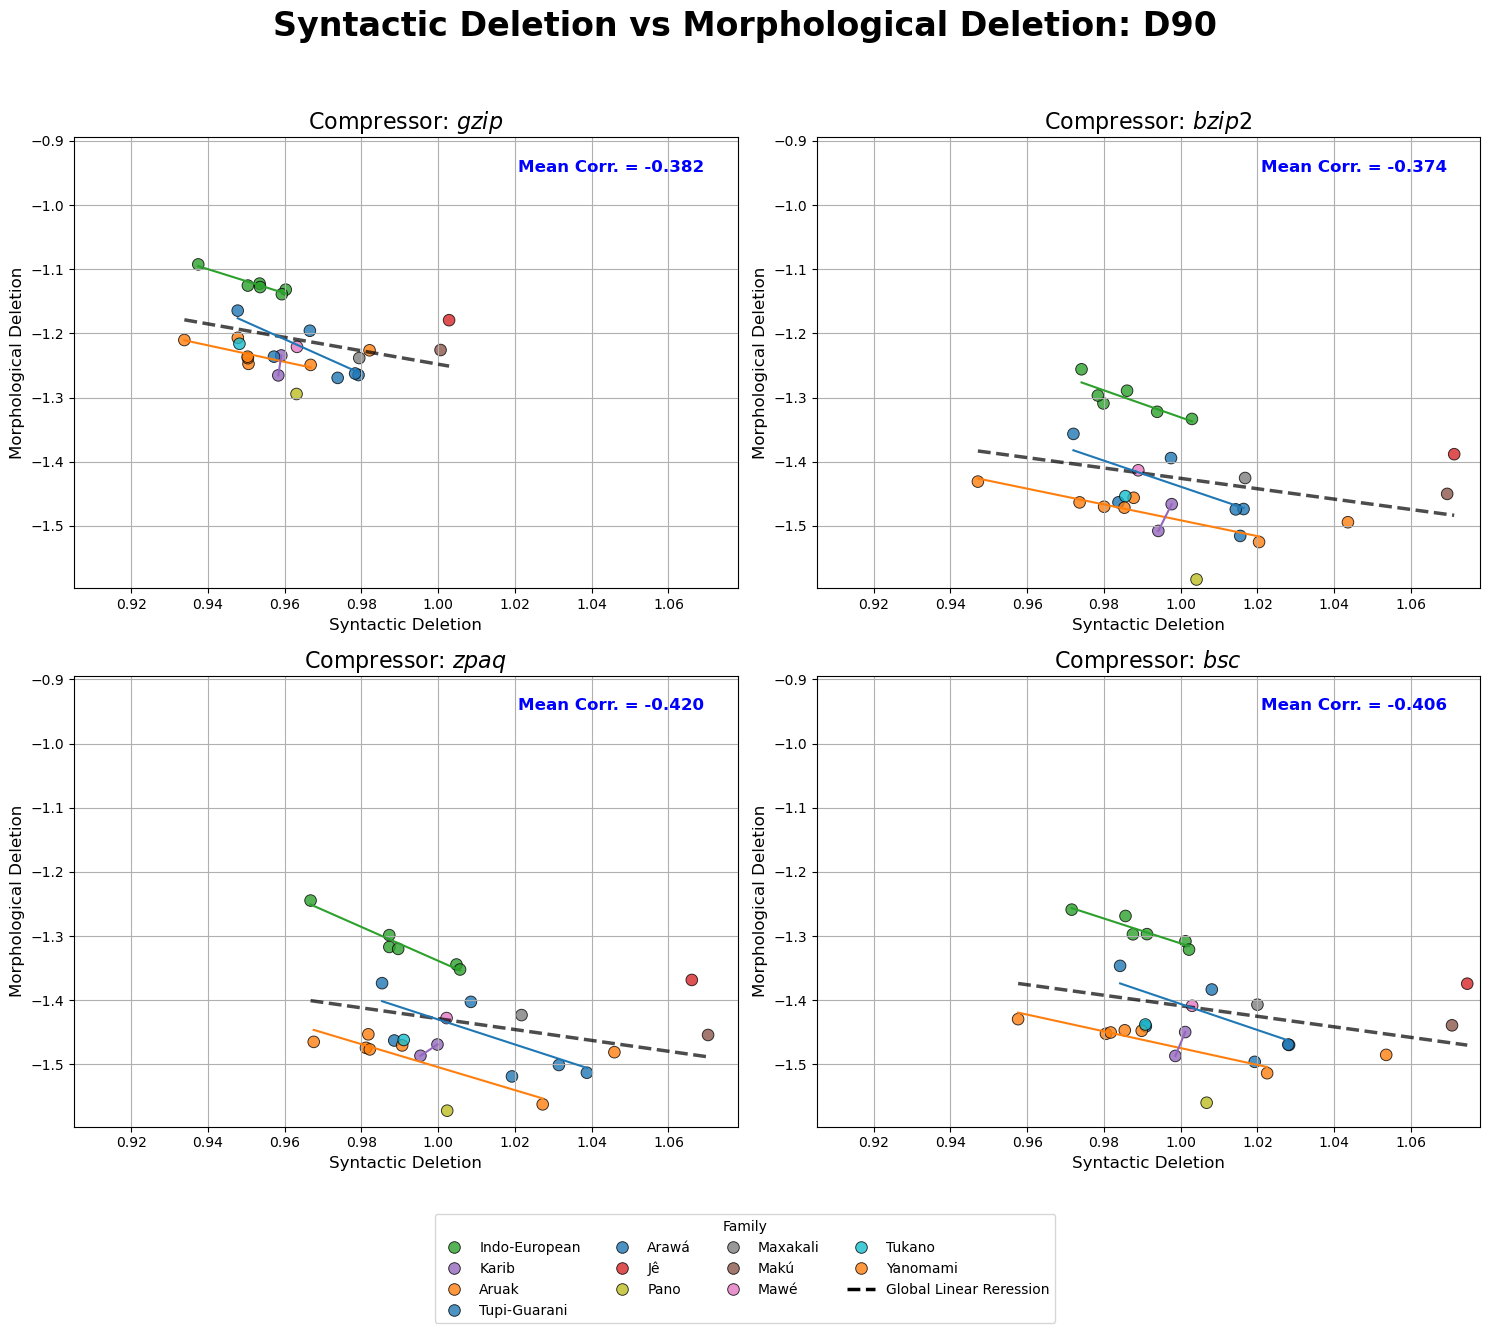

In [18]:
h3_graph_family(r90, name = "D90", save=True, equal_axis=True)

In [103]:
h3_family(r90, metric='replacement')

pearson_r  pearson_p        r2       coef  intercept  \
algorithm family                                                                
gzip      Indo-European  -0.920948   0.009127  0.848145 -18.307296  18.458271   
          Aruak          -0.901935   0.013954  0.813487  -8.143055   8.812993   
          Tupi-Guarani   -0.865932   0.057728  0.749838  -2.333122   3.216693   
bzip2     Indo-European  -0.629996   0.180027  0.396895  -3.564020   4.538194   
          Aruak          -0.840726   0.036032  0.706820  -2.607803   3.617549   
          Tupi-Guarani   -0.033483   0.957376  0.001121  -0.021535   1.018878   
zpaq      Indo-European  -0.929659   0.007248  0.864266  -6.031515   6.896737   
          Aruak          -0.814454   0.048447  0.663336  -3.830133   4.724652   
          Tupi-Guarani   -0.901589   0.036508  0.812863  -1.893873   2.764864   
bsc       Indo-European  -0.817485   0.046928  0.668282  -3.421590   4.401859   
          Aruak          -0.662757   0.151421  0.439247  -1.870445   2.851716   
          Tupi-Guarani   -0.742792   0.150401  0.551741  -0.480382   1.449188   

                         n_samples  
algorithm family                    
gzip      Indo-European          6  
          Aruak                  6  
          Tupi-Guarani           5  
bzip2     Indo-European          6  
          Aruak                  6  
          Tupi-Guarani           5  
zpaq      Indo-European          6  
          Aruak                  6  
          Tupi-Guarani           5  
bsc       Indo-European          6  
          Aruak                  6  
          Tupi-Guarani           5

/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


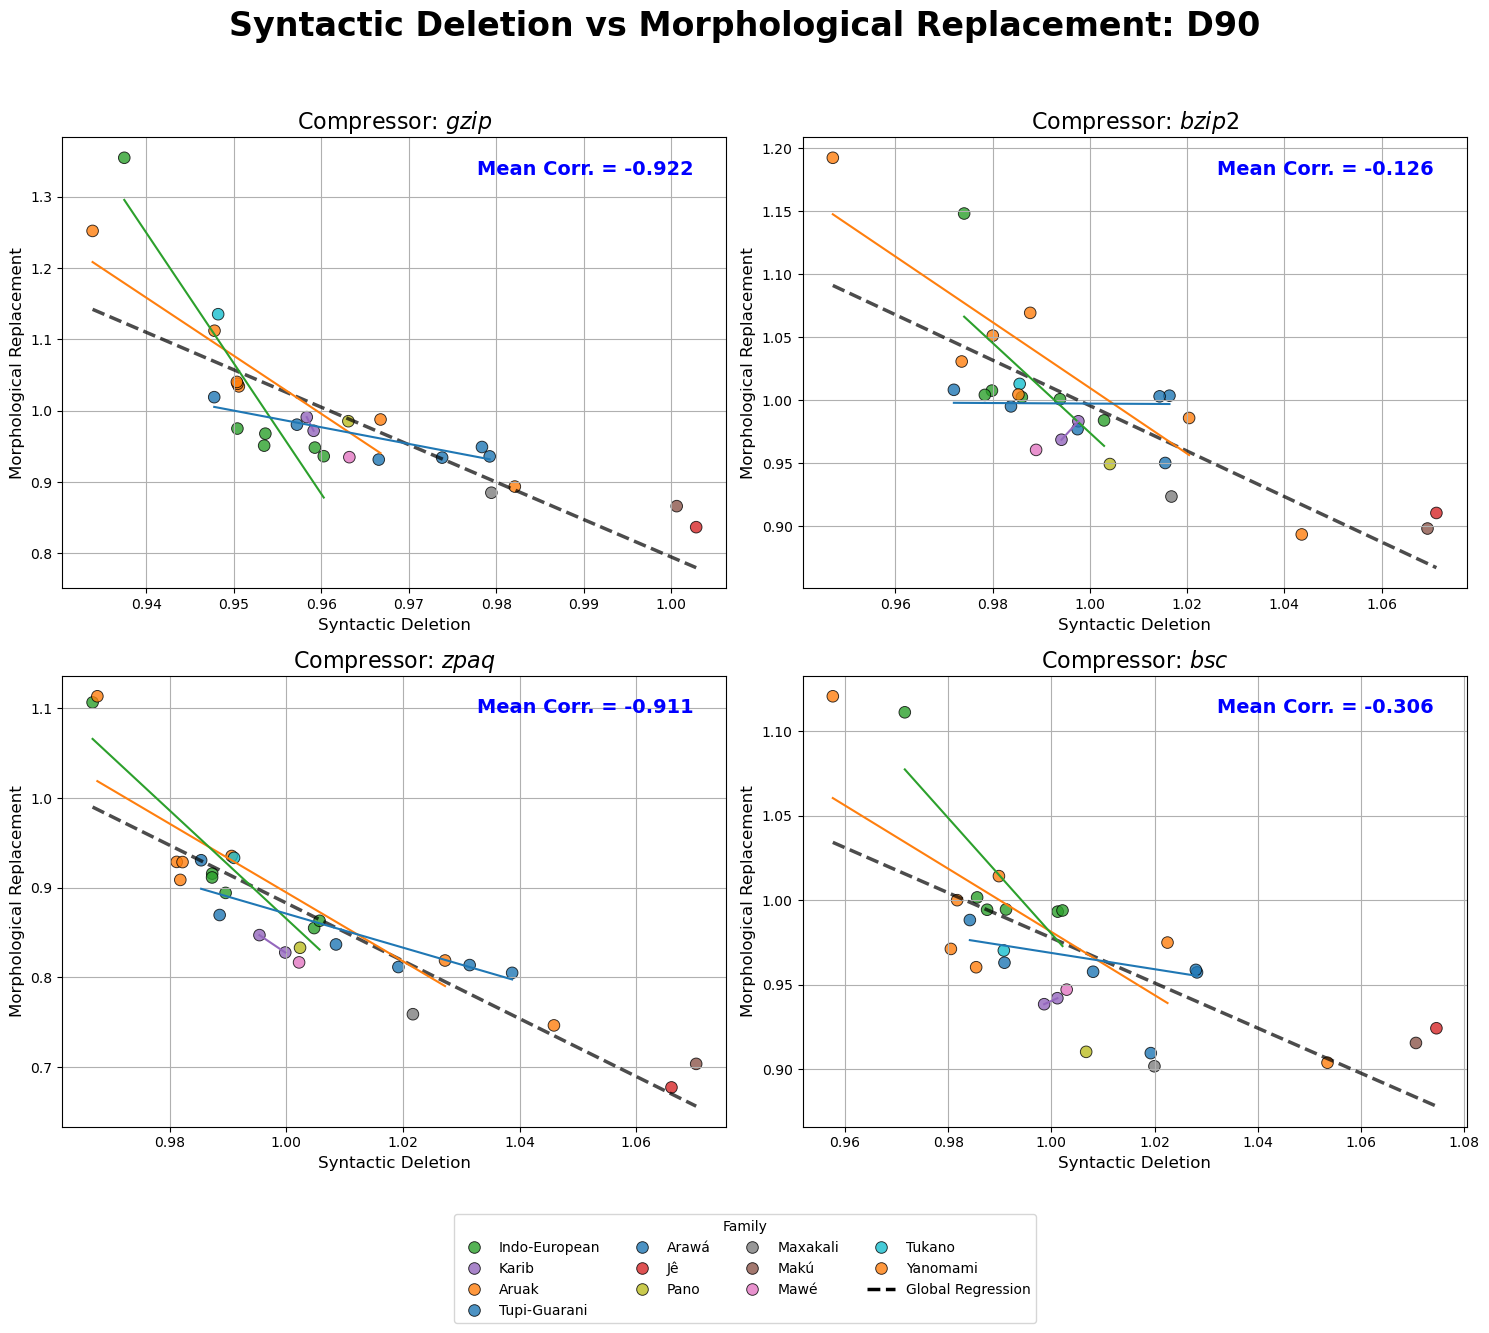

In [11]:
h3_graph_family(r90, name = "D90", metric='replacement', save=True)

/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


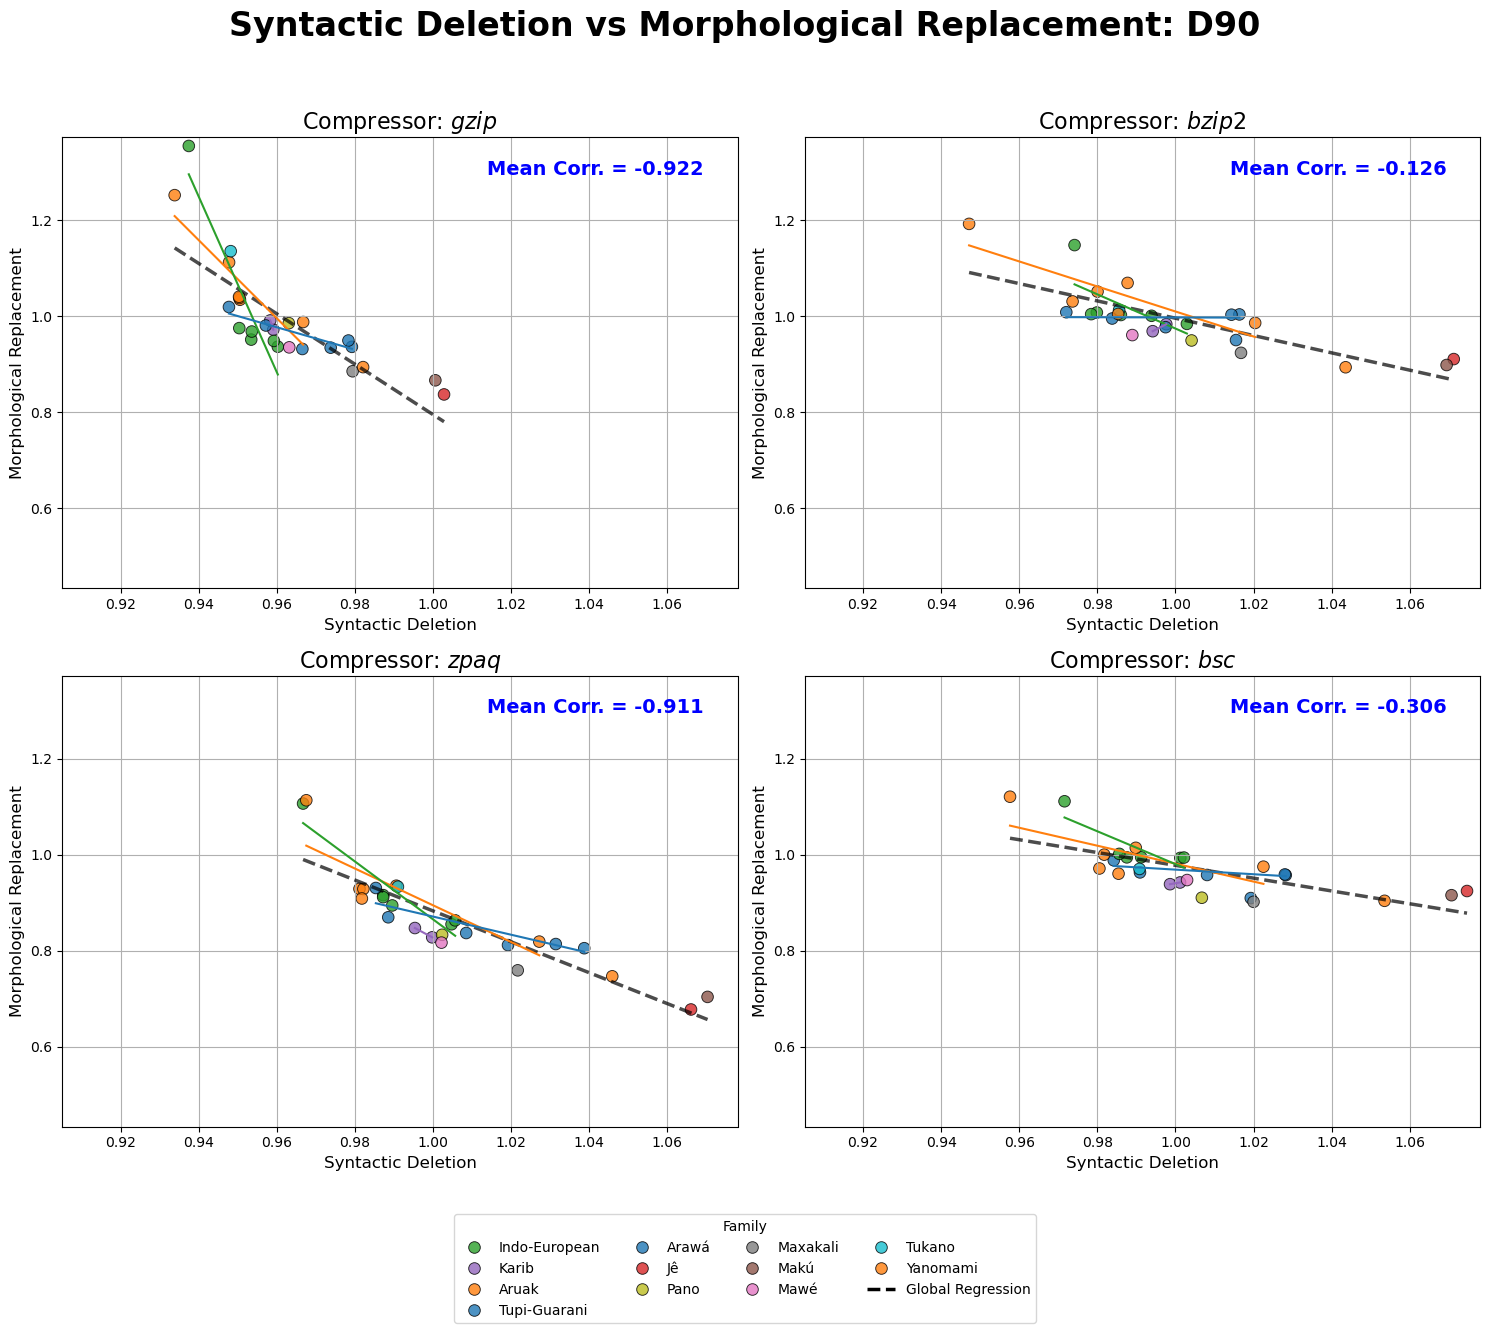

In [12]:
h3_graph_family(r90, name = "D90", metric='replacement', save=True, equal_axis=True)

## DALL

### Todas as línguas

In [84]:
h3_overall(rall)

,pearson_r,pearson_p,r2,coef,intercept
algorithm,,,,,
gzip,-0.456913,0.000400,0.208770,-1.300443,0.036626
bzip2,-0.450412,0.000495,0.202871,-1.302593,-0.111508
zpaq,-0.362729,0.006006,0.131573,-1.056563,-0.350065
bsc,-0.431727,0.000893,0.186388,-1.186521,-0.199727


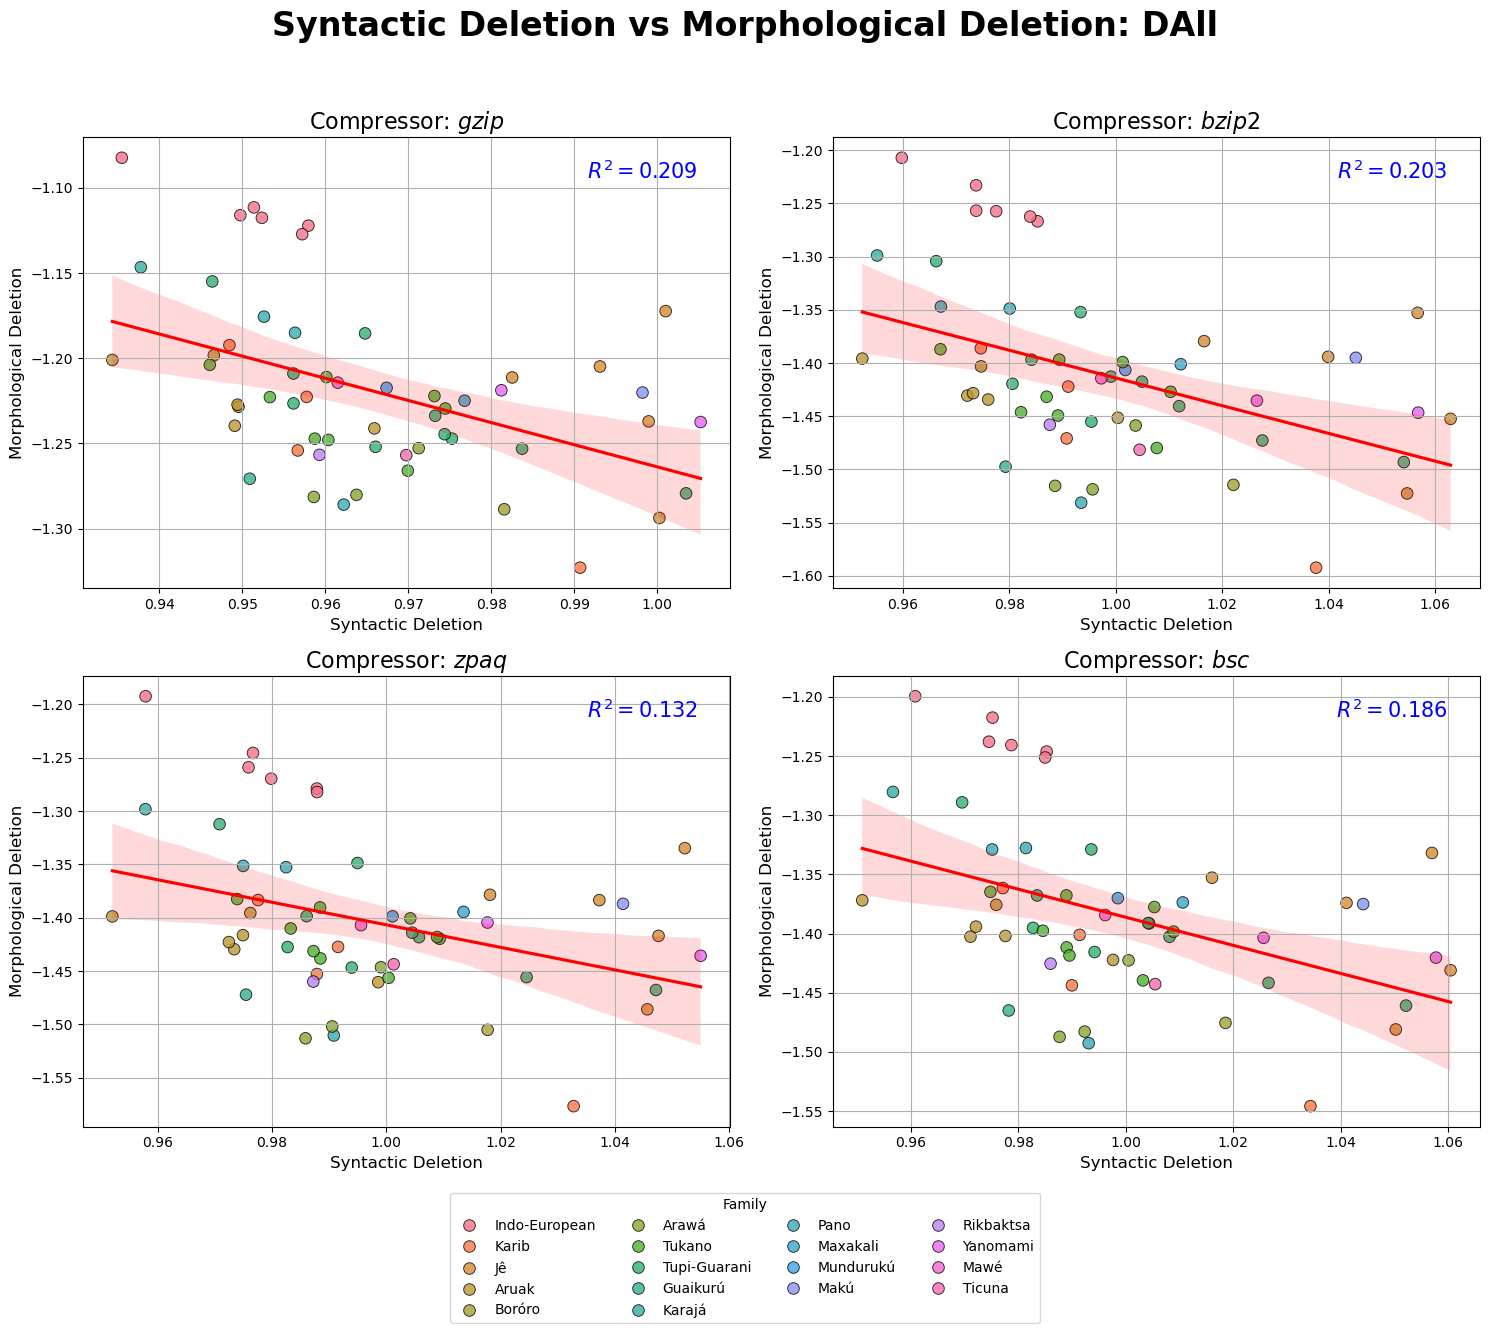

In [133]:
h3_graph(rall, name = "DAll", save=True)

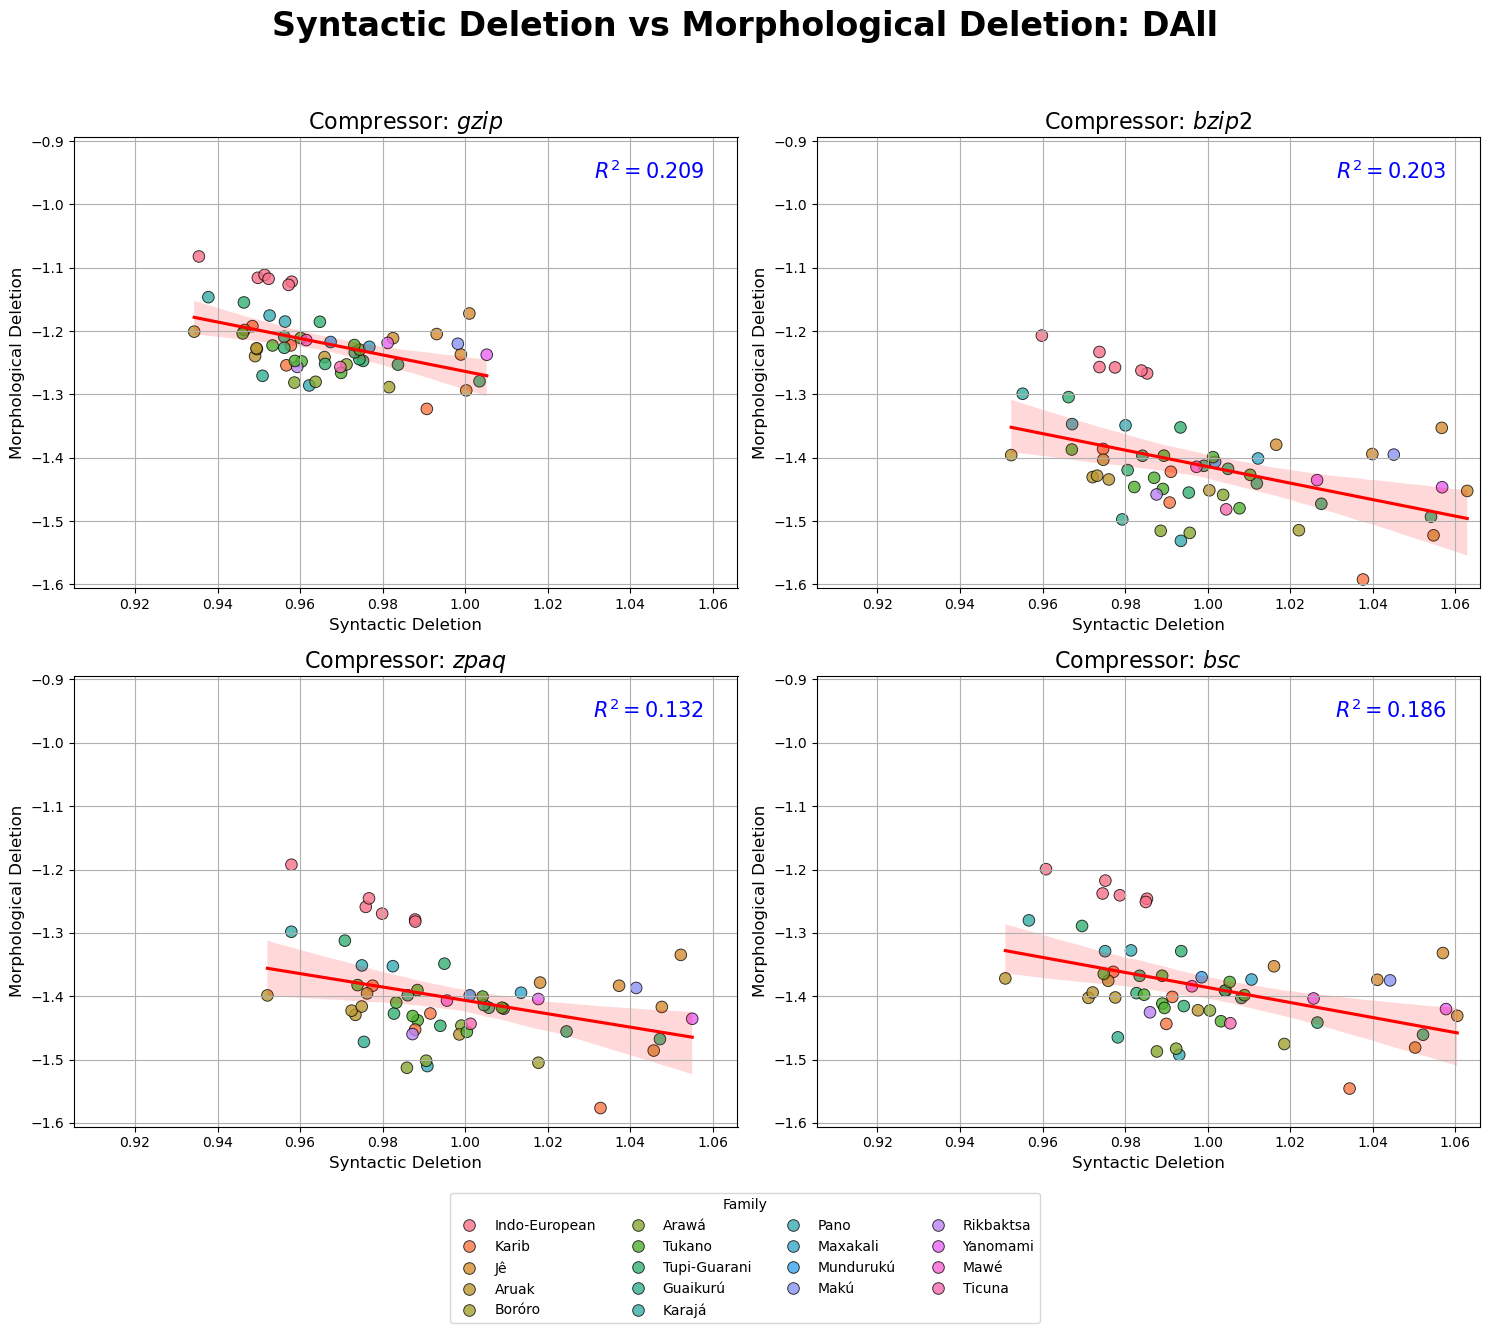

In [134]:
h3_graph(rall, name = "DAll", save=True, equal_axis=True)

In [85]:
h3_overall(rall, metric='replacement')

,pearson_r,pearson_p,r2,coef,intercept
algorithm,,,,,
gzip,-0.846808,1.984589e-16,0.717084,-5.222557,6.056042
bzip2,-0.864700,8.826576e-18,0.747706,-2.676457,3.699348
zpaq,-0.927812,8.715252e-25,0.860836,-4.158731,5.055911
bsc,-0.774927,2.399136e-12,0.600512,-2.127477,3.120665


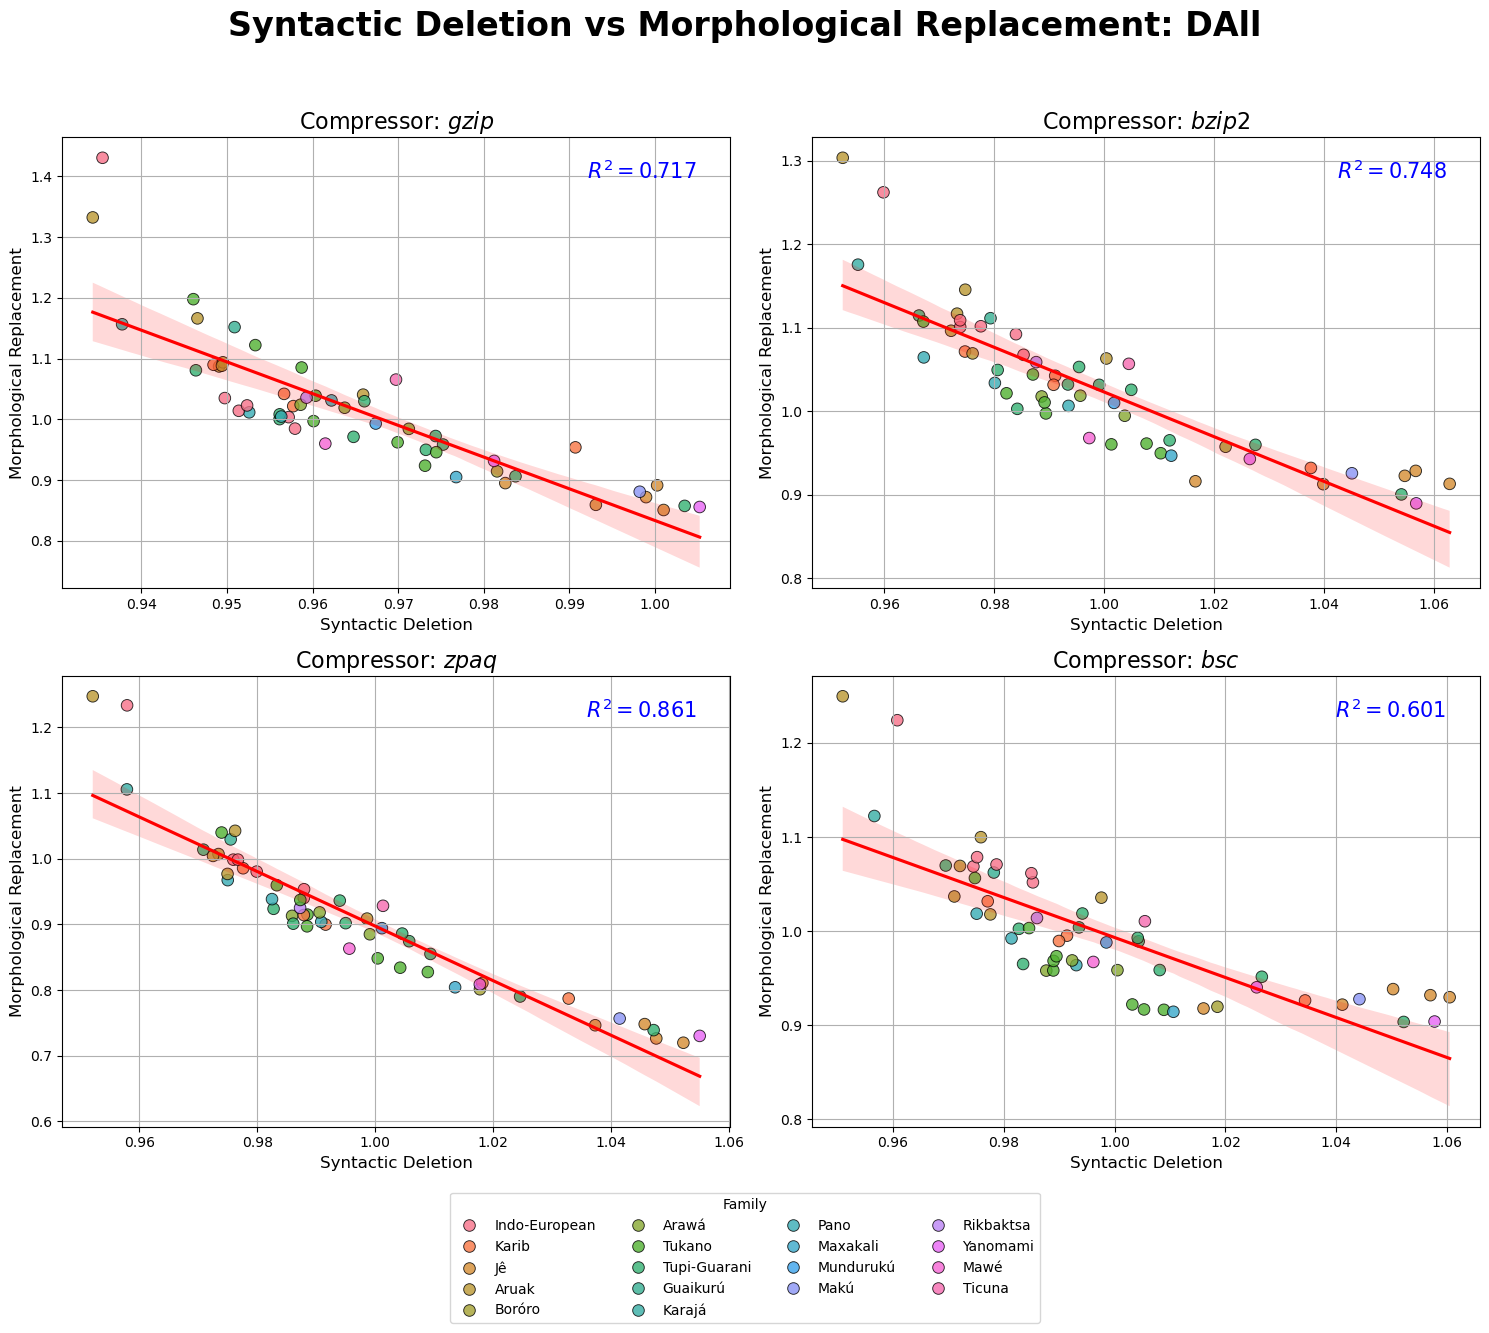

In [47]:
h3_graph(rall, name = "DAll", save=True, metric='replacement')

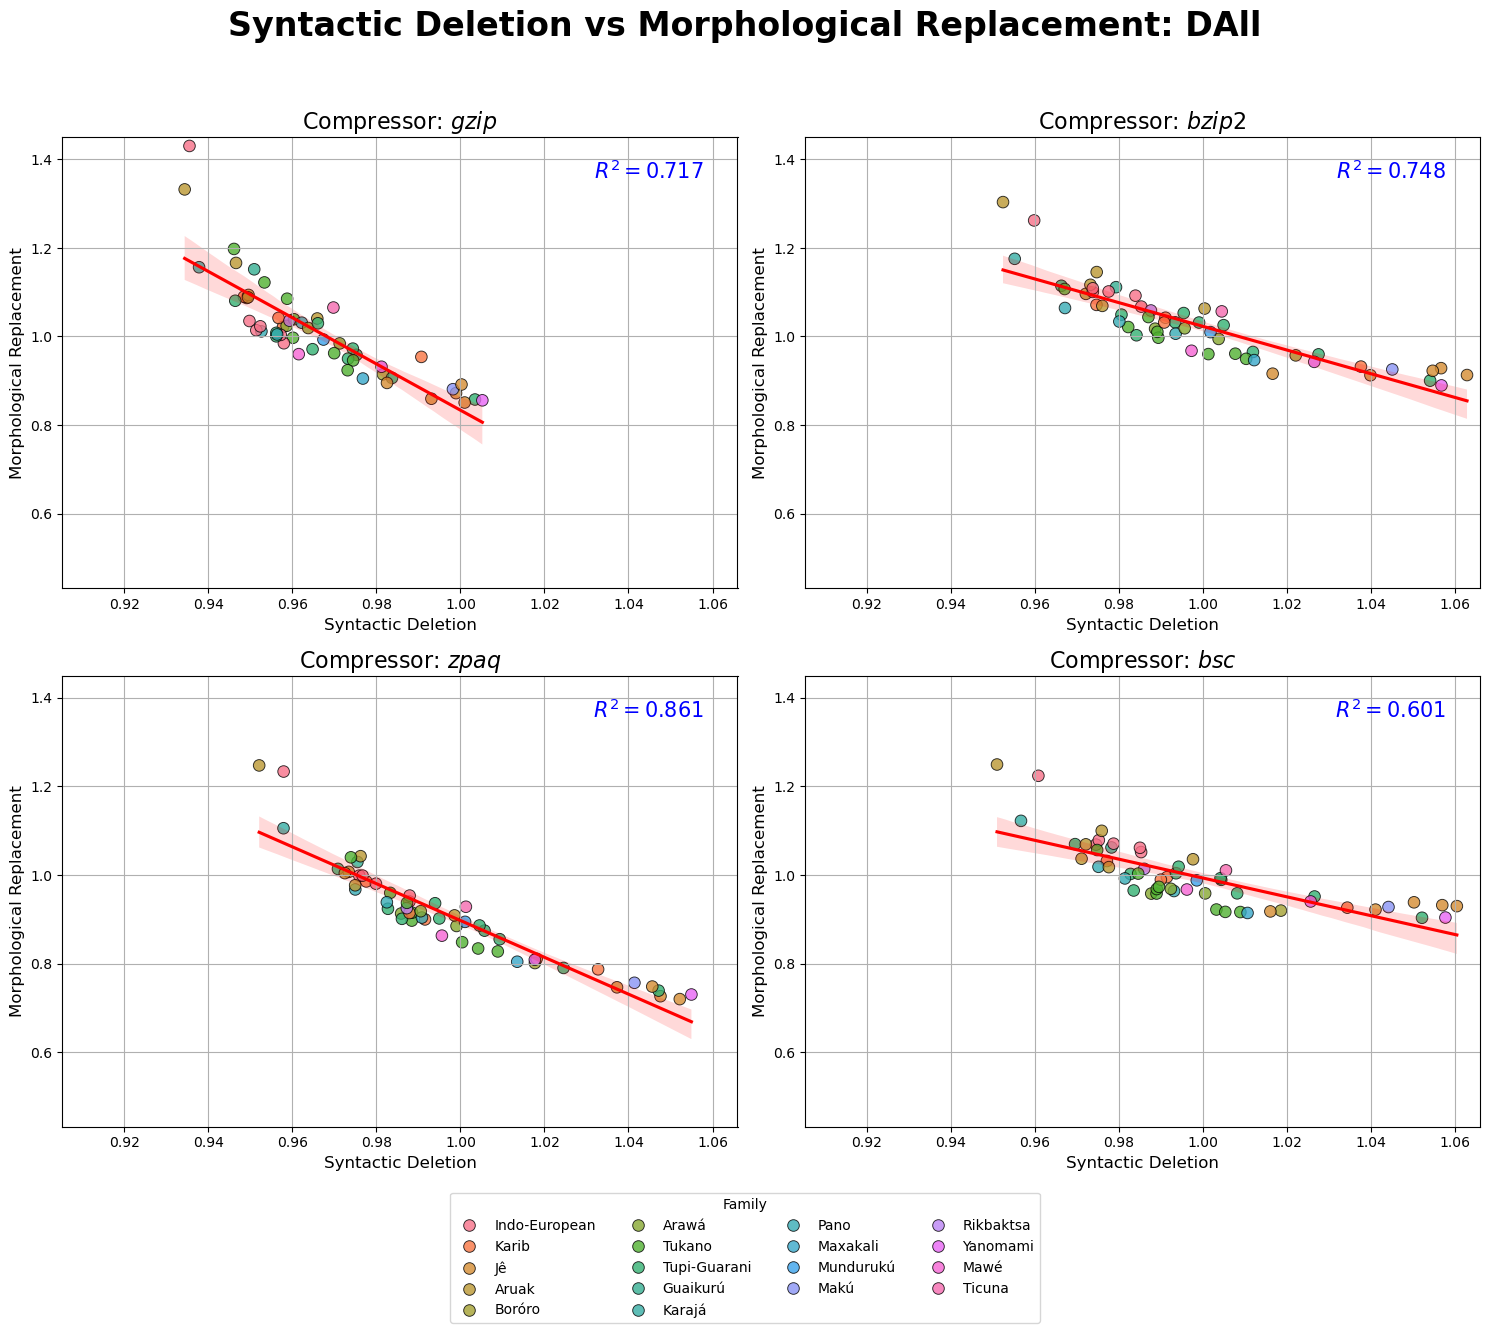

In [135]:
h3_graph(rall, name = "DAll", save=True, metric='replacement', equal_axis=True)

### Por famílias

In [86]:
h3_family(rall)

pearson_r  pearson_p        r2       coef  intercept  \
algorithm family                                                                
gzip      Indo-European  -0.975524   0.000891  0.951646  -1.902687   0.696085   
          Karib          -0.950745   0.049255  0.903917  -2.850195   1.497815   
          Jê             -0.216282   0.726784  0.046778  -1.271214   0.041180   
          Aruak          -0.739942   0.092652  0.547514  -1.374653   0.082083   
          Arawá           0.929028   0.241291  0.863093   2.367726  -3.555244   
          Tukano         -0.428069   0.290031  0.183243  -0.902798  -0.362839   
          Tupi-Guarani   -0.826033   0.003230  0.682331  -1.870045   0.585269   
          Pano           -0.949546   0.203089  0.901637 -11.998939  10.268119   
bzip2     Indo-European  -0.928578   0.007469  0.862258  -2.309630   1.006117   
          Karib          -0.973347   0.026653  0.947404  -3.222061   1.749416   
          Jê             -0.411914   0.490769  0.169673  -1.504981   0.154080   
          Aruak          -0.835563   0.038336  0.698165  -1.133897  -0.318685   
          Arawá           0.861912   0.338534  0.742892   3.839103  -5.321352   
          Tukano         -0.434933   0.281508  0.189167  -0.962237  -0.472887   
          Tupi-Guarani   -0.813366   0.004209  0.661564  -1.818551   0.405192   
          Pano           -0.875524   0.321032  0.766543  -7.034154   5.486125   
zpaq      Indo-European  -0.976446   0.000826  0.953447  -2.948544   1.628111   
          Karib          -0.978220   0.021780  0.956915  -3.336241   1.867679   
          Jê             -0.110278   0.859874  0.012161  -0.460692  -0.920720   
          Aruak          -0.796424   0.057946  0.634291  -1.273425  -0.179460   
          Arawá           0.979987   0.127579  0.960374   5.223400  -6.667797   
          Tukano         -0.382961   0.349065  0.146659  -0.822909  -0.599716   
          Tupi-Guarani   -0.715949   0.019876  0.512583  -1.563717   0.155914   
          Pano           -0.884003   0.309676  0.781462 -10.185184   8.604696   
bsc       Indo-European  -0.927438   0.007707  0.860141  -2.032584   0.752821   
          Karib          -0.963067   0.036933  0.927498  -3.063315   1.619790   
          Jê             -0.358540   0.553472  0.128551  -1.231537  -0.107260   
          Aruak          -0.816601   0.047368  0.666838  -1.024400  -0.396804   
          Arawá           0.953297   0.195332  0.908775   5.299406  -6.729331   
          Tukano         -0.366875   0.371342  0.134597  -0.819273  -0.583429   
          Tupi-Guarani   -0.817302   0.003885  0.667982  -1.738617   0.353462   
          Pano           -0.936431   0.228216  0.876903  -9.742148   8.195507   

                         n_samples  
algorithm family                    
gzip      Indo-European          6  
          Karib                  4  
          Jê                     5  
          Aruak                  6  
          Arawá                  3  
          Tukano                 8  
          Tupi-Guarani          10  
          Pano                   3  
bzip2     Indo-European          6  
          Karib                  4  
          Jê                     5  
          Aruak                  6  
          Arawá                  3  
          Tukano                 8  
          Tupi-Guarani          10  
          Pano                   3  
zpaq      Indo-European          6  
          Karib                  4  
          Jê                     5  
          Aruak                  6  
          Arawá                  3  
          Tukano                 8  
          Tupi-Guarani          10  
          Pano                   3  
bsc       Indo-European          6  
          Karib                  4  
          Jê                     5  
          Aruak                  6  
          Arawá                  3  
          Tukano                 8  
          Tupi-Guarani          10  
          Pano                   3

/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


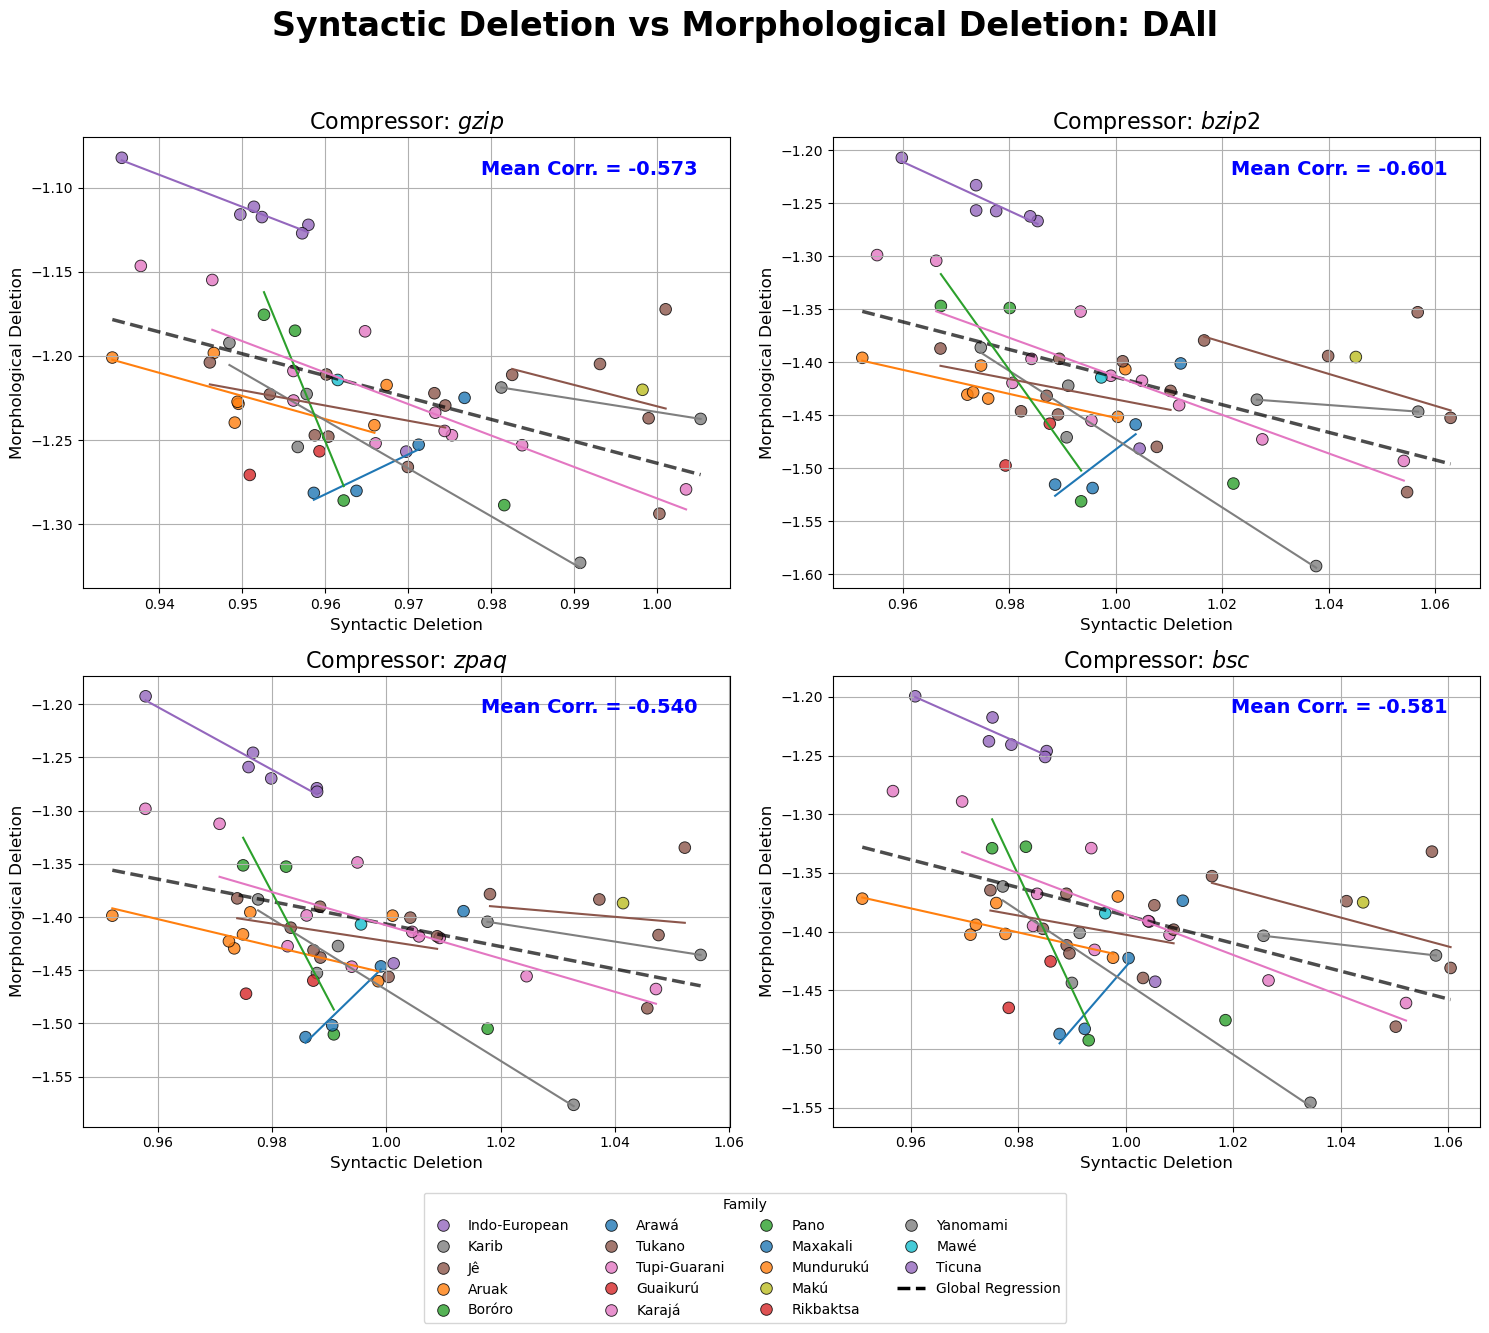

In [41]:
h3_graph_family(rall, name = "DAll", save = True)

/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


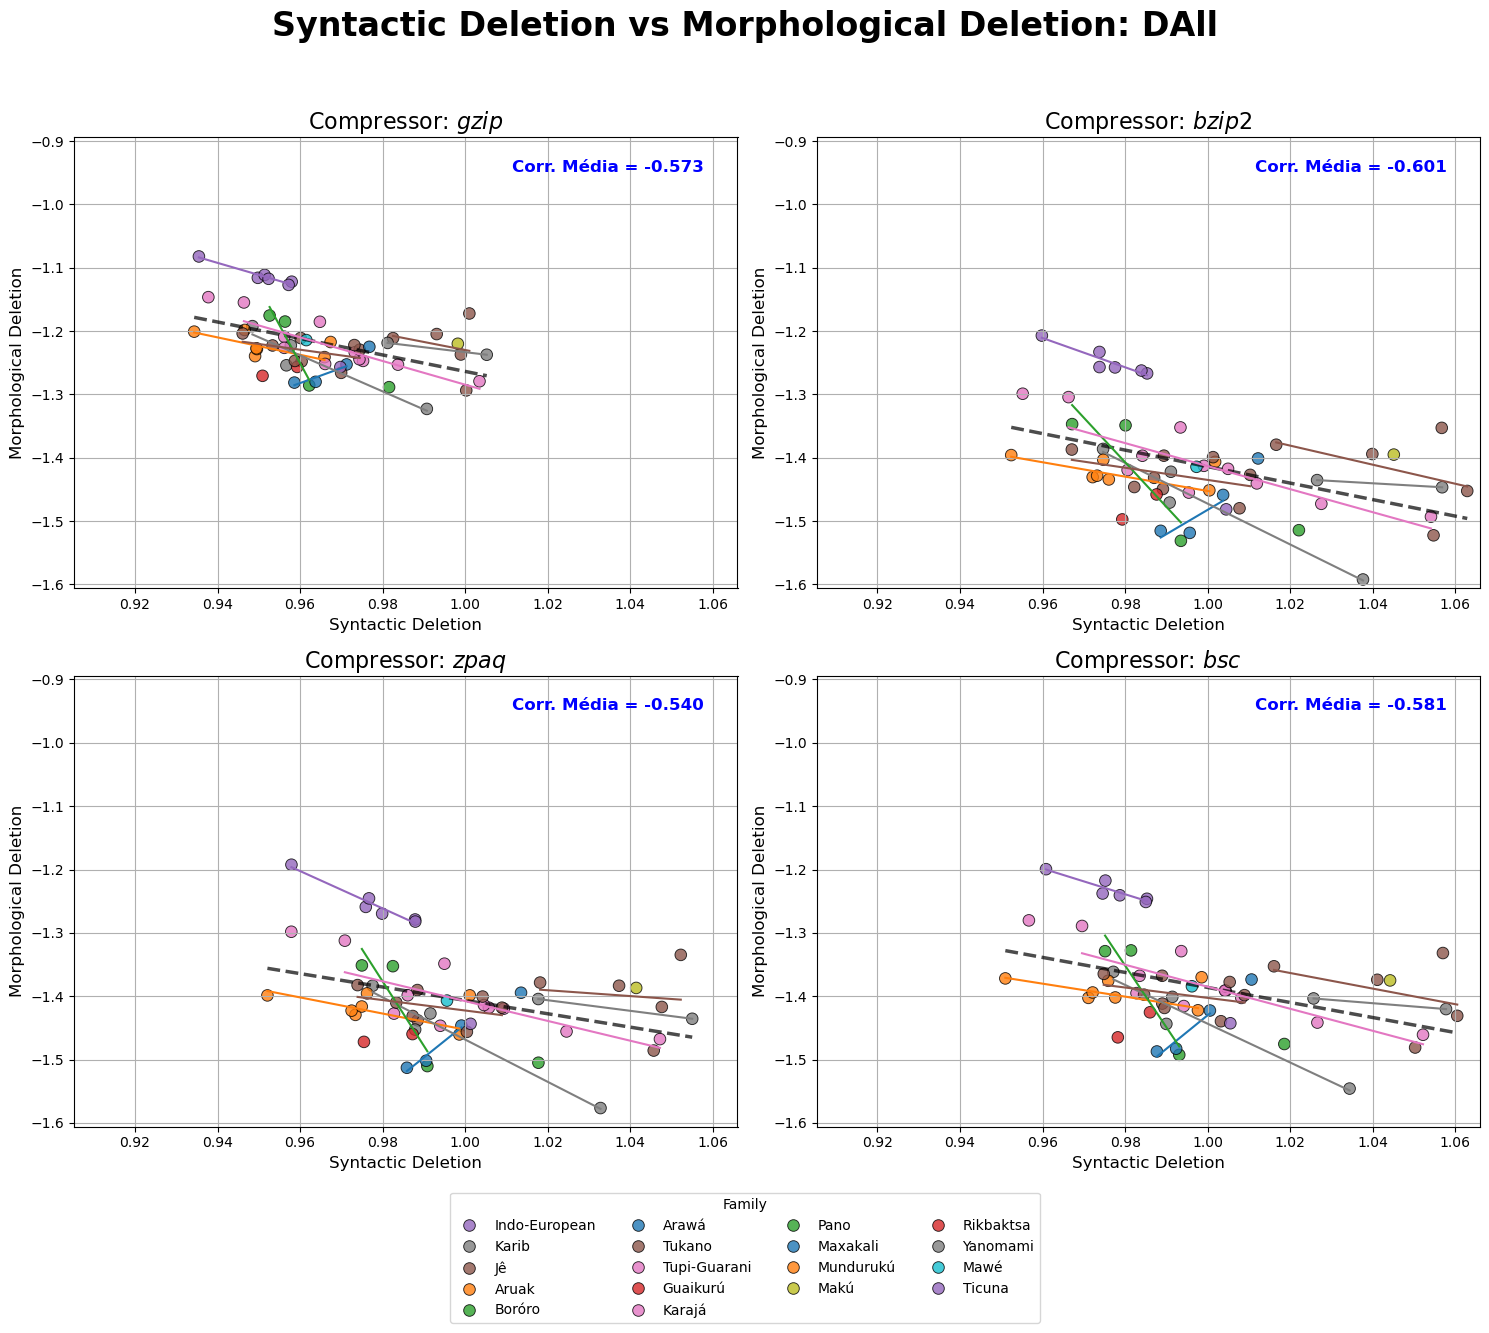

In [24]:
h3_graph_family(rall, name = "DAll", save=True, equal_axis=True)

In [87]:
h3_family(rall, metric = 'replacement')

pearson_r  pearson_p        r2       coef  intercept  \
algorithm family                                                                
gzip      Indo-European  -0.948258   0.003947  0.899194 -20.010451  20.105658   
          Karib          -0.951478   0.048522  0.905310  -2.873963   3.795647   
          Jê             -0.485236   0.407361  0.235454  -1.219164   2.087054   
          Aruak          -0.873061   0.023148  0.762235  -9.088540   9.761098   
          Arawá          -0.954853   0.192026  0.911743  -3.253588   4.147435   
          Tukano         -0.963051   0.000123  0.927467  -9.267593   9.949783   
          Tupi-Guarani   -0.939088   0.000056  0.881886  -3.642722   4.506841   
          Pano            0.794820   0.415131  0.631739   2.262725  -1.149759   
bzip2     Indo-European  -0.920494   0.009231  0.847309  -7.010371   7.962166   
          Karib          -0.996923   0.003077  0.993855  -2.225242   3.241327   
          Jê              0.309207   0.612672  0.095609   0.114517   0.798676   
          Aruak          -0.816321   0.047508  0.666381  -4.766789   5.779129   
          Arawá          -0.869083   0.329420  0.755305  -1.563222   2.567172   
          Tukano         -0.956150   0.000204  0.914224  -3.522585   4.499989   
          Tupi-Guarani   -0.919808   0.000164  0.846047  -2.191557   3.208721   
          Pano           -0.999145   0.026329  0.998291  -2.204989   3.196274   
zpaq      Indo-European  -0.960055   0.002362  0.921706  -9.448875  10.255535   
          Karib          -0.973548   0.026452  0.947795  -3.292971   4.181109   
          Jê             -0.969704   0.006301  0.940325  -2.596239   3.450703   
          Aruak          -0.908782   0.012102  0.825885  -7.077489   7.928990   
          Arawá          -0.875624   0.320900  0.766718  -2.345941   3.232122   
          Tukano         -0.967975   0.000080  0.936976  -5.996367   6.854799   
          Tupi-Guarani   -0.963877   0.000007  0.929059  -3.356997   4.245730   
          Pano           -0.999775   0.013518  0.999549  -4.010262   4.877626   
bsc       Indo-European  -0.910504   0.011656  0.829018  -6.579856   7.518404   
          Karib          -0.981129   0.018871  0.962614  -1.722056   2.704611   
          Jê              0.770259   0.127535  0.593298   0.354734   0.557194   
          Aruak          -0.779911   0.067328  0.608261  -4.479895   5.449180   
          Arawá          -0.117936   0.924744  0.013909  -0.110959   1.071999   
          Tukano         -0.959168   0.000165  0.920004  -3.985162   4.921684   
          Tupi-Guarani   -0.859331   0.001440  0.738450  -1.616907   2.605470   
          Pano           -0.988971   0.094637  0.978064  -2.966897   3.908619   

                         n_samples  
algorithm family                    
gzip      Indo-European          6  
          Karib                  4  
          Jê                     5  
          Aruak                  6  
          Arawá                  3  
          Tukano                 8  
          Tupi-Guarani          10  
          Pano                   3  
bzip2     Indo-European          6  
          Karib                  4  
          Jê                     5  
          Aruak                  6  
          Arawá                  3  
          Tukano                 8  
          Tupi-Guarani          10  
          Pano                   3  
zpaq      Indo-European          6  
          Karib                  4  
          Jê                     5  
          Aruak                  6  
          Arawá                  3  
          Tukano                 8  
          Tupi-Guarani          10  
          Pano                   3  
bsc       Indo-European          6  
          Karib                  4  
          Jê                     5  
          Aruak                  6  
          Arawá                  3  
          Tukano                 8  
          Tupi-Guarani          10  
          Pano                   3

/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


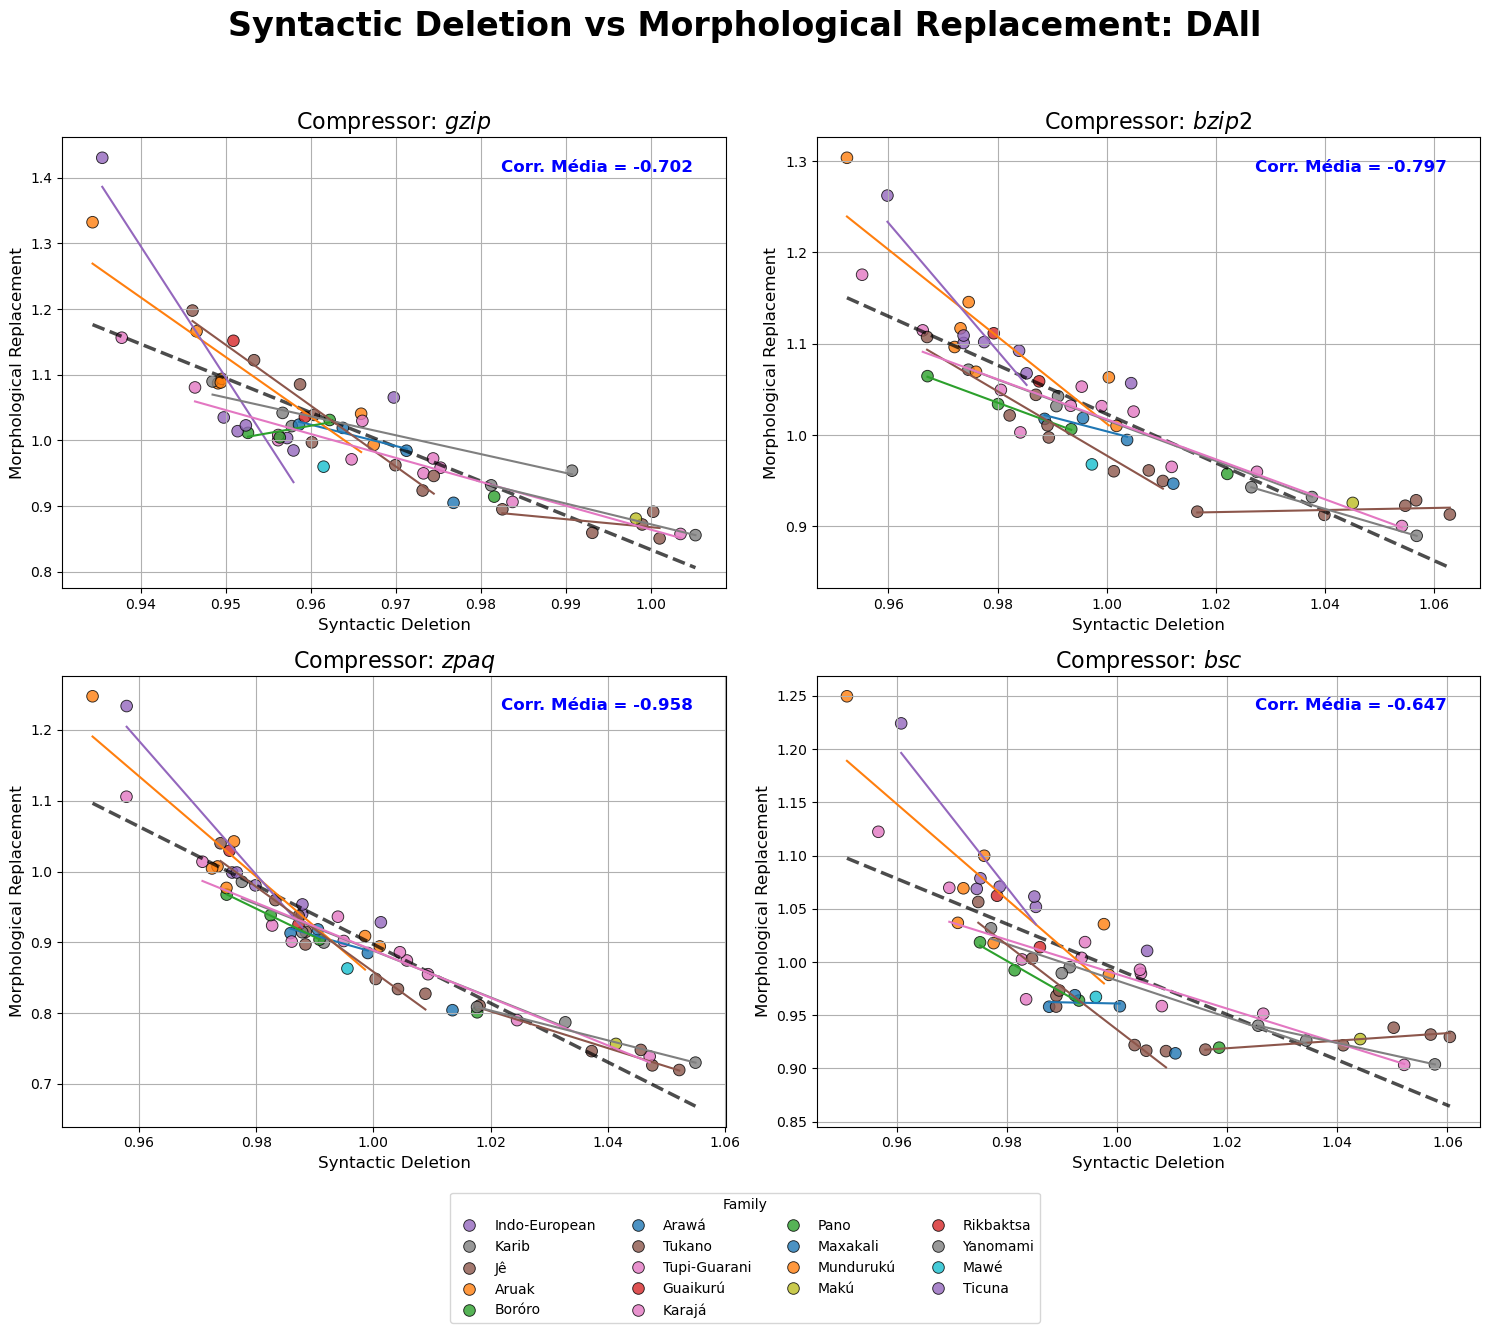

In [25]:
h3_graph_family(rall, name = "DAll", metric='replacement', save=True)

/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/rurineco/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


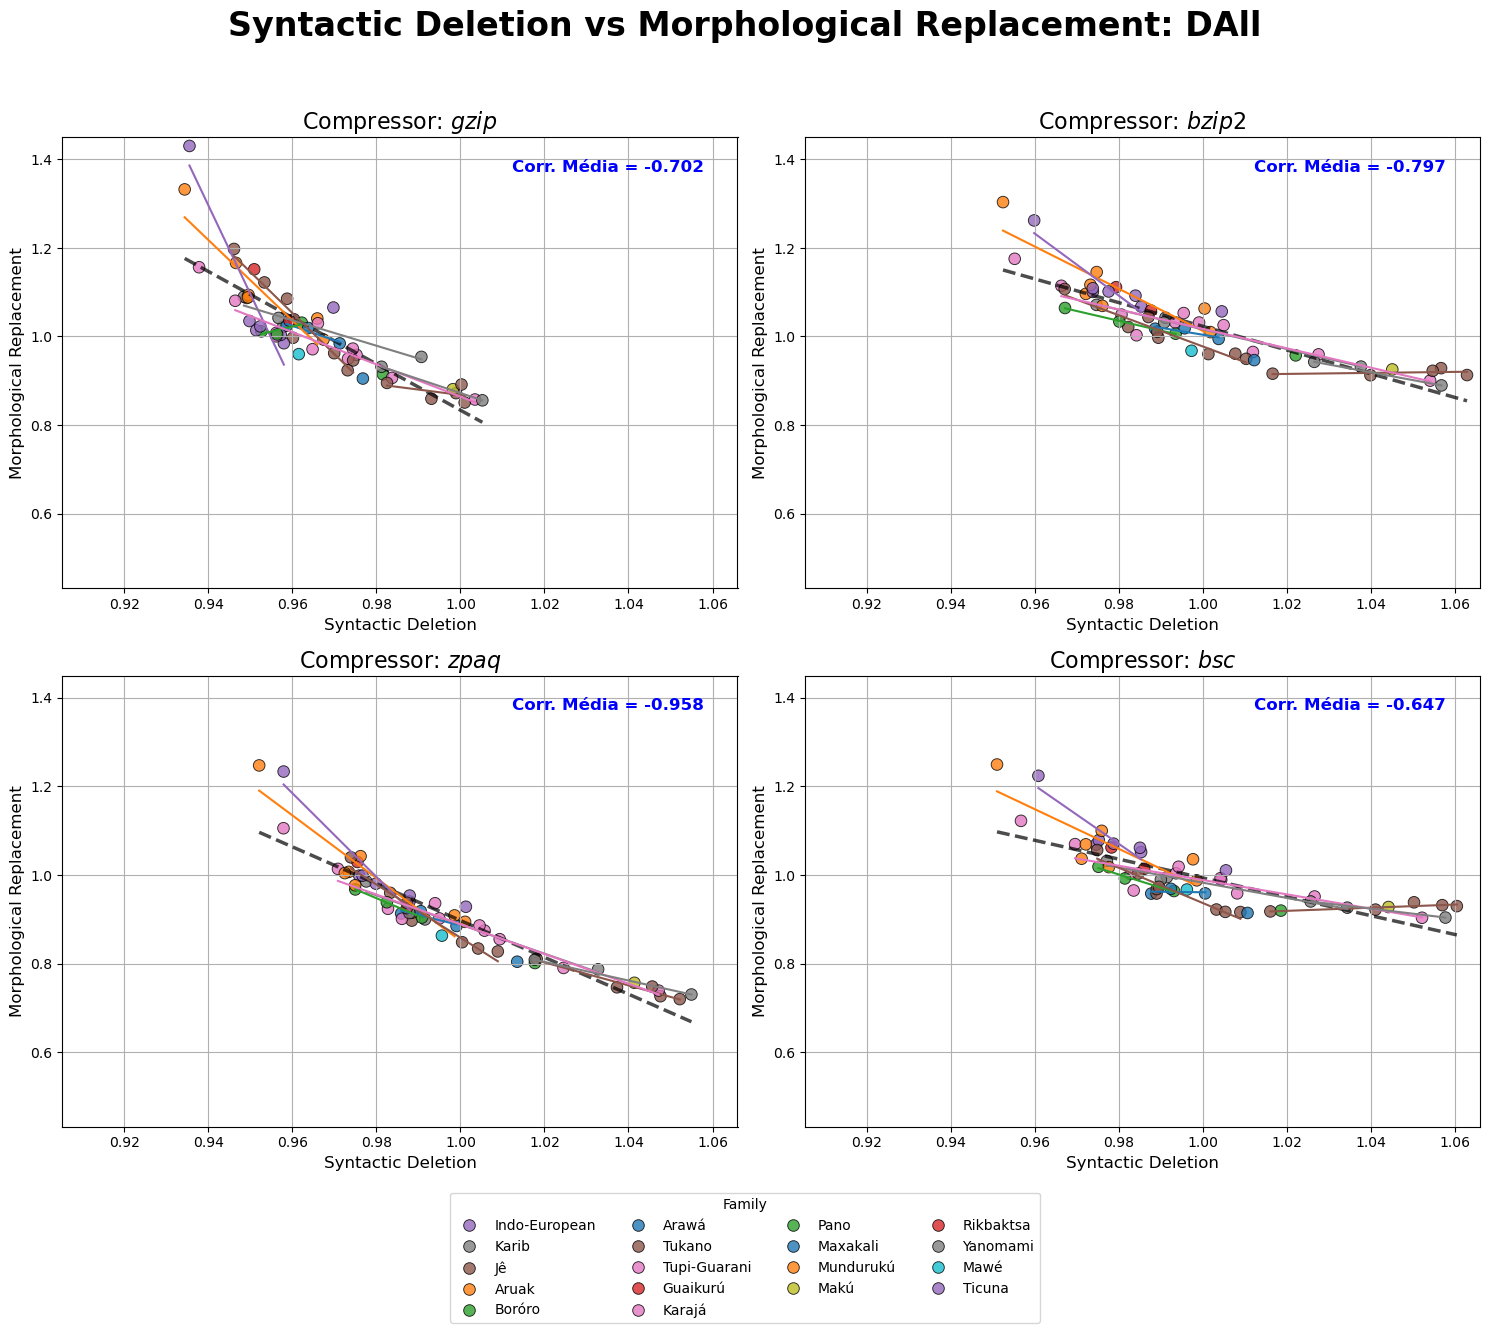

In [26]:
h3_graph_family(rall, name = "DAll", metric='replacement', save=True, equal_axis=True)

### Indo-Europeias

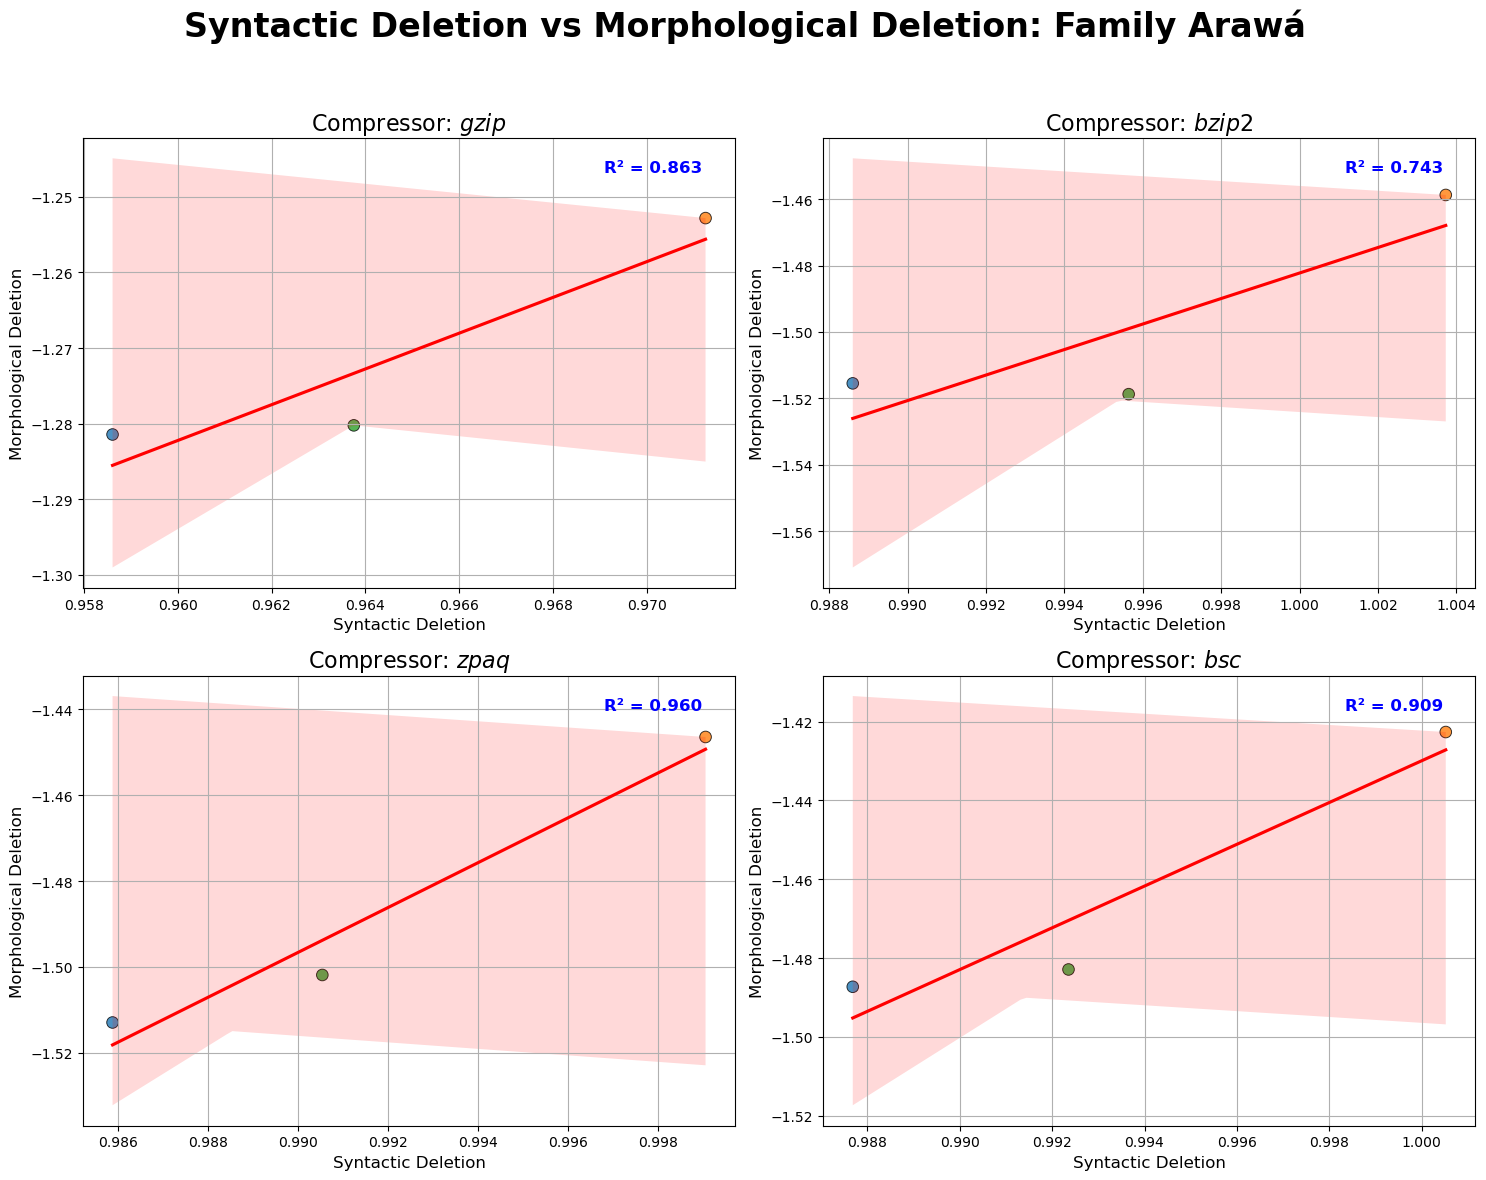

In [15]:
h3_graph_by_family(rall, 'Arawá', name='DAll Indo-European')

In [88]:
indo_european_languages = ("Ancient Greek", "English", "French", "Germany", "Portuguese", "Spanish")
rall_iel = rall[rall.language.isin(indo_european_languages)]
h3_overall(rall_iel)

,pearson_r,pearson_p,r2,coef,intercept
algorithm,,,,,
gzip,-0.975524,0.000891,0.951646,-1.902687,0.696085
bzip2,-0.928578,0.007469,0.862258,-2.309630,1.006117
zpaq,-0.976446,0.000826,0.953447,-2.948544,1.628111
bsc,-0.927438,0.007707,0.860141,-2.032584,0.752821


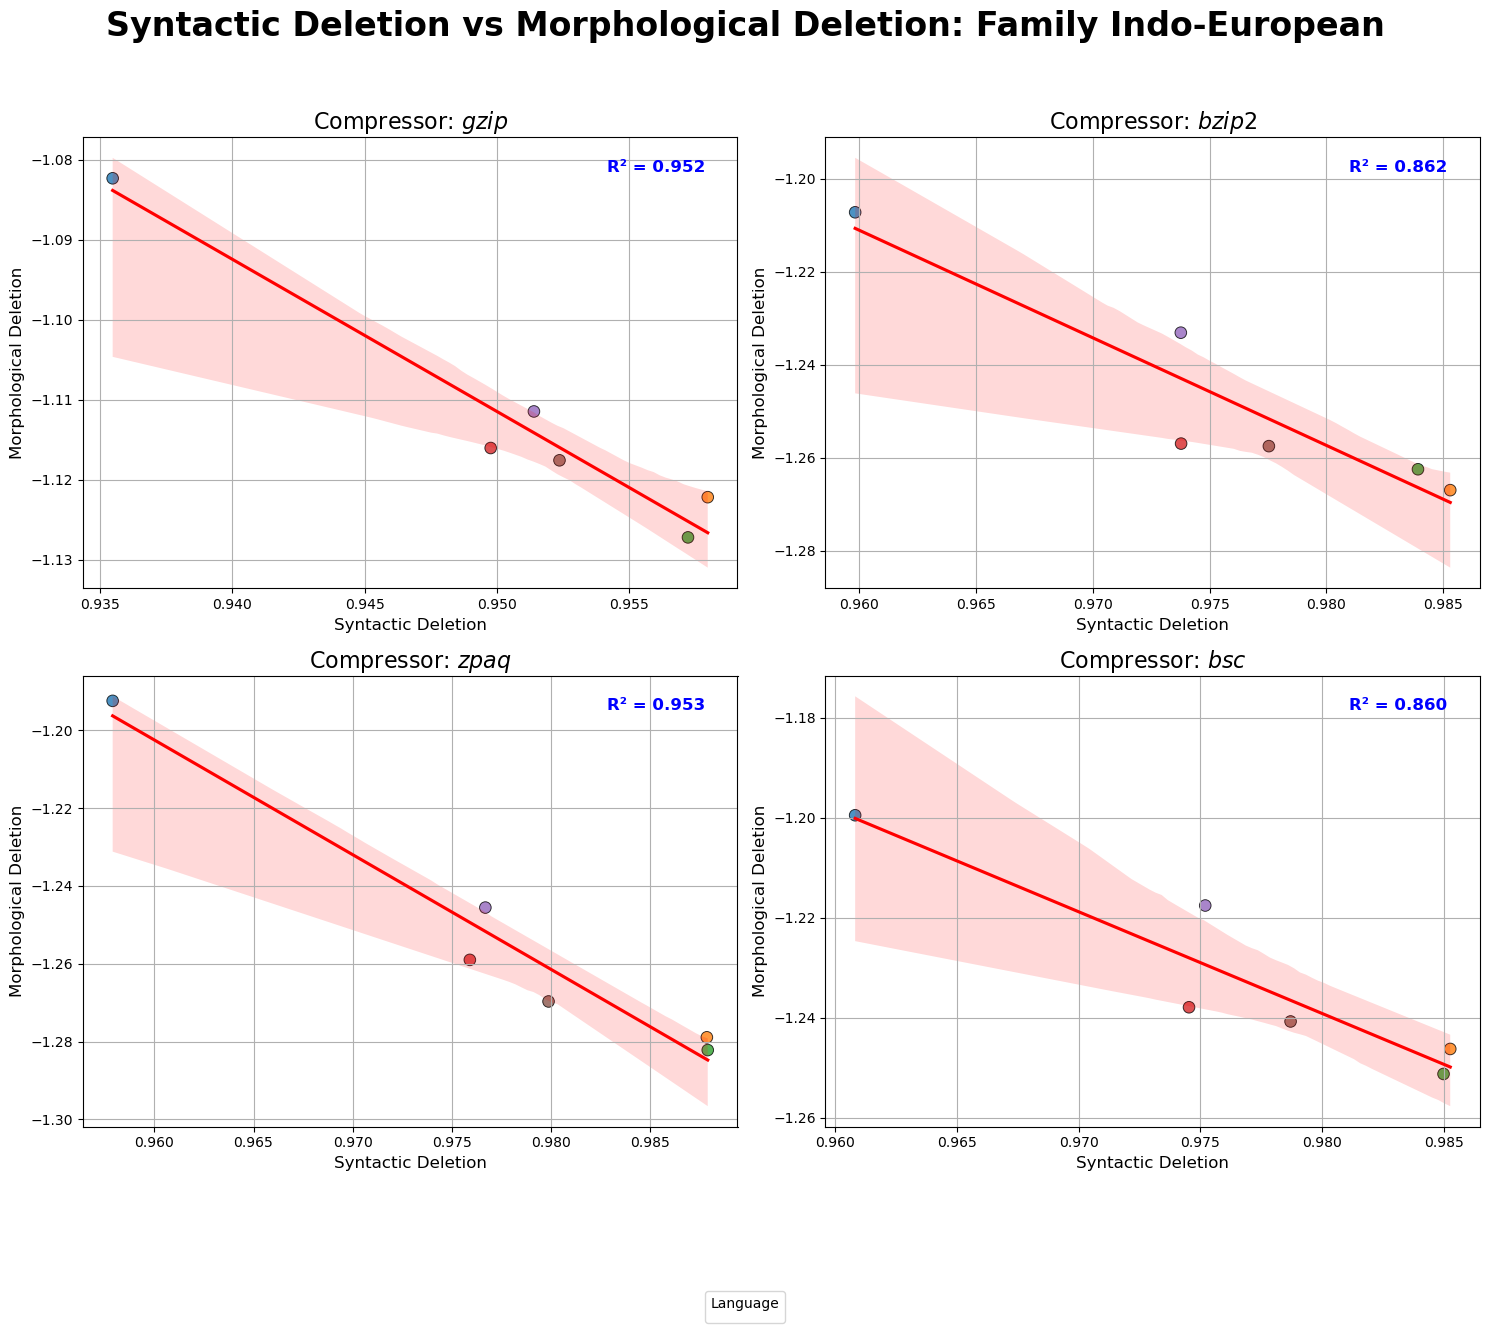

In [144]:
h3_graph_by_family(rall, 'Indo-European', name='DAll Indo-European')

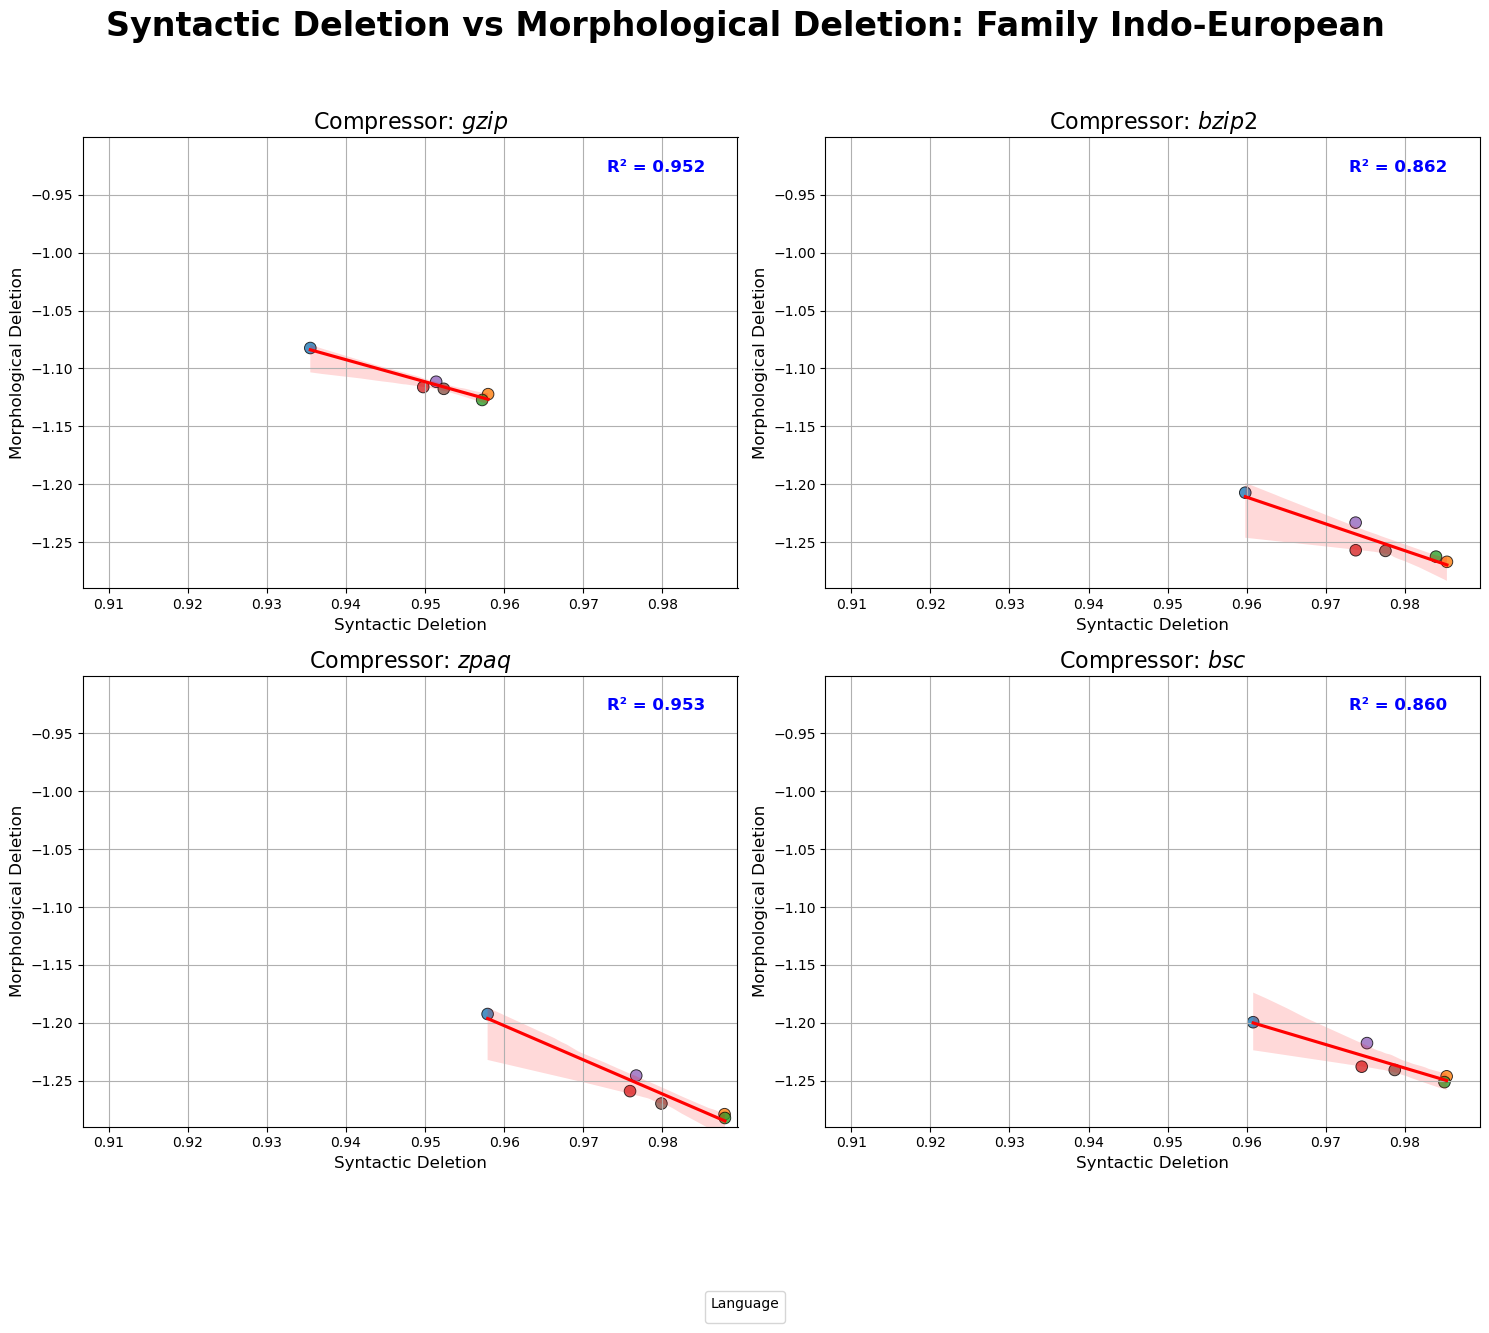

In [145]:
h3_graph_by_family(rall, 'Indo-European', name='DAll Indo-European', equal_axis=True)

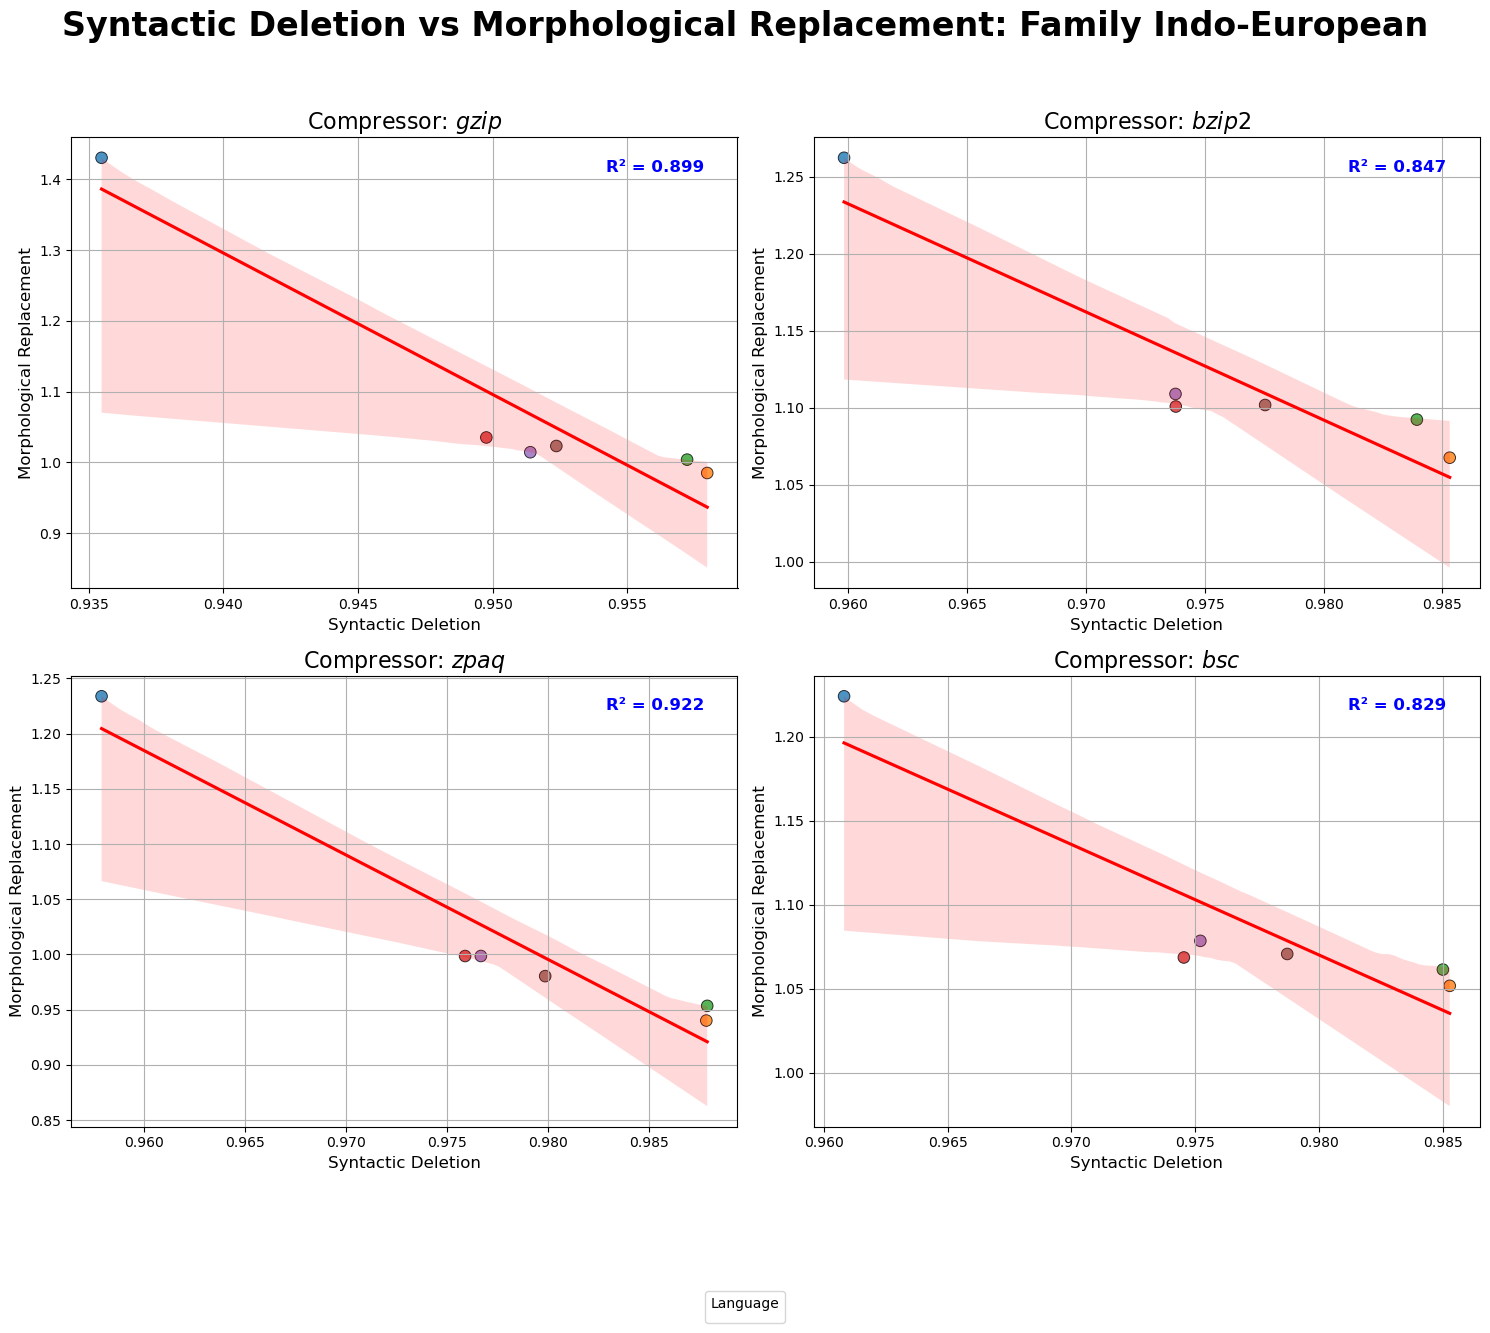

In [146]:
h3_graph_by_family(rall, 'Indo-European', name='DAll Indo-European', metric = 'replacement')

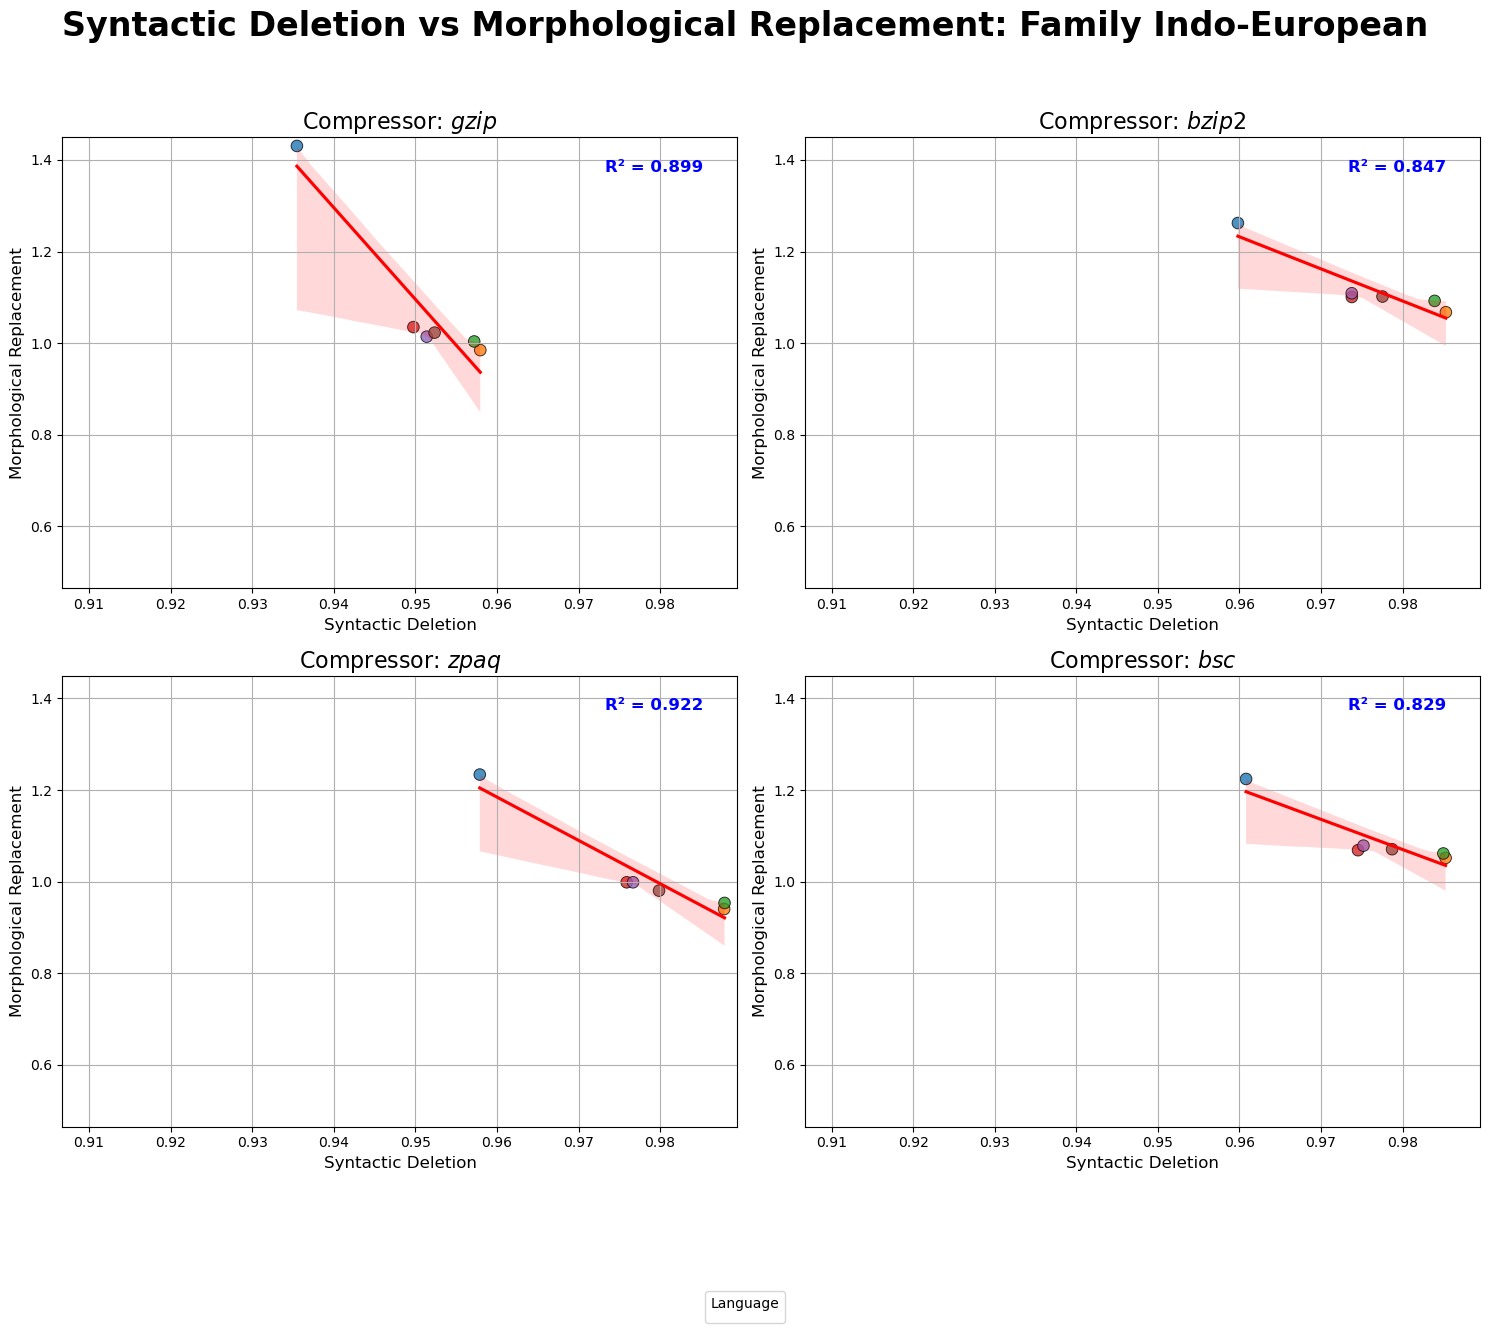

In [147]:
h3_graph_by_family(rall, 'Indo-European', name='DAll Indo-European', metric = 'replacement', equal_axis=True)

# O1 - Morphological Complexity, tokens and types

In [23]:
def o1(df, bibles):
    d = compute_numtypes_numtokens(bibles)
    metric = df.metric == 'morphological substitution'
    tdf = pd.DataFrame(d).sort_values('language')

    s = "%s) corr=%0.4f, p-value=%g"

    for alg in algorithms:
        rep = (
            df[metric & (df.algorithm == alg)]
            .groupby('language', as_index=False)['value']
            .mean()
        )
        merged = pd.merge(tdf, rep, on='language', how='inner')

        print(f"\n{alg} results:")

        if len(merged) < 2:
            print(f"{alg}: dados insuficientes ({len(merged)} língua(s))")
            continue  # pula para o próximo algoritmo

        a = sp.stats.pearsonr(merged['types'], merged['value'])
        b = sp.stats.pearsonr(merged['tokens'], merged['value'])
        print(s % ("a", a.statistic, a.pvalue))
        print(s % ("b", b.statistic, b.pvalue))



##  D90

In [24]:
o1(df90, bibles_d90)


gzip results:
gzip: dados insuficientes (0 língua(s))

bzip2 results:
bzip2: dados insuficientes (0 língua(s))

zpaq results:
zpaq: dados insuficientes (0 língua(s))

bsc results:
bsc: dados insuficientes (0 língua(s))


# O2

All language are equal in a pragmatic sense

In [163]:
def o2(rdf):
    sz = rdf.metric == 'size'
    nn = rdf.algorithm == 'none'
    out = rdf.loc[~sz & ~nn].groupby(
        by=['metric', 'algorithm']).agg({'value' : 'var'}).sort_values('value')

    return out

## D90

In [164]:
o2(df90)

value
metric                 algorithm          
pragmatic deletion     gzip       0.000003
                       bsc        0.000005
                       zpaq       0.000015
                       bzip2      0.000038
syntactic deletion     gzip       0.000273
                       zpaq       0.000709
                       bsc        0.000753
                       bzip2      0.000770
morphology replacement bsc        0.002731
morphology deletion    gzip       0.002841
morphology replacement bzip2      0.004161
morphology deletion    bsc        0.006037
                       zpaq       0.006415
                       bzip2      0.006474
morphology replacement zpaq       0.009424
                       gzip       0.012101

## DALL

In [165]:
o2(dfall)

value
metric                 algorithm          
pragmatic deletion     bsc        0.000008
                       zpaq       0.000008
                       gzip       0.000008
                       bzip2      0.000013
syntactic deletion     gzip       0.000313
                       zpaq       0.000609
                       bsc        0.000689
                       bzip2      0.000746
morphology deletion    gzip       0.002532
                       zpaq       0.005161
morphology replacement bsc        0.005191
morphology deletion    bsc        0.005202
                       bzip2      0.006216
morphology replacement bzip2      0.007121
                       gzip       0.011885
                       zpaq       0.012229

# O3

Morphological complexity metric agrees with Nichol's

# O4

In [26]:
def o4(df, metric, algo, imprimir = True):
    m = df.metric == metric
    a = df.algorithm == algo

    ret = df[m & a].sort_values('value_mean')
    ret = ret.reset_index().drop(columns=['metric', 'algorithm', 'index'])
    if imprimir:
        print (f"Metric: {metric}, Algorithm: {algo}, Mean: {ret.value_mean.mean():.4f}, Variance: {ret.value_mean.var():.4f}, Median: {ret.value_mean.median():.4f}")
    return ret

In [47]:
def spearman_footrule(df1, df2):
    common = set(df1["language"]) & set(df2["language"])
    df1 = df1[df1["language"].isin(common)].reset_index(drop=True)
    df2 = df2[df2["language"].isin(common)].reset_index(drop=True)

    rank1 = df1.set_index("language").rank(method="first")["value_mean"]
    rank2 = df2.set_index("language").rank(method="first")["value_mean"]

    distance = (rank1 - rank2).abs().sum()

    distance /= len(common)

    return distance


def par_a_par(dfs, names):
    dist_df = pd.DataFrame(index=names, columns=names, dtype=float)
    for (df1, name1), (df2, name2) in combinations(zip(dfs, names), 2):
        dist = spearman_footrule(df1, df2)
        dist_df.loc[name1, name2] = dist
        dist_df.loc[name2, name1] = dist
    for name in names:
        dist_df.loc[name, name] = 0.0
    return dist_df


In [49]:
def plot_footrule_heatmaps(df, name, save = False):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, m in enumerate(metrics):
        o4s = [o4(df, m, alg, False) for alg in algorithms]
        result = par_a_par(o4s, names=algorithms)

        sns.heatmap(result, annot=True, fmt='.0f', cmap="Reds",
                    cbar=(i == len(metrics)-1), ax=axes[i])
        axes[i].set_title(m, fontsize=14)

    for j in range(len(metrics), 4):
        axes[j].axis("off")

    plt.suptitle(f"Spearman Footrule Distance for {name}", fontsize=16, y=1.02)
    plt.tight_layout()
    if save:
        plt.savefig(f'sperman_distance_{name}.png', dpi=300)

    plt.show()

## D90

## Gráfico

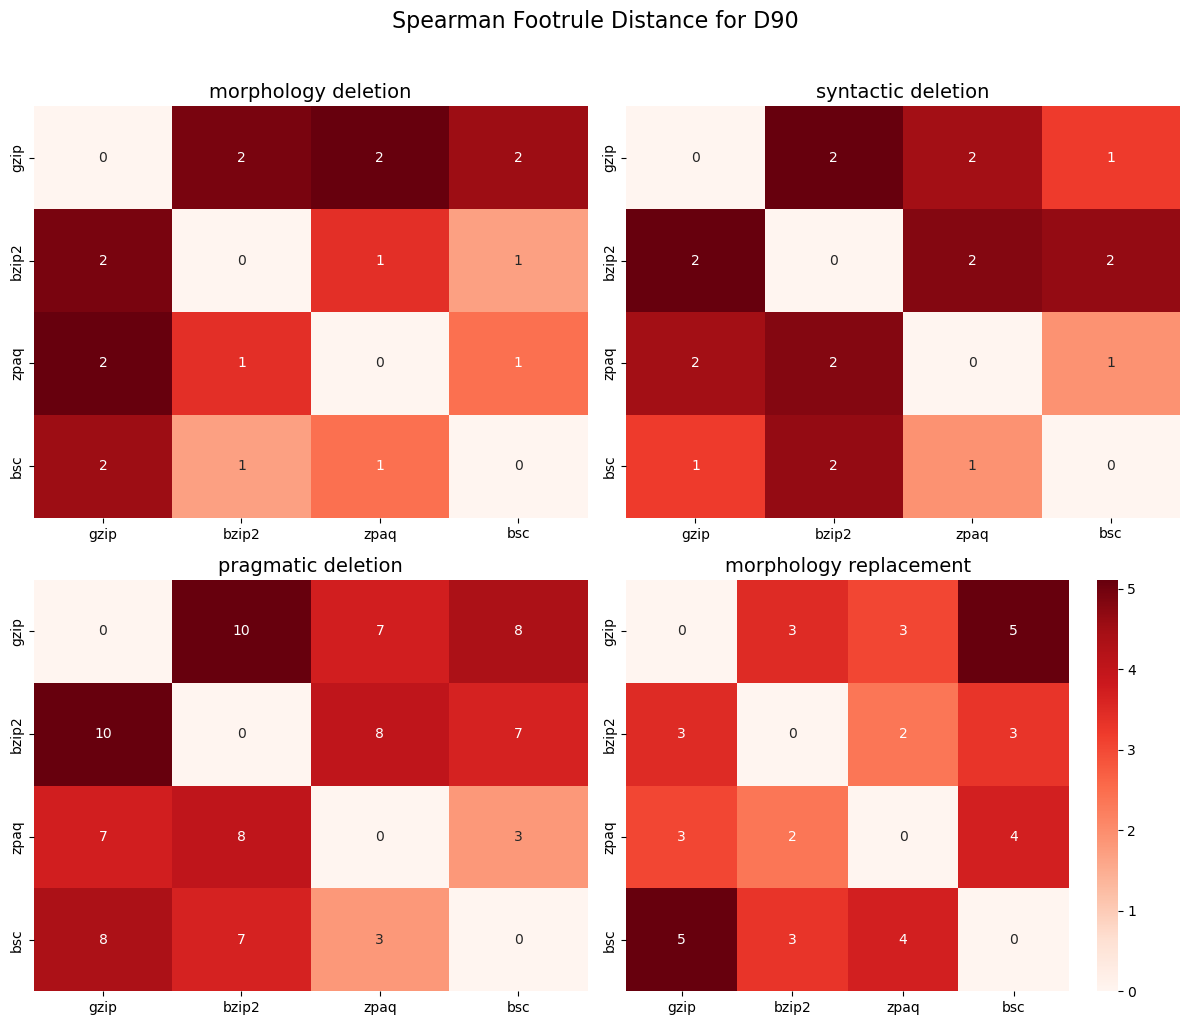

In [50]:
plot_footrule_heatmaps(r90, "D90", True)

### Morphological Deletion

In [51]:
o4s = []
for alg in algorithms:
    o4s.append(o4(r90, 'morphology deletion', alg))
par_a_par(o4s, names=algorithms)

Metric: morphology deletion, Algorithm: gzip, Mean: -1.2083, Variance: 0.0029, Median: -1.2260
Metric: morphology deletion, Algorithm: bzip2, Mean: -1.4255, Variance: 0.0067, Median: -1.4538
Metric: morphology deletion, Algorithm: zpaq, Mean: -1.4332, Variance: 0.0066, Median: -1.4621
Metric: morphology deletion, Algorithm: bsc, Mean: -1.4129, Variance: 0.0062, Median: -1.4392


,gzip,bzip2,zpaq,bsc
gzip,0.000000,1.925926,2.000000,1.777778
bzip2,1.925926,0.000000,1.333333,0.666667
zpaq,2.000000,1.333333,0.000000,0.962963
bsc,1.777778,0.666667,0.962963,0.000000


In [52]:
o4(r90, 'morphology deletion', 'bzip2')

Metric: morphology deletion, Algorithm: bzip2, Mean: -1.4255, Variance: 0.0067, Median: -1.4538


,language,family,code,value_mean,value_var
0,Matsés,Pano,myr,-1.583703,1.703038e-07
1,Palikúr,Aruak,plk,-1.525292,4.955564e-07
2,Jamamadi,Arawá,jmm,-1.515797,9.607632e-07
3,Macushi,Karib,mac,-1.507976,8.935953e-07
4,Yanomami,Yanomami,[guu],-1.494434,1.577719e-06
5,Guarani Western Bolivia,Tupi-Guarani,[gnw],-1.474388,1.865763e-07
6,Guarani Eastern Bolivia,Tupi-Guarani,crg,-1.473847,4.984263e-07
7,Wapishana,Aruak,wps,-1.471731,6.922489e-07
8,Parecís,Aruak,pex,-1.470263,9.942364e-07
9,Apalaí,Karib,apl,-1.466265,7.584018e-07


In [34]:
o4(r90, 'morphology deletion', 'zpaq')

Metric: morphology deletion, Algorithm: zpaq, Mean: -1.4332, Variance: 0.0066, Median: -1.4621


,language,family,code,value_mean,value_var
0,Matsés,Pano,myr,-1.572302,4.692409e-07
1,Palikúr,Aruak,plk,-1.562432,2.840172e-07
2,Jamamadi,Arawá,jmm,-1.518899,1.453582e-07
3,Guarani Eastern Bolivia,Tupi-Guarani,crg,-1.513126,4.688220e-07
4,Guarani Western Bolivia,Tupi-Guarani,[gnw],-1.501087,1.125539e-06
5,Macushi,Karib,mac,-1.486748,2.500509e-07
6,Yanomami,Yanomami,[guu],-1.481132,3.738561e-07
7,Parecís,Aruak,pex,-1.476776,2.243344e-07
8,Apurinã,Aruak,apu,-1.474297,1.787370e-07
9,Terêna,Aruak,trn,-1.470579,3.565370e-07


In [35]:
o4(r90, 'morphology deletion', 'bsc')

Metric: morphology deletion, Algorithm: bsc, Mean: -1.4129, Variance: 0.0062, Median: -1.4392


,language,family,code,value_mean,value_var
0,Matsés,Pano,myr,-1.559910,4.024805e-07
1,Palikúr,Aruak,plk,-1.513879,7.315842e-07
2,Jamamadi,Arawá,jmm,-1.496173,3.847858e-07
3,Macushi,Karib,mac,-1.486955,1.976448e-07
4,Yanomami,Yanomami,[guu],-1.485314,3.812654e-07
5,Guarani Eastern Bolivia,Tupi-Guarani,crg,-1.469854,3.914732e-07
6,Guarani Western Bolivia,Tupi-Guarani,[gnw],-1.469233,3.375884e-07
7,Apurinã,Aruak,apu,-1.452461,1.521062e-07
8,Parecís,Aruak,pex,-1.450382,3.473849e-07
9,Apalaí,Karib,apl,-1.449732,2.915210e-07


### Morphological Replacement

In [53]:
o4s = []
for alg in algorithms:
    o4s.append(o4(r90, 'morphology replacement', alg))
par_a_par(o4s, names=algorithms)

Metric: morphology replacement, Algorithm: gzip, Mean: 0.9945, Variance: 0.0125, Median: 0.9720
Metric: morphology replacement, Algorithm: bzip2, Mean: 0.9970, Variance: 0.0043, Median: 1.0008
Metric: morphology replacement, Algorithm: zpaq, Mean: 0.8663, Variance: 0.0097, Median: 0.8549
Metric: morphology replacement, Algorithm: bsc, Mean: 0.9711, Variance: 0.0028, Median: 0.9630


,gzip,bzip2,zpaq,bsc
gzip,0.000000,3.481481,3.037037,5.111111
bzip2,3.481481,0.000000,2.370370,3.333333
zpaq,3.037037,2.370370,0.000000,3.703704
bsc,5.111111,3.333333,3.703704,0.000000


In [36]:
o4(r90, 'morphology replacement', 'gzip')

Metric: morphology replacement, Algorithm: gzip, Mean: 0.9945, Variance: 0.0125, Median: 0.9720


,language,family,code,value_mean,value_var
0,Kaigang,Jê,kng,0.836828,6.681595e-07
1,Nadeb,Makú,nad,0.866309,1.614556e-07
2,Maxakali,Maxakali,max,0.885128,2.552804e-07
3,Yanomami,Yanomami,[guu],0.893759,5.470563e-07
4,Guarani Mbya,Tupi-Guarani,[gun],0.931604,1.707412e-06
5,Jamamadi,Arawá,jmm,0.934346,6.753869e-07
6,Sateré-Mawé,Mawé,[mav],0.934984,1.291268e-06
7,Guarani Eastern Bolivia,Tupi-Guarani,crg,0.936076,4.838191e-07
8,English,Indo-European,eng,0.936344,6.501578e-07
9,French,Indo-European,fre,0.948403,5.694080e-07


In [37]:
o4(r90, 'morphology replacement', 'bzip2')

Metric: morphology replacement, Algorithm: bzip2, Mean: 0.9970, Variance: 0.0043, Median: 1.0008


,language,family,code,value_mean,value_var
0,Yanomami,Yanomami,[guu],0.893486,2.164248e-06
1,Nadeb,Makú,nad,0.898173,6.323183e-06
2,Kaigang,Jê,kng,0.910526,2.280056e-06
3,Maxakali,Maxakali,max,0.923565,4.489698e-06
4,Matsés,Pano,myr,0.949341,1.167385e-06
5,Jamamadi,Arawá,jmm,0.950186,6.046151e-07
6,Sateré-Mawé,Mawé,[mav],0.960579,1.821640e-06
7,Macushi,Karib,mac,0.968636,2.858671e-07
8,Guarani Mbya,Tupi-Guarani,[gun],0.977014,1.361080e-06
9,Apalaí,Karib,apl,0.983295,1.871529e-06


In [38]:
o4(r90, 'morphology replacement', 'zpaq')

Metric: morphology replacement, Algorithm: zpaq, Mean: 0.8663, Variance: 0.0097, Median: 0.8549


,language,family,code,value_mean,value_var
0,Kaigang,Jê,kng,0.677261,1.846978e-05
1,Nadeb,Makú,nad,0.703507,3.594020e-06
2,Yanomami,Yanomami,[guu],0.746412,6.648990e-06
3,Maxakali,Maxakali,max,0.758884,4.212786e-06
4,Guarani Eastern Bolivia,Tupi-Guarani,crg,0.804989,7.127337e-06
5,Jamamadi,Arawá,jmm,0.811475,1.072969e-05
6,Guarani Western Bolivia,Tupi-Guarani,[gnw],0.813669,1.652508e-05
7,Sateré-Mawé,Mawé,[mav],0.816648,4.908799e-06
8,Palikúr,Aruak,plk,0.818760,2.563556e-06
9,Apalaí,Karib,apl,0.827677,6.846179e-06


In [39]:
o4(r90, 'morphology replacement', 'bsc')

Metric: morphology replacement, Algorithm: bsc, Mean: 0.9711, Variance: 0.0028, Median: 0.9630


,language,family,code,value_mean,value_var
0,Maxakali,Maxakali,max,0.901708,4.055540e-07
1,Yanomami,Yanomami,[guu],0.903815,5.722161e-07
2,Jamamadi,Arawá,jmm,0.909491,4.270494e-07
3,Matsés,Pano,myr,0.910249,1.585206e-07
4,Nadeb,Makú,nad,0.915505,8.442264e-07
5,Kaigang,Jê,kng,0.924220,6.413909e-07
6,Macushi,Karib,mac,0.938455,1.758546e-07
7,Apalaí,Karib,apl,0.942009,2.599229e-07
8,Sateré-Mawé,Mawé,[mav],0.947092,2.358121e-07
9,Guarani Eastern Bolivia,Tupi-Guarani,crg,0.957297,2.640831e-07


### Pragmatic Deletion

In [54]:
o4s = []
for alg in algorithms:
    o4s.append(o4(r90, 'pragmatic deletion', alg))
par_a_par(o4s, names=algorithms)

Metric: pragmatic deletion, Algorithm: gzip, Mean: 0.9070, Variance: 0.0000, Median: 0.9068
Metric: pragmatic deletion, Algorithm: bzip2, Mean: 0.9104, Variance: 0.0000, Median: 0.9118
Metric: pragmatic deletion, Algorithm: zpaq, Mean: 0.9140, Variance: 0.0000, Median: 0.9133
Metric: pragmatic deletion, Algorithm: bsc, Mean: 0.9136, Variance: 0.0000, Median: 0.9140


,gzip,bzip2,zpaq,bsc
gzip,0.000000,9.777778,7.111111,8.296296
bzip2,9.777778,0.000000,7.703704,6.962963
zpaq,7.111111,7.703704,0.000000,3.481481
bsc,8.296296,6.962963,3.481481,0.000000


In [64]:
o4(r90, 'pragmatic deletion', 'gzip')

Metric: pragmatic deletion, Algorithm: gzip, Mean: 0.9070, Variance: 0.0000, Median: 0.9068


,language,family,code,value_mean,value_var
0,Yanomami,Yanomami,[guu],0.905043,3.863905e-06
1,Apalaí,Karib,apl,0.905736,3.863748e-06
2,Sateré-Mawé,Mawé,[mav],0.905862,3.470038e-06
3,Terêna,Aruak,trn,0.906041,2.124616e-06
4,Kaigang,Jê,kng,0.906135,3.256517e-06
5,Spanish,Indo-European,spa,0.906144,1.601325e-06
6,Germany,Indo-European,ger,0.906267,2.114006e-06
7,Nadeb,Makú,nad,0.906386,1.871532e-06
8,Ancient Greek,Indo-European,[grc],0.906403,1.236528e-06
9,Guarani Paraguay,Tupi-Guarani,gua,0.906480,2.354834e-06


In [41]:
o4(r90, 'pragmatic deletion', 'bzip2')

Metric: pragmatic deletion, Algorithm: bzip2, Mean: 0.9104, Variance: 0.0000, Median: 0.9118


,language,family,code,value_mean,value_var
0,Guarani Mbya,Tupi-Guarani,[gun],0.897530,2.236813e-06
1,Sateré-Mawé,Mawé,[mav],0.899681,6.102851e-06
2,Spanish,Indo-European,spa,0.900912,3.141523e-06
3,Asheninka,Aruak,cax,0.901715,1.436771e-05
4,Nheengatu,Tupi-Guarani,[yrl],0.905310,1.646022e-05
5,French,Indo-European,fre,0.906102,4.123569e-06
6,Germany,Indo-European,ger,0.906514,2.226424e-06
7,Guarani Paraguay,Tupi-Guarani,gua,0.906524,2.509256e-06
8,Apurinã,Aruak,apu,0.907856,1.057162e-05
9,Guarani Western Bolivia,Tupi-Guarani,[gnw],0.907933,8.365759e-06


In [42]:
o4(r90, 'pragmatic deletion', 'zpaq')

Metric: pragmatic deletion, Algorithm: zpaq, Mean: 0.9140, Variance: 0.0000, Median: 0.9133


,language,family,code,value_mean,value_var
0,Sateré-Mawé,Mawé,[mav],0.908606,4.330633e-06
1,Macushi,Karib,mac,0.910437,2.230001e-06
2,Kaigang,Jê,kng,0.910893,1.155251e-06
3,Nheengatu,Tupi-Guarani,[yrl],0.911344,2.312483e-06
4,Apalaí,Karib,apl,0.911661,2.657787e-06
5,Wapishana,Aruak,wps,0.911719,1.395959e-06
6,Apurinã,Aruak,apu,0.912060,9.847734e-07
7,Maxakali,Maxakali,max,0.912179,3.024412e-06
8,Parecís,Aruak,pex,0.912258,2.191088e-06
9,Ancient Greek,Indo-European,[grc],0.912641,1.072201e-06


In [43]:
o4(r90, 'pragmatic deletion', 'bsc')

Metric: pragmatic deletion, Algorithm: bsc, Mean: 0.9136, Variance: 0.0000, Median: 0.9140


,language,family,code,value_mean,value_var
0,Sateré-Mawé,Mawé,[mav],0.907676,2.549485e-06
1,Maxakali,Maxakali,max,0.911414,3.275895e-06
2,Wapishana,Aruak,wps,0.911799,2.130616e-06
3,Nheengatu,Tupi-Guarani,[yrl],0.911934,9.966875e-07
4,Macushi,Karib,mac,0.912030,2.385636e-06
5,Apurinã,Aruak,apu,0.912304,1.761874e-06
6,Asheninka,Aruak,cax,0.912305,2.312521e-06
7,Apalaí,Karib,apl,0.912409,1.914945e-06
8,Parecís,Aruak,pex,0.912571,3.205210e-06
9,Kaigang,Jê,kng,0.912829,3.004423e-06


### Syntactic Deletion

In [55]:
o4s = []
for alg in algorithms:
    o4s.append(o4(r90, 'syntactic deletion', alg))
par_a_par(o4s, names=algorithms)

Metric: syntactic deletion, Algorithm: gzip, Mean: 0.9620, Variance: 0.0003, Median: 0.9591
Metric: syntactic deletion, Algorithm: bzip2, Mean: 0.9993, Variance: 0.0008, Median: 0.9939
Metric: syntactic deletion, Algorithm: zpaq, Mean: 1.0051, Variance: 0.0007, Median: 0.9998
Metric: syntactic deletion, Algorithm: bsc, Mean: 1.0050, Variance: 0.0008, Median: 1.0012


,gzip,bzip2,zpaq,bsc
gzip,0.000000,2.370370,2.074074,1.481481
bzip2,2.370370,0.000000,2.222222,2.148148
zpaq,2.074074,2.222222,0.000000,0.888889
bsc,1.481481,2.148148,0.888889,0.000000


In [44]:
o4(r90, 'syntactic deletion', 'gzip')

Metric: syntactic deletion, Algorithm: gzip, Mean: 0.9620, Variance: 0.0003, Median: 0.9591


,language,family,code,value_mean,value_var
0,Asheninka,Aruak,cax,0.933847,5.609609e-07
1,Ancient Greek,Indo-European,[grc],0.937469,5.219984e-07
2,Guarani Paraguay,Tupi-Guarani,gua,0.947749,4.054665e-07
3,Terêna,Aruak,trn,0.947782,4.103086e-07
4,Tuyúca,Tukano,tuy,0.948199,2.537987e-07
5,Wapishana,Aruak,wps,0.950338,1.808246e-07
6,Germany,Indo-European,ger,0.950399,2.089965e-07
7,Parecís,Aruak,pex,0.950408,7.571878e-07
8,Apurinã,Aruak,apu,0.950564,5.528614e-07
9,Portuguese,Indo-European,por,0.953455,5.346059e-07


In [45]:
o4(r90, 'syntactic deletion', 'bzip2')

Metric: syntactic deletion, Algorithm: bzip2, Mean: 0.9993, Variance: 0.0008, Median: 0.9939


,language,family,code,value_mean,value_var
0,Asheninka,Aruak,cax,0.947146,5.690224e-06
1,Guarani Paraguay,Tupi-Guarani,gua,0.972038,4.340507e-06
2,Apurinã,Aruak,apu,0.973645,1.468377e-06
3,Ancient Greek,Indo-European,[grc],0.974151,1.295573e-06
4,Spanish,Indo-European,spa,0.978408,3.152593e-07
5,Germany,Indo-European,ger,0.979864,5.144788e-07
6,Parecís,Aruak,pex,0.980039,1.529857e-06
7,Nheengatu,Tupi-Guarani,[yrl],0.983782,3.919432e-06
8,Wapishana,Aruak,wps,0.985313,5.804333e-07
9,Tuyúca,Tukano,tuy,0.985567,2.257784e-07


In [46]:
o4(r90, 'syntactic deletion', 'zpaq')

Metric: syntactic deletion, Algorithm: zpaq, Mean: 1.0051, Variance: 0.0007, Median: 0.9998


,language,family,code,value_mean,value_var
0,Ancient Greek,Indo-European,[grc],0.966736,5.454893e-07
1,Asheninka,Aruak,cax,0.967555,4.021436e-07
2,Apurinã,Aruak,apu,0.981169,3.536474e-07
3,Wapishana,Aruak,wps,0.981788,2.696300e-07
4,Parecís,Aruak,pex,0.982170,1.995995e-07
5,Guarani Paraguay,Tupi-Guarani,gua,0.985364,5.447824e-07
6,Portuguese,Indo-European,por,0.987245,2.068852e-07
7,Germany,Indo-European,ger,0.987261,3.468042e-07
8,Nheengatu,Tupi-Guarani,[yrl],0.988542,6.961037e-07
9,Spanish,Indo-European,spa,0.989566,4.281183e-07


In [47]:
o4(r90, 'syntactic deletion', 'bsc')

Metric: syntactic deletion, Algorithm: bsc, Mean: 1.0050, Variance: 0.0008, Median: 1.0012


,language,family,code,value_mean,value_var
0,Asheninka,Aruak,cax,0.957626,2.606379e-07
1,Ancient Greek,Indo-European,[grc],0.971585,2.504872e-07
2,Apurinã,Aruak,apu,0.980517,3.654439e-07
3,Parecís,Aruak,pex,0.981741,3.040930e-07
4,Guarani Paraguay,Tupi-Guarani,gua,0.984197,2.934247e-07
5,Wapishana,Aruak,wps,0.985418,4.996644e-07
6,Portuguese,Indo-European,por,0.985608,2.043621e-07
7,Germany,Indo-European,ger,0.987542,4.661172e-07
8,Terêna,Aruak,trn,0.989833,2.623969e-07
9,Tuyúca,Tukano,tuy,0.990783,2.676841e-07


## DAll

### Gráfico

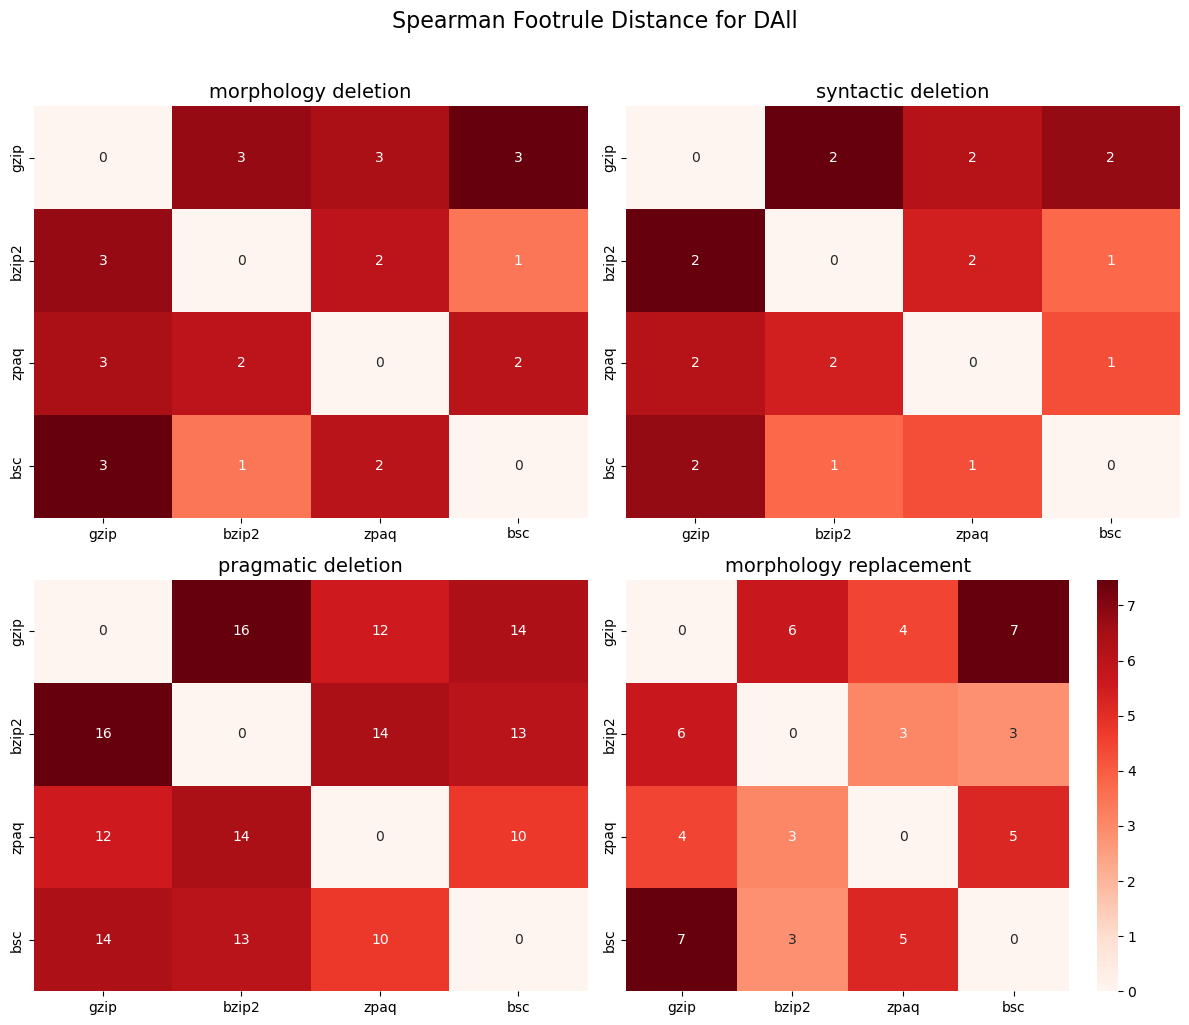

In [56]:
plot_footrule_heatmaps(rall, "DAll", True)

### Morphology Deletion

In [14]:
o4s = []
for alg in algorithms:
    o4s.append(o4(rall, 'morphology deletion', alg))
par_a_par(o4s, names=algorithms)

Metric: morphology deletion, Algorithm: gzip, Mean: -1.2192, Variance: 0.0026, Median: -1.2257
Metric: morphology deletion, Algorithm: bzip2, Mean: -1.4117, Variance: 0.0063, Median: -1.4209
Metric: morphology deletion, Algorithm: zpaq, Mean: -1.4037, Variance: 0.0052, Median: -1.4152
Metric: morphology deletion, Algorithm: bsc, Mean: -1.3840, Variance: 0.0053, Median: -1.3947


,gzip,bzip2,zpaq,bsc
gzip,0.0,152.0,144.0,168.0
bzip2,152.0,0.0,134.0,78.0
zpaq,144.0,134.0,0.0,136.0
bsc,168.0,78.0,136.0,0.0


In [48]:
o4(rall, 'morphology deletion', 'gzip')

Metric: morphology deletion, Algorithm: gzip, Mean: -1.2192, Variance: 0.0026, Median: -1.2257


,language,family,code,value_mean,value_var
0,Hixkaryána,Karib,hix,-1.322968,1.512359e-06
1,Xavante,Jê,xav,-1.293797,1.674165e-06
2,Boróro,Boróro,brr,-1.288699,1.001517e-06
3,Matsés,Pano,myr,-1.285955,6.236268e-07
4,Culina,Arawá,cul,-1.281430,1.068800e-06
5,Paumarí,Arawá,pau,-1.280219,6.623468e-07
6,Kaapor,Tupi-Guarani,urk,-1.279336,1.204341e-06
7,Kadiwéu,Guaikurú,kdw,-1.270749,2.246271e-06
8,Piratapúya,Tukano,prt,-1.266048,1.889587e-06
9,Ticuna,Ticuna,tic,-1.256911,9.367683e-07


In [49]:
o4(rall, 'morphology deletion', 'bzip2')

Metric: morphology deletion, Algorithm: bzip2, Mean: -1.4117, Variance: 0.0063, Median: -1.4209


,language,family,code,value_mean,value_var
0,Hixkaryána,Karib,hix,-1.592304,1.036406e-06
1,Matsés,Pano,myr,-1.531246,3.451221e-06
2,Xavante,Jê,xav,-1.522555,1.076358e-06
3,Paumarí,Arawá,pau,-1.518708,1.697655e-06
4,Culina,Arawá,cul,-1.515457,6.303288e-07
5,Boróro,Boróro,brr,-1.514487,4.615231e-07
6,Kadiwéu,Guaikurú,kdw,-1.497453,2.331981e-06
7,Kaapor,Tupi-Guarani,urk,-1.493131,1.257793e-05
8,Ticuna,Ticuna,tic,-1.481567,3.074520e-06
9,Piratapúya,Tukano,prt,-1.479881,1.856954e-06


In [50]:
o4(rall, 'morphology deletion', 'zpaq')

Metric: morphology deletion, Algorithm: zpaq, Mean: -1.4037, Variance: 0.0052, Median: -1.4152


,language,family,code,value_mean,value_var
0,Hixkaryána,Karib,hix,-1.576598,2.825305e-07
1,Culina,Arawá,cul,-1.512972,6.330646e-07
2,Matsés,Pano,myr,-1.510348,5.379982e-07
3,Boróro,Boróro,brr,-1.505044,6.451279e-07
4,Paumarí,Arawá,pau,-1.501897,3.821575e-07
5,Xavante,Jê,xav,-1.485844,7.172549e-07
6,Kadiwéu,Guaikurú,kdw,-1.472117,1.278201e-06
7,Kaapor,Tupi-Guarani,urk,-1.467736,6.595211e-07
8,Palikúr,Aruak,plk,-1.460397,1.401981e-06
9,Rikbaktsa,Rikbaktsa,rik,-1.459830,5.245334e-07


In [51]:
o4(rall, 'morphology deletion', 'bsc')

Metric: morphology deletion, Algorithm: bsc, Mean: -1.3840, Variance: 0.0053, Median: -1.3947


,language,family,code,value_mean,value_var
0,Hixkaryána,Karib,hix,-1.545871,9.594907e-07
1,Matsés,Pano,myr,-1.492647,1.136508e-06
2,Culina,Arawá,cul,-1.487279,1.116198e-06
3,Paumarí,Arawá,pau,-1.482890,1.593689e-06
4,Xavante,Jê,xav,-1.481037,3.252652e-07
5,Boróro,Boróro,brr,-1.475497,9.020426e-07
6,Kadiwéu,Guaikurú,kdw,-1.464996,1.029687e-06
7,Kaapor,Tupi-Guarani,urk,-1.460883,2.781996e-07
8,Macushi,Karib,mac,-1.443757,4.278556e-07
9,Ticuna,Ticuna,tic,-1.442734,1.927018e-06


### Morphology Replacement

In [16]:
o4s = []
for alg in algorithms:
    o4s.append(o4(rall, 'morphology replacement', alg))
par_a_par(o4s, names=algorithms)

Metric: morphology replacement, Algorithm: gzip, Mean: 1.0127, Variance: 0.0121, Median: 1.0065
Metric: morphology replacement, Algorithm: bzip2, Mean: 1.0279, Variance: 0.0072, Median: 1.0286
Metric: morphology replacement, Algorithm: zpaq, Mean: 0.9086, Variance: 0.0124, Median: 0.9109
Metric: morphology replacement, Algorithm: bsc, Mean: 0.9972, Variance: 0.0053, Median: 0.9893


,gzip,bzip2,zpaq,bsc
gzip,0.0,316.0,250.0,418.0
bzip2,316.0,0.0,170.0,160.0
zpaq,250.0,170.0,0.0,292.0
bsc,418.0,160.0,292.0,0.0


In [52]:
o4(rall, 'morphology replacement', 'gzip')

Metric: morphology replacement, Algorithm: gzip, Mean: 1.0127, Variance: 0.0121, Median: 1.0065


,language,family,code,value_mean,value_var
0,Kaigang,Jê,kng,0.850862,4.263525e-07
1,Sanumá,Yanomami,snm,0.855822,4.203769e-07
2,Kaapor,Tupi-Guarani,urk,0.857640,7.262589e-07
3,Canela,Jê,cnl,0.859422,8.358228e-07
4,Apinayé,Jê,api,0.872044,7.197897e-07
5,Nadeb,Makú,nad,0.880899,1.697880e-07
6,Xavante,Jê,xav,0.891508,6.966484e-07
7,Kayapó,Jê,kyp,0.895153,2.207493e-07
8,Maxakali,Maxakali,max,0.905020,1.196694e-06
9,Guajajara,Tupi-Guarani,gjj,0.906388,3.379795e-07


In [53]:
o4(rall, 'morphology replacement', 'bzip2')

Metric: morphology replacement, Algorithm: bzip2, Mean: 1.0279, Variance: 0.0072, Median: 1.0286


,language,family,code,value_mean,value_var
0,Sanumá,Yanomami,snm,0.889521,1.076361e-06
1,Kaapor,Tupi-Guarani,urk,0.900252,9.792129e-07
2,Canela,Jê,cnl,0.912500,1.264323e-06
3,Apinayé,Jê,api,0.912913,3.400314e-06
4,Kayapó,Jê,kyp,0.915994,4.381878e-06
5,Xavante,Jê,xav,0.922517,3.837702e-06
6,Nadeb,Makú,nad,0.925576,3.361500e-06
7,Kaigang,Jê,kng,0.928460,2.240307e-06
8,Hixkaryána,Karib,hix,0.931999,6.377557e-06
9,Yanomami,Yanomami,[guu],0.942730,6.269336e-06


In [54]:
o4(rall, 'morphology replacement', 'zpaq')

Metric: morphology replacement, Algorithm: zpaq, Mean: 0.9086, Variance: 0.0124, Median: 0.9109


,language,family,code,value_mean,value_var
0,Kaigang,Jê,kng,0.719629,0.000029
1,Apinayé,Jê,api,0.726183,0.000027
2,Sanumá,Yanomami,snm,0.730038,0.000016
3,Kaapor,Tupi-Guarani,urk,0.738845,0.000018
4,Canela,Jê,cnl,0.746264,0.000009
5,Xavante,Jê,xav,0.747991,0.000027
6,Nadeb,Makú,nad,0.756485,0.000019
7,Hixkaryána,Karib,hix,0.786961,0.000008
8,Guajajara,Tupi-Guarani,gjj,0.790068,0.000009
9,Boróro,Boróro,brr,0.801125,0.000005


In [55]:
o4(rall, 'morphology replacement', 'bsc')

Metric: morphology replacement, Algorithm: bsc, Mean: 0.9972, Variance: 0.0053, Median: 0.9893


,language,family,code,value_mean,value_var
0,Kaapor,Tupi-Guarani,urk,0.903406,4.484570e-07
1,Sanumá,Yanomami,snm,0.903851,8.503534e-07
2,Maxakali,Maxakali,max,0.914232,9.233948e-07
3,Makuna,Tukano,mcn,0.916313,1.665464e-07
4,Wanana,Tukano,gno,0.916700,1.490624e-07
5,Kayapó,Jê,kyp,0.917726,5.575793e-07
6,Boróro,Boróro,brr,0.919565,8.306723e-07
7,Canela,Jê,cnl,0.921803,7.087973e-07
8,Piratapúya,Tukano,prt,0.922002,3.209494e-07
9,Hixkaryána,Karib,hix,0.926266,4.857990e-07


### Syntactic Deletion

In [17]:
o4s = []
for alg in algorithms:
    o4s.append(o4(rall, 'syntactic deletion', alg))
par_a_par(o4s, names=algorithms)

Metric: syntactic deletion, Algorithm: gzip, Mean: 0.9657, Variance: 0.0003, Median: 0.9609
Metric: syntactic deletion, Algorithm: bzip2, Mean: 0.9981, Variance: 0.0008, Median: 0.9922
Metric: syntactic deletion, Algorithm: zpaq, Mean: 0.9973, Variance: 0.0006, Median: 0.9907
Metric: syntactic deletion, Algorithm: bsc, Mean: 0.9981, Variance: 0.0007, Median: 0.9919


,gzip,bzip2,zpaq,bsc
gzip,0.0,132.0,108.0,120.0
bzip2,132.0,0.0,96.0,66.0
zpaq,108.0,96.0,0.0,76.0
bsc,120.0,66.0,76.0,0.0


In [56]:
o4(rall, 'syntactic deletion', 'gzip')

Metric: syntactic deletion, Algorithm: gzip, Mean: 0.9657, Variance: 0.0003, Median: 0.9609


,language,family,code,value_mean,value_var
0,Asheninka,Aruak,cax,0.934340,1.633540e-06
1,Ancient Greek,Indo-European,[grc],0.935482,9.771402e-07
2,Karajá,Karajá,jva,0.937772,5.319211e-07
3,Tuyúca,Tukano,tuy,0.946087,1.710461e-06
4,Guarani Paraguay,Tupi-Guarani,gua,0.946382,1.046268e-06
5,Terêna,Aruak,trn,0.946566,1.621950e-06
6,Bakairí,Karib,bki,0.948445,6.486819e-07
7,Apurinã,Aruak,apu,0.949091,1.034629e-06
8,Wapishana,Aruak,wps,0.949427,4.670461e-07
9,Parecís,Aruak,pex,0.949538,1.043808e-06


In [57]:
o4(rall, 'syntactic deletion', 'bzip2')

Metric: syntactic deletion, Algorithm: bzip2, Mean: 0.9981, Variance: 0.0008, Median: 0.9922


,language,family,code,value_mean,value_var
0,Asheninka,Aruak,cax,0.952394,3.195673e-06
1,Karajá,Karajá,jva,0.955174,3.908682e-06
2,Ancient Greek,Indo-European,[grc],0.959814,2.076350e-06
3,Guarani Paraguay,Tupi-Guarani,gua,0.966281,4.135171e-06
4,Tuyúca,Tukano,tuy,0.967077,8.638330e-07
5,Kashinawa,Pano,csh,0.967150,3.021316e-06
6,Apurinã,Aruak,apu,0.972121,1.537994e-06
7,Parecís,Aruak,pex,0.973205,2.143365e-06
8,Portuguese,Indo-European,por,0.973767,8.897176e-07
9,Germany,Indo-European,ger,0.973779,7.589318e-07


In [58]:
o4(rall, 'syntactic deletion', 'zpaq')

Metric: syntactic deletion, Algorithm: zpaq, Mean: 0.9973, Variance: 0.0006, Median: 0.9907


,language,family,code,value_mean,value_var
0,Asheninka,Aruak,cax,0.952077,7.398208e-07
1,Karajá,Karajá,jva,0.957866,9.187609e-07
2,Ancient Greek,Indo-European,[grc],0.957898,8.000430e-07
3,Guarani Paraguay,Tupi-Guarani,gua,0.970836,3.870232e-07
4,Parecís,Aruak,pex,0.972472,5.083587e-07
5,Apurinã,Aruak,apu,0.973402,4.255472e-07
6,Tuyúca,Tukano,tuy,0.973923,1.420660e-06
7,Wapishana,Aruak,wps,0.974932,7.657056e-07
8,Kashinawa,Pano,csh,0.974962,5.376837e-07
9,Kadiwéu,Guaikurú,kdw,0.975463,6.191258e-07


In [59]:
o4(rall, 'syntactic deletion', 'bsc')

Metric: syntactic deletion, Algorithm: bsc, Mean: 0.9981, Variance: 0.0007, Median: 0.9919


,language,family,code,value_mean,value_var
0,Asheninka,Aruak,cax,0.950968,5.947423e-07
1,Karajá,Karajá,jva,0.956675,2.942727e-07
2,Ancient Greek,Indo-European,[grc],0.960816,8.396115e-07
3,Guarani Paraguay,Tupi-Guarani,gua,0.969550,1.473926e-06
4,Apurinã,Aruak,apu,0.971098,5.556499e-07
5,Parecís,Aruak,pex,0.972117,2.187387e-06
6,Germany,Indo-European,ger,0.974538,6.189804e-07
7,Tuyúca,Tukano,tuy,0.974812,6.935969e-07
8,Kashinawa,Pano,csh,0.975130,3.456910e-07
9,Portuguese,Indo-European,por,0.975204,1.464645e-06


### Pragmatic Deletion

In [18]:
o4s = []
for alg in algorithms:
    o4s.append(o4(rall, 'pragmatic deletion', alg))
par_a_par(o4s, names=algorithms)

Metric: pragmatic deletion, Algorithm: gzip, Mean: 0.9068, Variance: 0.0000, Median: 0.9068
Metric: pragmatic deletion, Algorithm: bzip2, Mean: 0.9126, Variance: 0.0000, Median: 0.9122
Metric: pragmatic deletion, Algorithm: zpaq, Mean: 0.9125, Variance: 0.0000, Median: 0.9127
Metric: pragmatic deletion, Algorithm: bsc, Mean: 0.9134, Variance: 0.0000, Median: 0.9137


,gzip,bzip2,zpaq,bsc
gzip,0.0,924.0,684.0,780.0
bzip2,924.0,0.0,788.0,746.0
zpaq,684.0,788.0,0.0,586.0
bsc,780.0,746.0,586.0,0.0


In [60]:
o4(rall, 'pragmatic deletion', 'gzip')

Metric: pragmatic deletion, Algorithm: gzip, Mean: 0.9068, Variance: 0.0000, Median: 0.9068


,language,family,code,value_mean,value_var
0,Sateré-Mawé,Mawé,[mav],0.904045,0.000027
1,Canela,Jê,cnl,0.904788,0.000010
2,Kayabí,Tupi-Guarani,kyz,0.904910,0.000005
3,Kaapor,Tupi-Guarani,urk,0.905031,0.000006
4,Kaiwá,Tupi-Guarani,kaw,0.905196,0.000016
5,Macushi,Karib,mac,0.905240,0.000008
6,Apurinã,Aruak,apu,0.905331,0.000005
7,Guajajara,Tupi-Guarani,gjj,0.905342,0.000022
8,Terêna,Aruak,trn,0.905388,0.000006
9,Bakairí,Karib,bki,0.905616,0.000007


In [61]:
o4(rall, 'pragmatic deletion', 'bzip2')

Metric: pragmatic deletion, Algorithm: bzip2, Mean: 0.9126, Variance: 0.0000, Median: 0.9122


,language,family,code,value_mean,value_var
0,Canela,Jê,cnl,0.908204,0.000011
1,Kayapó,Jê,kyp,0.909052,0.000004
2,Kashinawa,Pano,csh,0.909127,0.000013
3,Sateré-Mawé,Mawé,[mav],0.909414,0.000016
4,Siriano,Tukano,sri,0.909489,0.000006
5,Nheengatu,Tupi-Guarani,[yrl],0.909834,0.000018
6,Guarani Paraguay,Tupi-Guarani,gua,0.910238,0.000008
7,Apinayé,Jê,api,0.910378,0.000004
8,Kaiwá,Tupi-Guarani,kaw,0.910396,0.000008
9,Yamináwa,Pano,yam,0.910518,0.000004


In [62]:
o4(rall, 'pragmatic deletion', 'zpaq')

Metric: pragmatic deletion, Algorithm: zpaq, Mean: 0.9125, Variance: 0.0000, Median: 0.9127


,language,family,code,value_mean,value_var
0,Sateré-Mawé,Mawé,[mav],0.908031,0.000009
1,Apinayé,Jê,api,0.909289,0.000003
2,Karajá,Karajá,jva,0.910046,0.000004
3,Canela,Jê,cnl,0.910396,0.000007
4,Kaapor,Tupi-Guarani,urk,0.910460,0.000006
5,Kayapó,Jê,kyp,0.910587,0.000019
6,Tenharim,Tupi-Guarani,[pah],0.910902,0.000011
7,Xavante,Jê,xav,0.910930,0.000005
8,Kayabí,Tupi-Guarani,kyz,0.911033,0.000019
9,Kaiwá,Tupi-Guarani,kaw,0.911149,0.000011


In [63]:
o4(rall, 'pragmatic deletion', 'bsc')

Metric: pragmatic deletion, Algorithm: bsc, Mean: 0.9134, Variance: 0.0000, Median: 0.9137


,language,family,code,value_mean,value_var
0,Kayapó,Jê,kyp,0.910244,0.000001
1,Sateré-Mawé,Mawé,[mav],0.910560,0.000009
2,Rikbaktsa,Rikbaktsa,rik,0.911205,0.000011
3,Kaiwá,Tupi-Guarani,kaw,0.911246,0.000008
4,Kayabí,Tupi-Guarani,kyz,0.911556,0.000007
5,Guajajara,Tupi-Guarani,gjj,0.911655,0.000007
6,Wanana,Tukano,gno,0.911774,0.000010
7,Canela,Jê,cnl,0.911842,0.000007
8,Kaapor,Tupi-Guarani,urk,0.911927,0.000012
9,Yanomami,Yanomami,[guu],0.911990,0.000002
